In [27]:
# The two ECC interpretations (subplot dimension), in (rescue, fire) order to match
# the eval_returns_<interp>.npy filenames and the METHOD_COLORS / metric conventions.
import numpy as np
import json
from scripts.utils import make_agent, make_env  # env registered on import in the first cell
INTERPRETATIONS = ("rescue_minded", "fire_minded")
INNER_LOOP_LABEL = "inner-loop"
OUTER_LOOP_LABEL = "outer-loop"

SAVE_CONTESTED_DIR = "results/firefighters-mo-contested-v0"
SAVE_CONTESTED_RUNS = {
    INNER_LOOP_LABEL:    "ecc_gpi_pd__30000__govvtrva",
    OUTER_LOOP_LABEL:    "ecc_envelope__40000__d0g6brv2", # <- base 40k run
    # OUTER_LOOP_LABEL:    "ecc_envelope__20000__x7r9beyh",
    # "ecc-envelope": "ecc_envelope__40000__d0g6brv2",
    # "ecc-envelope-3net-newnew":      "ecc_envelope__40000__plebka94",
    # "ecc-envelope-3net-old": "ecc_envelope__20000__9wagsvcd",
    # "ecc-envelope-3net": "ecc_envelope__40000__ijbhv84c",
    "gpipd-fire":        "gpi_pd__5000__850yazz0",
    "gpipd-rescue":      "gpi_pd__5000__dzks0la5",
    "gpipd-weighted":    "gpi_pd__5000__ptvunkk9",
    "gpipd-4obj":        "gpi_pd__30000__fw38o6ug",
    "envelope-fire":     "envelope__20000__3gr8w2k0",
    "envelope-rescue":   "envelope__20000__8ytmfd9y",
    "envelope-weighted": "envelope__20000__9d7yhdgy",
    "envelope-4obj":     "envelope__20000__kwst1vqf",
}


# Pareto-front comparison for the FIREFIGHTERS scenario.
#
# Mirrors the reach_goal plots, but the two objectives (the axes) and the two
# interpretations (the subplots) are firefighter-specific and fully variable:
#   * objectives     -> the reward dimensions plotted on x/y  (professionalism, proximity)
#   * interpretations-> the ECC groundings, one subplot each   (rescue_minded, fire_minded)
#
# Every run is evaluated under BOTH interpretations via:
#     python -m scripts.eval --run-id <run_id> --both-interps
# which writes results\firefighters-mo-ecc-v0\eval\<run_id>\eval_returns_<interp>.npy,
# so baselines and ECC agents load through the exact same per-interpretation files.
import itertools
import os
import numpy as np
import matplotlib.pyplot as plt
from morl_baselines.common.pareto import get_non_dominated
from morl_baselines.common.performance_indicators import hypervolume, expected_utility
from morl_baselines.common.weights import equally_spaced_weights
import env

EVAL_DIR = r"results\firefighters-mo-ecc-v0\eval"  # output of `eval.py --both-interps`

# Canonical method -> color map so every figure uses the SAME color for a given
# method, regardless of which subset is plotted. Add new method labels here.
METHOD_ORDER = [
    INNER_LOOP_LABEL, OUTER_LOOP_LABEL,
    "gpipd-fire", "gpipd-rescue", "gpipd-weighted", "gpipd-4obj",
    "envelope-fire", "envelope-rescue", "envelope-weighted", "envelope-4obj",
]
METHOD_COLORS = {m: c for m, c in zip(METHOD_ORDER, plt.cm.tab10.colors)}


def pareto_front(points):
    """Return non-dominated points (both objectives maximized), sorted by obj 0."""
    nd = get_non_dominated({tuple(p) for p in np.asarray(points, dtype=float)})
    return np.array(sorted(nd, key=lambda p: p[0]))


def ecc_files(interpretations):
    """Per-interpretation file map: eval_returns_<interp>.npy (both-interps eval)."""
    return {interp: f"eval_returns_{interp}.npy" for interp in interpretations}


def eval_methods(runs, interpretations, eval_dir=EVAL_DIR):
    """Build (label, dir, file_map) entries from a {label: run_id} mapping.

    Each method points at eval_dir\\<run_id> and loads eval_returns_<interp>.npy.
    """
    return [
        (label, os.path.join(eval_dir, run_id), ecc_files(interpretations))
        for label, run_id in runs.items()
    ]


def plot_pareto_fronts(
    methods,
    interpretations,
    objective_labels=("professionalism", "proximity"),
    title="Pareto front",
    normalize="shared",
    xlim=None,
    ylim=None,
    figsize=(16, 7),
    weights_set=None,
    save_path=None,
    dpi=150,
):
    """One subplot per interpretation; HV + EUM per method.

    methods           : list of (label, dir, {interpretation: filename})
    interpretations   : the ECC groundings to plot, one subplot each
    objective_labels  : (x_label, y_label) for the two reward dimensions
    normalize         : rescale the plotted fronts to [0, 1] (see firefighters_pareto_fronts.py)
        'none'   -> raw returns.
        'shared' -> per interpretation, rescale every method by the shared across-method
                    min/max so the subplot fills [0, 1]^2. Methods stay comparable and the
                    two subplots become directly comparable in shape (recommended).
        'own'    -> rescale each method by its own min/max; isolates the shape of each
                    front but is NOT comparable across methods (every front fills [0, 1]).
    save_path         : if given, the figure is written there (bbox_inches='tight') at `dpi`.

    EUM is always reported on the shared-normalized scale so it stays comparable across
    methods; HV is reported on whatever scale is plotted.

    Methods whose plotted Pareto front coincides are drawn once and labelled together
    with an [overlap] tag, so identical fronts don't hide one another.
    """
    assert normalize in ("none", "shared", "own"), normalize
    if weights_set is None:
        weights_set = equally_spaced_weights(2, 100)  # for the Expected Utility Metric

    # Canonical colors first; fall back to the rcParams cycle for any unknown label.
    fallback = itertools.cycle(plt.rcParams["axes.prop_cycle"].by_key()["color"])
    colors = {label: METHOD_COLORS.get(label) or next(fallback)
              for label, *_ in methods}
    prefix = "normalized " if normalize != "none" else ""

    fig, axes = plt.subplots(1, len(interpretations), figsize=figsize, squeeze=False)
    for ax, interp in zip(axes[0], interpretations):
        loaded = {label: np.load(os.path.join(d, files[interp]))
                  for label, d, files in methods}
        # shared min/max per interpretation across all methods -> fair, comparable metrics
        all_pts = np.vstack(list(loaded.values()))
        lo, hi = all_pts.min(axis=0), all_pts.max(axis=0)
        span = np.where(hi > lo, hi - lo, 1.0)
        ref_point = lo - 0.05 * span  # for HV (raw scale)

        # Group methods by their plotted front so coincident fronts are drawn once.
        groups, order = {}, []  # front_key -> [(label, d_pts, d_pf, hv, eum)]
        for label, pts in loaded.items():
            pf = pareto_front(pts)
            # EUM on the shared-normalized objectives so each axis contributes comparably
            eum = expected_utility((pf - lo) / span, weights_set)

            if normalize == "shared":
                d_pts, d_pf, d_ref = (pts - lo) / span, (pf - lo) / span, (ref_point - lo) / span
            elif normalize == "own":
                mlo, mhi = pts.min(axis=0), pts.max(axis=0)
                mspan = np.where(mhi > mlo, mhi - mlo, 1.0)
                d_pts, d_pf, d_ref = (pts - mlo) / mspan, (pf - mlo) / mspan, -0.05 * np.ones(2)
            else:  # 'none'
                d_pts, d_pf, d_ref = pts, pf, ref_point

            hv = hypervolume(d_ref, d_pf)  # HV on the plotted scale
            key = tuple(map(tuple, np.round(d_pf, 6)))  # identical fronts share a key
            if key not in groups:
                groups[key] = []
                order.append(key)
            groups[key].append((label, d_pts, d_pf, hv, eum))

        for key in order:
            members = groups[key]
            head_label, _, d_pf, hv, eum = members[0]
            color = colors[head_label]
            # scatter every member's raw cloud (dominated points may differ even when
            # the fronts coincide), all in the group's color
            for _, d_pts, *_ in members:
                ax.scatter(d_pts[:, 0], d_pts[:, 1], s=20, alpha=0.3, color=color)
            if len(members) == 1:
                lbl = f"{head_label}  (HV={hv:.2f}, EUM={eum:.3f})"
            else:
                names = " = ".join(m[0] for m in members)
                lbl = f"{names}  (HV={hv:.2f}, EUM={eum:.3f})  [overlap]"
            ax.plot(d_pf[:, 0], d_pf[:, 1], marker="o", color=color, linewidth=2.5, label=lbl)

        # a single shared ref point only makes sense for 'none'/'shared'
        if normalize != "own":
            rp = ref_point if normalize == "none" else (ref_point - lo) / span
            ax.scatter(*rp, marker="x", color="black", s=60, label="ref point")

        ax.set_title(f"{title} — {interp}")
        ax.set_xlabel(prefix + objective_labels[0])
        ax.set_ylabel(prefix + objective_labels[1])
        if normalize != "none":
            ax.set_xlim(-0.05, 1.05)
            ax.set_ylim(-0.05, 1.05)
        if xlim is not None:
            ax.set_xlim(*xlim)
        if ylim is not None:
            ax.set_ylim(*ylim)
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"saved {save_path}")
    plt.show()
# LaTeX table rows + per-method bar chart. One row per method:
#   method & rescue_hv/rescue_eum & fire_hv/fire_eum & wc_hv/wc_eum \\
# Metrics match plot_pareto_fronts exactly: EUM is always on the shared-normalized
# scale; HV is on the `normalize` scale ('shared' recommended so HV is comparable
# across methods). worst-case = per-metric min across the two interpretations.
def latex_table_rows(methods, interpretations, normalize="shared", weights_set=None,
                     plot=True, metric="hv", save_path=None, dpi=150):
    assert normalize in ("none", "shared", "own"), normalize
    assert metric in ("hv", "eum"), metric
    if weights_set is None:
        weights_set = equally_spaced_weights(2, 100)

    # metrics[label][interp] = (hv, eum)
    metrics = {label: {} for label, *_ in methods}
    for interp in interpretations:
        loaded = {label: np.load(os.path.join(d, files[interp]))
                  for label, d, files in methods}
        all_pts = np.vstack(list(loaded.values()))
        lo, hi = all_pts.min(axis=0), all_pts.max(axis=0)
        span = np.where(hi > lo, hi - lo, 1.0)
        ref_point = lo - 0.05 * span
        for label, pts in loaded.items():
            pf = pareto_front(pts)
            eum = expected_utility((pf - lo) / span, weights_set)  # shared-normalized
            if normalize == "shared":
                d_pf, d_ref = (pf - lo) / span, (ref_point - lo) / span
            elif normalize == "own":
                mlo, mhi = pts.min(axis=0), pts.max(axis=0)
                mspan = np.where(mhi > mlo, mhi - mlo, 1.0)
                d_pf, d_ref = (pf - mlo) / mspan, -0.05 * np.ones(2)
            else:  # 'none'
                d_pf, d_ref = pf, ref_point
            metrics[label][interp] = (hypervolume(d_ref, d_pf), eum)

    rescue, fire = interpretations  # (rescue_minded, fire_minded) order
    for label, *_ in methods:
        r_hv, r_eum = metrics[label][rescue]
        f_hv, f_eum = metrics[label][fire]
        wc_hv, wc_eum = min(r_hv, f_hv), min(r_eum, f_eum)
        print(f"{label} & {r_hv:.2f}/{r_eum:.3f} & {f_hv:.2f}/{f_eum:.3f}"
              f" & {wc_hv:.2f}/{wc_eum:.3f}" + r" \\")

    if plot:
        # two bars per method (rescue vs fire) of the chosen metric
        idx = 0 if metric == "hv" else 1
        labels = [label for label, *_ in methods]
        x = np.arange(len(labels))
        width = 0.38
        r_vals = [metrics[lbl][rescue][idx] for lbl in labels]
        f_vals = [metrics[lbl][fire][idx] for lbl in labels]
        fig, ax = plt.subplots(figsize=(max(8, 1.2 * len(labels)), 5))
        ax.bar(x - width / 2, r_vals, width, label=rescue, color="tab:blue")
        ax.bar(x + width / 2, f_vals, width, label=fire, color="tab:orange")
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=45, ha="right")
        ax.set_ylabel(metric.upper())
        scale = "" if normalize == "none" else f" ({normalize}-normalized)"
        ax.set_title(f"{metric.upper()} per method, rescue vs fire{scale}")
        ax.legend()
        ax.grid(True, axis="y", alpha=0.3)
        plt.tight_layout()
        if save_path is not None:
            fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
            print(f"saved {save_path}")
        plt.show()

    return metrics


def plot_metric_bars(methods, interpretations, normalize="shared", weights_set=None,
                     save_path=None, dpi=150):
    """4 bars per method in one chart: rescue/fire x HV/EUM.

    Color encodes interpretation (rescue=blue, fire=orange); hatching encodes the
    metric (HV solid, EUM hatched). Returns the metrics dict.
    """
    metrics = latex_table_rows(methods, interpretations, normalize=normalize,
                               weights_set=weights_set, plot=False)
    rescue, fire = interpretations
    labels = [label for label, *_ in methods]
    x = np.arange(len(labels))
    width = 0.2
    # (legend name, values, color, hatch)
    series = [
        (f"{rescue} HV",  [metrics[lbl][rescue][0] for lbl in labels], "tab:blue",   None),
        (f"{fire} HV",    [metrics[lbl][fire][0]   for lbl in labels], "tab:orange", None),
        (f"{rescue} EUM", [metrics[lbl][rescue][1] for lbl in labels], "tab:blue",   "//"),
        (f"{fire} EUM",   [metrics[lbl][fire][1]   for lbl in labels], "tab:orange", "//"),
    ]
    offsets = np.linspace(-1.5, 1.5, len(series)) * width
    fig, ax = plt.subplots(figsize=(max(9, 1.5 * len(labels)), 5))
    for (name, vals, color, hatch), off in zip(series, offsets):
        ax.bar(x + off, vals, width, label=name, color=color, hatch=hatch,
               edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_ylabel("metric value")
    scale = "" if normalize == "none" else f" ({normalize}-normalized)"
    ax.set_title(f"HV & EUM per method, rescue vs fire{scale}")
    ax.legend(ncol=2)
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"saved {save_path}")
    plt.show()
    return metrics


# e.g.  latex_table_rows(gpipd, INTERPRETATIONS)                       # HV bars, shared scale
#       latex_table_rows(all_methods, INTERPRETATIONS, metric="eum")   # EUM bars
#       plot_metric_bars(all_methods, INTERPRETATIONS)                 # 4 bars/method

# Save all CONTESTED paper figures with fixed filenames.
#
# Self-contained: defines the contested run dirs here so it works regardless of cell
# order. Labels use the hyphenated names so colors match METHOD_COLORS everywhere.
# Groupings: "outer_loop" -> Envelope/ECC-Envelope, "inner_loop" -> GPI-PD/ECC-GPI-PD,
# "*_baselines" -> the matching MO baselines, "mimorl" -> the ECC agent alone,
# "*_vs_mo" -> ECC agent + its MO baselines.

def contested_run(label):
    """Full path to a contested run dir. THE single place run ids are resolved --
    every cell below goes through this, so editing SAVE_CONTESTED_RUNS changes the
    whole notebook."""
    return os.path.join(SAVE_CONTESTED_DIR, SAVE_CONTESTED_RUNS[label])


FIG_DIR = "figures"
# FIG_DIR = "C:/Users/skakr/Documents/Programming/Master-Thesis-Report/figures/firefighters"


os.makedirs(FIG_DIR, exist_ok=True)


def _ms(*labels):
    """Contested methods for a subset of labels, preserving the given order.

    Per-interp eval files live directly in the train run dir (not an eval/<id> subdir).
    """
    return [
        (label, contested_run(label), ecc_files(INTERPRETATIONS))
        for label in labels
    ]


# filename -> (methods, extra plot kwargs)
FIGURES = {
    "ff_all.png": (_ms(*SAVE_CONTESTED_RUNS), {"figsize": (18, 8)}),

    # --- baseline-only figures ---
    "ff_single_interp_baselines.png":
        (_ms("gpipd-fire", "gpipd-rescue", "envelope-fire", "envelope-rescue"), {}),
    "ff_weighted_baselines.png":
        (_ms("gpipd-weighted", "envelope-weighted"), {}),
    "ff_4obj_baselines.png":
        (_ms("gpipd-4obj", "envelope-4obj"), {}),

    # --- outer loop = Envelope ---
    "ff_outer_loop_mimorl.png": (_ms(OUTER_LOOP_LABEL), {}),
    "ff_outer_loop_vs_mo.png":
        (_ms(OUTER_LOOP_LABEL, "envelope-fire", "envelope-rescue",
             "envelope-weighted", "envelope-4obj"), {}),

    # --- inner loop = GPI-PD ---
    "ff_inner_loop_mimorl.png": (_ms(INNER_LOOP_LABEL), {}),
    "ff_inner_loop_vs_mo.png":
        (_ms(INNER_LOOP_LABEL, "gpipd-fire", "gpipd-rescue", "gpipd-weighted", "gpipd-4obj"), {}),
}


def save_all_figures(figures=FIGURES, fig_dir=FIG_DIR, **common_kwargs):
    """Render and save every (filename -> methods) entry to fig_dir."""
    for fname, (methods, kwargs) in figures.items():
        title = fname.replace("ff_", "").replace(".png", "").replace("_", " ")
        plot_pareto_fronts(
            methods,
            interpretations=INTERPRETATIONS,
            objective_labels=("professionalism", "proximity"),
            title=title,
            normalize="none",
            xlim=(0.5, 5.0),
            ylim= (-0.5, 3.5),
            save_path=os.path.join(fig_dir, fname),
            **{**common_kwargs, **kwargs},
        )

# ONE ROW of Pareto fronts -- the SCALARIZED view (the right-hand panel of the 3-view interp-sweep
# figures) -- for the four gpipd models: ecc-gpipd (mine), gpipd-4obj, gpipd-fire, gpipd-rescue.
# Inside a panel each curve is that model's Pareto front from an OBJECTIVE-weight sweep, measured
# under the scalarized interpretation reward  interp_w . [rescue, fire]; the color is interp_w
# sliding (1, 0) rescue -> (0, 1) fire.
#
# Every model rolls out on the RAW 4-D env (cols 0:2 rescue, 2:4 fire), so one rollout gives both
# interpretations and the scalarized view is exact (same trajectory). Only the conditioning differs:
#   * ecc      -> agent.eval(obs, w, interp_w): re-conditioned at every interp weight.
#   * 4obj     -> no interp_w input, but the interpretation weighting folds into its 4-D objective
#                 weight, w4 = [iw0 * w, iw1 * w] -- exactly the scalarization the ECC agent
#                 conditions on -- so it is re-conditioned too.
#   * baseline -> fixed policy, no interp_w: ONE objective sweep serves every interp weight. Its raw
#                 fronts never move; only the scalarized view rotates as interp_w slides.
# Sweeps are CACHED under <run_dir>/interp_sweep and reused when the resolution matches
# (pass force=True to recompute).
_ROW_MODELS = {   # label -> (kind, config, run_dir); run dirs from SAVE_CONTESTED_RUNS
    label: (kind, f"scripts/config/firefighters_{label.replace('-', '_')}_contested.json",
            contested_run(label))
    for label, kind in ((OUTER_LOOP_LABEL, "ecc"), (INNER_LOOP_LABEL, "ecc"), ("gpipd-4obj", "4obj"),
                        ("gpipd-fire", "baseline"), ("gpipd-rescue", "baseline"))
}
_ROW_STOPS, _ROW_NUMW, _ROW_EP = 10, 25, 15


def _sweep_returns(act, raw, obj_w, episodes):
    """Mean raw 4-D return per objective weight -> [len(obj_w), 4]. act(obs, w) picks the action."""
    rows = []
    for w in obj_w:
        rets = []
        for _ep in range(episodes):
            obs, _ = raw.reset(); done = False
            ret = np.zeros(raw.unwrapped.reward_space.shape[0])
            while not done:
                obs, r, term, trunc, _ = raw.step(int(act(obs, w))); ret += r; done = term or trunc
            rets.append(ret)
        rows.append(np.mean(rets, axis=0))
    return np.asarray(rows, np.float32)


def _model_raw_sweep(kind, config_path, run_dir, stops, num_w=_ROW_NUMW, episodes=_ROW_EP,
                     force=False):
    """{interp_w: R4d [num_w, 4]} for one model, cached under <run_dir>/interp_sweep."""
    save_dir = os.path.join(run_dir, "interp_sweep")
    os.makedirs(save_dir, exist_ok=True)
    fixed = kind == "baseline"                       # fixed policy -> one sweep serves every stop
    keys = stops[:1] if fixed else stops
    fname = lambda iw: ("eval_returns_raw_fixed.npy" if fixed
                        else f"eval_returns_raw_iw_{iw[0]:.2f}_{iw[1]:.2f}.npy")

    cache, todo = {}, []
    for iw in keys:                                  # reuse cached stops of the right resolution
        p = os.path.join(save_dir, fname(iw))
        if not force and os.path.exists(p):
            R = np.load(p)
            if R.shape[0] == num_w:
                cache[iw] = R
                continue
        todo.append(iw)

    if todo:
        cfg = json.load(open(config_path))
        ec = dict(cfg["env"]); ac = dict(cfg["agent"]); ac["log"] = False
        raw_ec = {k: v for k, v in ec.items()
                  if k not in ("interp_index", "interp_weight_wrapper",
                               "deontological_wrapper", "utilitarian_wrapper")}
        # build the agent on the env its checkpoint expects: the raw 4-D env for ecc/4obj, the
        # projected 2-D env for a single-interpretation baseline
        agent = make_agent(env=make_env(dict(raw_ec) if kind in ("ecc", "4obj") else dict(ec)),
                           agent_config=dict(ac))
        agent.load(run_dir.rstrip("/\\") + "/model.tar")
        raw = make_env(dict(raw_ec))                 # always MEASURED on the raw 4-D reward
        # the objective weight is always 2-D (professionalism, proximity); for 4obj it is the
        # interp weight that lifts it to the 4-D weight the checkpoint expects
        obj_w = np.asarray(equally_spaced_weights(2, num_w), np.float32)
        for iw in todo:
            iwv = np.asarray(iw, np.float32)
            if kind == "ecc":
                agent.set_eval_interp_weight(list(iw))
                act = lambda obs, w: agent.eval(obs, w, iwv)
            elif kind == "4obj":
                act = lambda obs, w: agent.eval(obs, np.concatenate([iwv[0] * w, iwv[1] * w]))
            else:
                act = lambda obs, w: agent.eval(obs, w)
            R = _sweep_returns(act, raw, obj_w, episodes)
            np.save(os.path.join(save_dir, fname(iw)), R)
            cache[iw] = R
    print(f"{run_dir}: computed {len(todo)}, reused {len(keys) - len(todo)} of {len(keys)} sweeps"
          f"{' (fixed policy: tiled over all stops)' if fixed else ''}")
    return {iw: (cache[keys[0]] if fixed else cache[iw]) for iw in stops}


def _scal_view(R, iw):
    """The scalarized view of a raw 4-D sweep:  interp_w . [rescue, fire]."""
    return np.tensordot(np.asarray(iw, np.float32), np.stack([R[:, 0:2], R[:, 2:4]]), axes=(0, 0))

# Scalarized-reward Pareto front at 5 interpretation-weight stops: (1,0) rescue -> (0,1) fire.
# THREE envelope models -- ecc-envelope, envelope-fire, envelope-rescue -- one image per stop.
# EVERY method is a real rollout on the scalarized env (to verify the derive-from-files shortcut).
#   * ECC agents: built on the raw multi-interp env, conditioned on interp_w, objective weight
#     swept over net_reward_dim.
#   * single-policy baselines: built on their PROJECTED env (to match the checkpoint dims), then
#     rolled on the scalarized env; objective weight swept over reward_dim; no interp_w.
# Rollouts are CACHED to eval_returns_scalroll_<w0>_<w1>.npy and reused (matched on num_weights).
import os

def _config_for(label):
    return f"scripts/config/firefighters_{label.replace('-', '_')}_contested.json"


def scalarize_rollout_any(config_path, run_dir, interp_w, num_weights=50, episodes=20,
                          out_name=None, force=False):
    """Scalarized-env rollout that works for ECC *and* single-policy baselines.

    Builds the agent on the env its checkpoint expects (ECC -> raw multi-interp env; baseline ->
    its projected/wrapped env), then rolls on the InterpWeightWrapper env at interp_w. Cached to
    eval_returns_<out_name>.npy (matched on num_weights); pass force=True to recompute.
    """
    target = (os.path.join(run_dir.rstrip("/\\"), f"eval_returns_{out_name}.npy")
              if out_name else None)
    if target and not force and os.path.exists(target):
        cached = np.load(target)
        if cached.shape[0] == num_weights:
            return cached  # reuse cached rollout -- no recompute

    cfg = json.load(open(config_path))
    ec = dict(cfg["env"]); ac = dict(cfg["agent"]); ac["log"] = False
    is_ecc = str(ac.get("algorithm", "")).startswith("ecc")
    # ECC checkpoints expect the raw multi-interp reward; baselines expect their trained
    # (projected / weight-wrapped) env, so only strip the projection for ECC.
    build_ec = dict(ec)
    if is_ecc:
        for k in ("interp_index", "interp_weight_wrapper", "deontological_wrapper", "utilitarian_wrapper"):
            build_ec.pop(k, None)
    agent = make_agent(env=make_env(build_ec), agent_config=dict(ac))
    agent.load(run_dir.rstrip("/\\") + "/model.tar")
    iw = np.asarray(interp_w, np.float32)
    if is_ecc and hasattr(agent, "set_eval_interp_weight"):
        agent.set_eval_interp_weight(iw.tolist())
    w_dim = agent.net_reward_dim if is_ecc else agent.reward_dim  # ECC: interp_w is separate

    raw_ec = dict(ec)
    for k in ("interp_index", "interp_weight_wrapper", "deontological_wrapper", "utilitarian_wrapper"):
        raw_ec.pop(k, None)
    scal_env = make_env(dict(raw_ec, interp_weight_wrapper=True, interp_weight=list(interp_w)))
    rows = []
    for w in equally_spaced_weights(w_dim, num_weights):
        rets = []
        for _ in range(episodes):
            obs, _ = scal_env.reset(); done = False; ret = np.zeros(2)
            while not done:
                a = (agent.eval(obs, np.asarray(w, np.float32), iw) if is_ecc
                     else agent.eval(obs, np.asarray(w, np.float32)))
                obs, r, term, trunc, _ = scal_env.step(int(a)); ret += r; done = term or trunc
            rets.append(ret)
        rows.append(np.mean(rets, axis=0))
    R = np.asarray(rows, np.float32)
    if target:
        np.save(target, R)
    return R

saved C:/Users/skakr/Documents/Programming/Master-Thesis-Report/figures/firefighters\ff_all.png


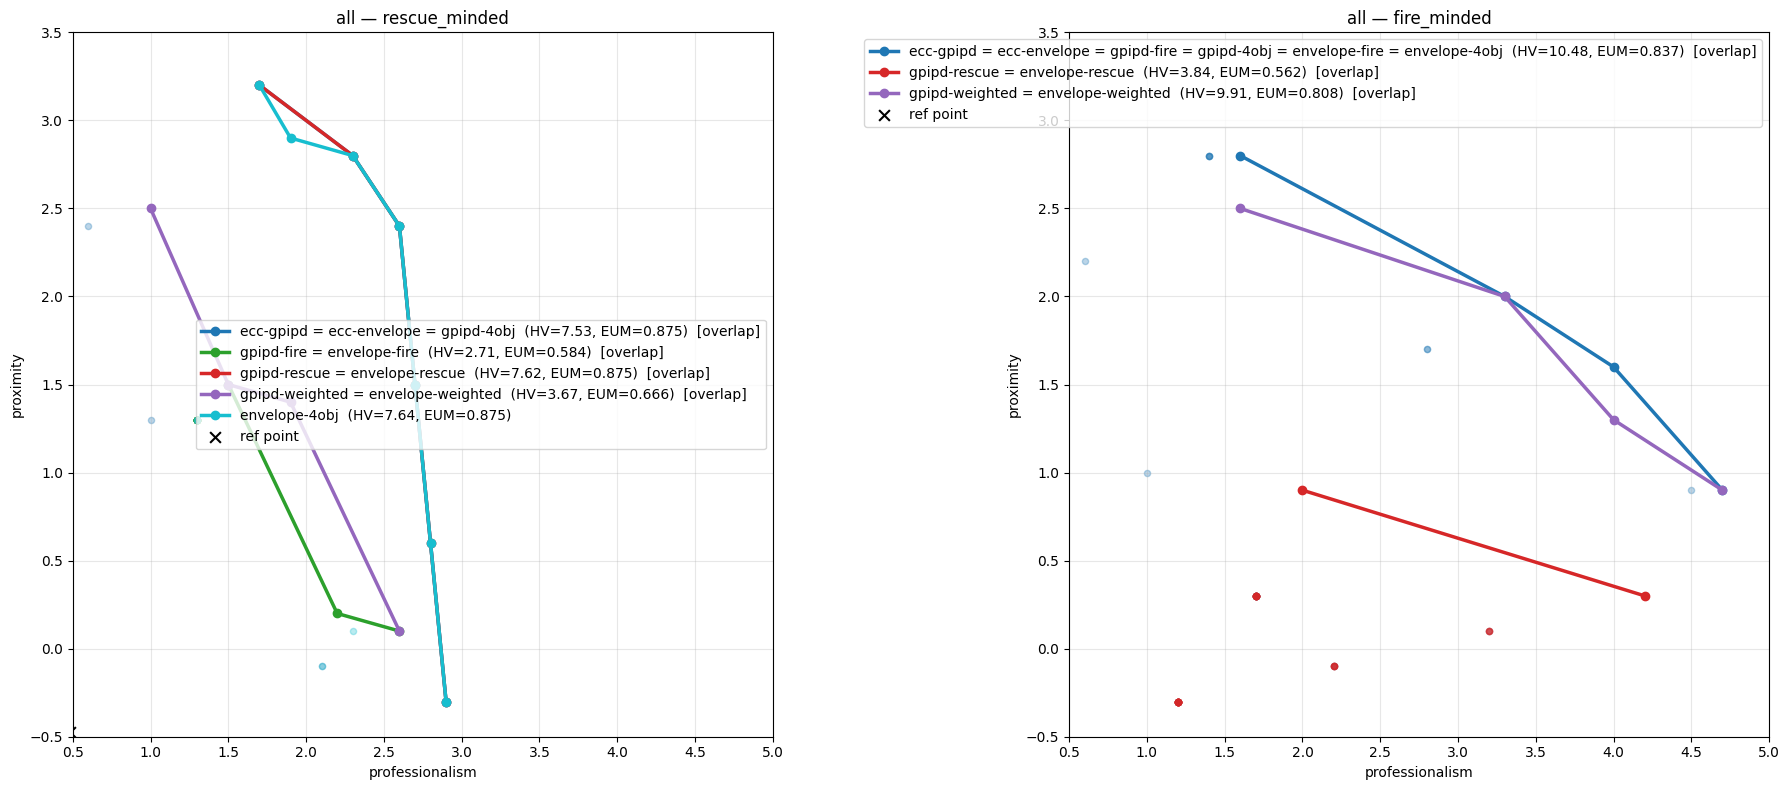

saved C:/Users/skakr/Documents/Programming/Master-Thesis-Report/figures/firefighters\ff_single_interp_baselines.png


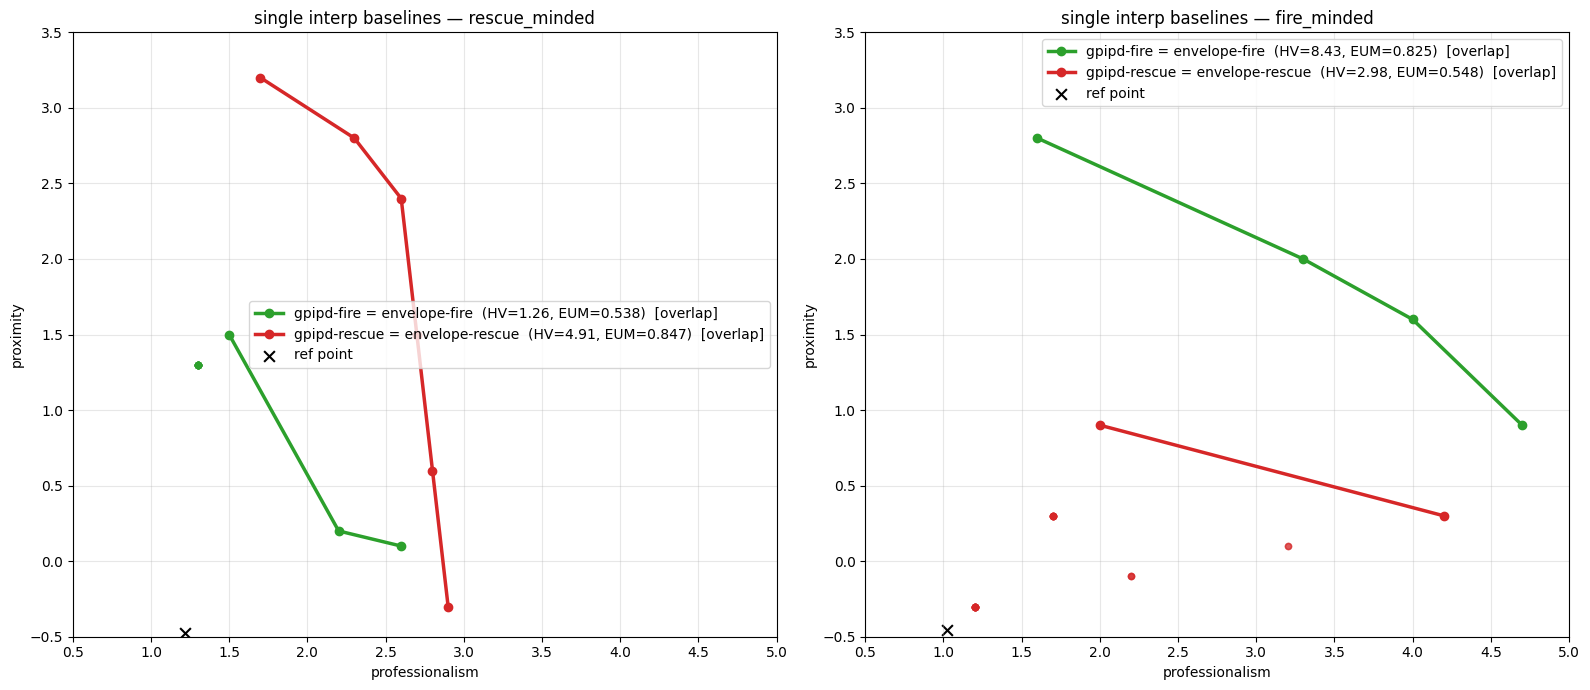

saved C:/Users/skakr/Documents/Programming/Master-Thesis-Report/figures/firefighters\ff_weighted_baselines.png


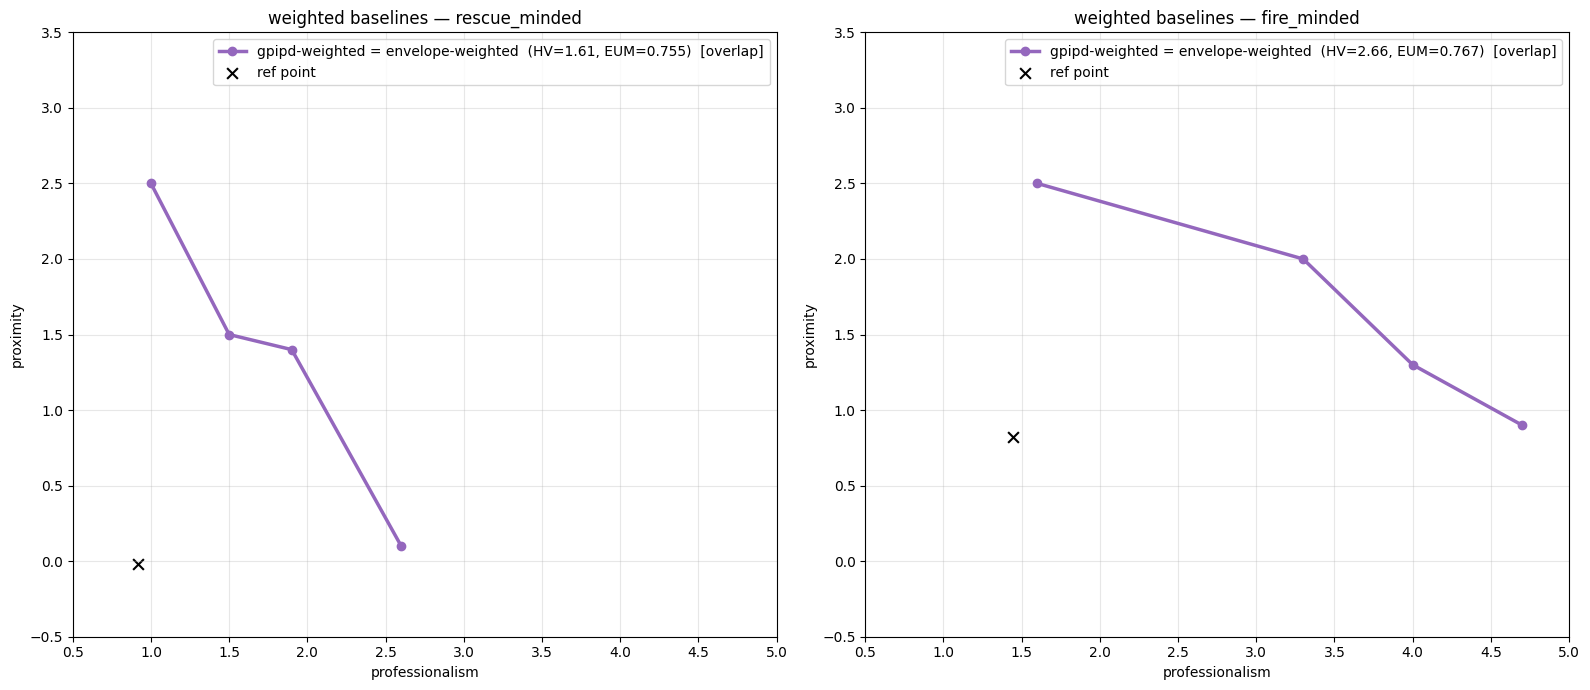

saved C:/Users/skakr/Documents/Programming/Master-Thesis-Report/figures/firefighters\ff_4obj_baselines.png


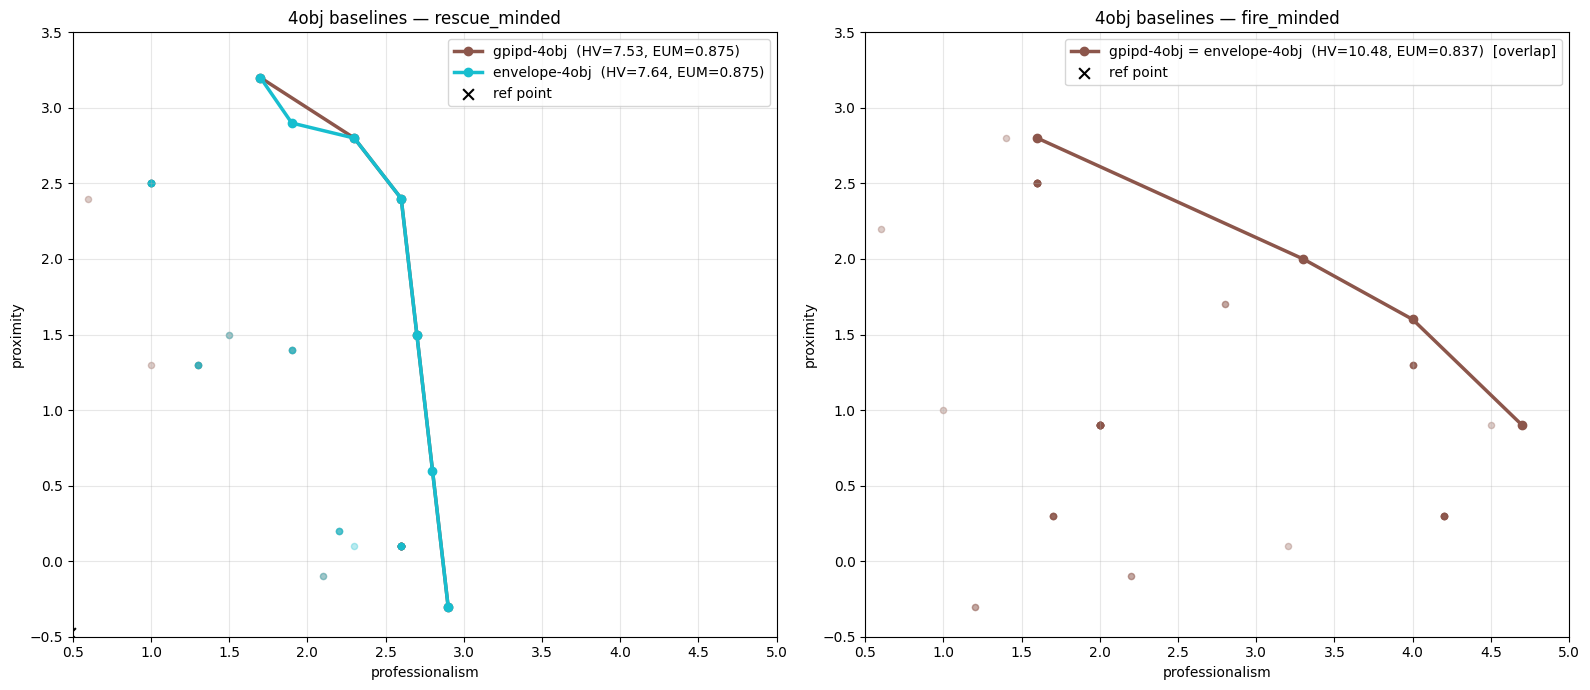

saved C:/Users/skakr/Documents/Programming/Master-Thesis-Report/figures/firefighters\ff_outer_loop_mimorl.png


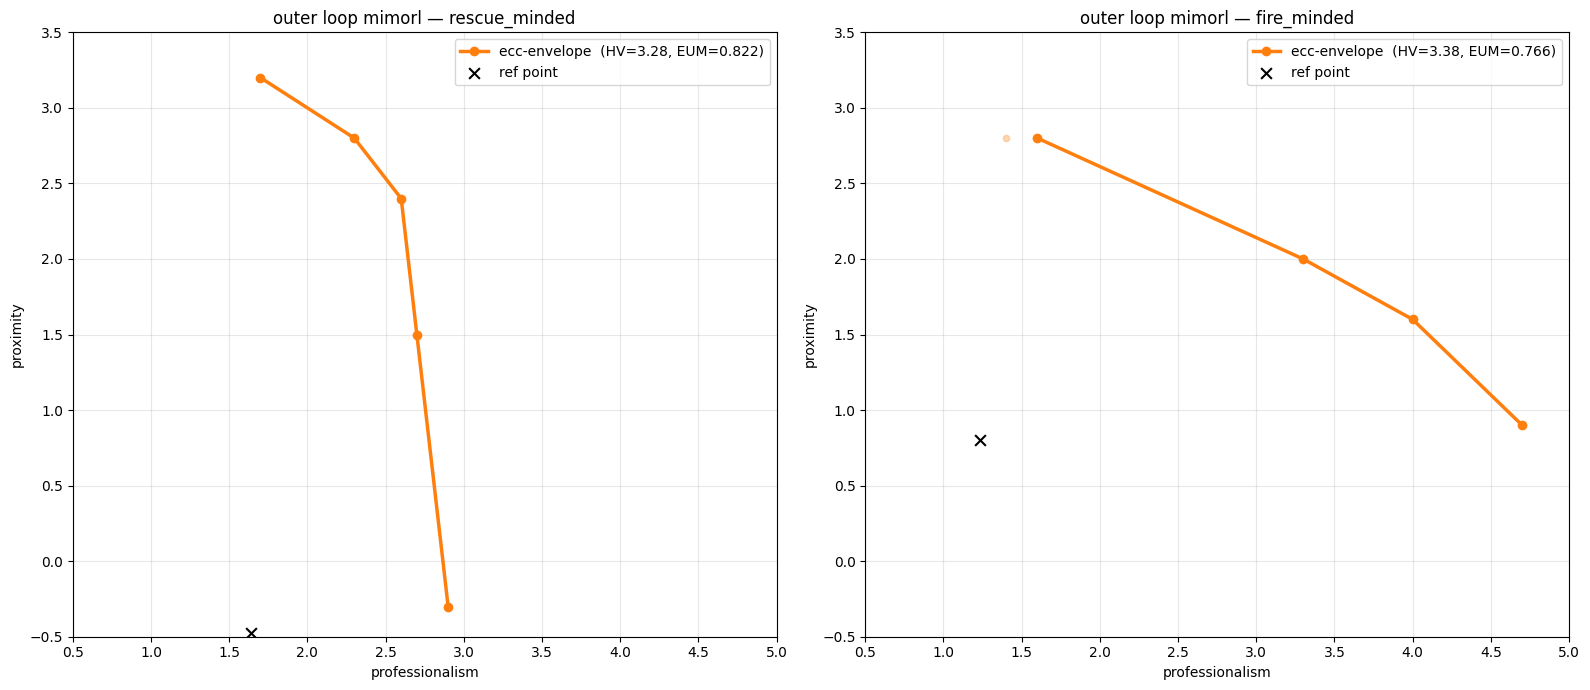

saved C:/Users/skakr/Documents/Programming/Master-Thesis-Report/figures/firefighters\ff_outer_loop_vs_mo.png


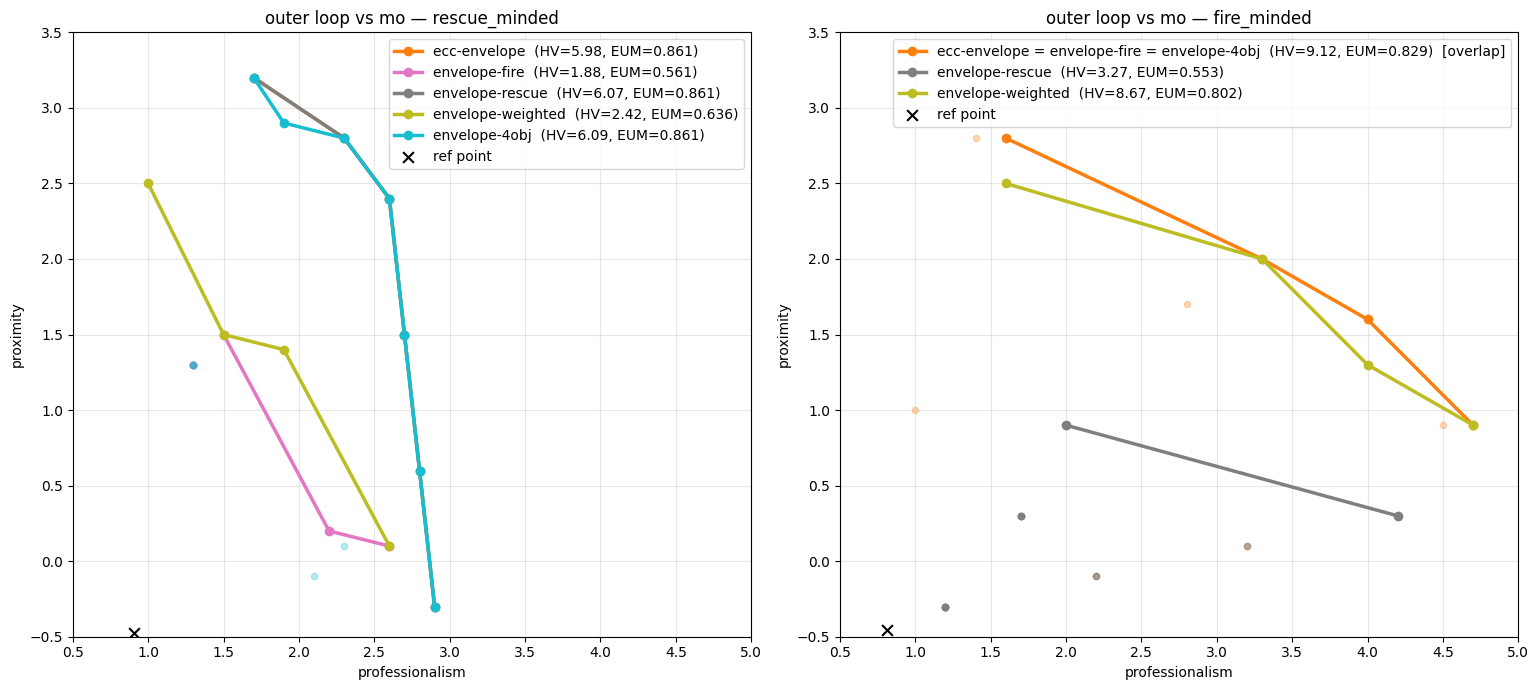

saved C:/Users/skakr/Documents/Programming/Master-Thesis-Report/figures/firefighters\ff_inner_loop_mimorl.png


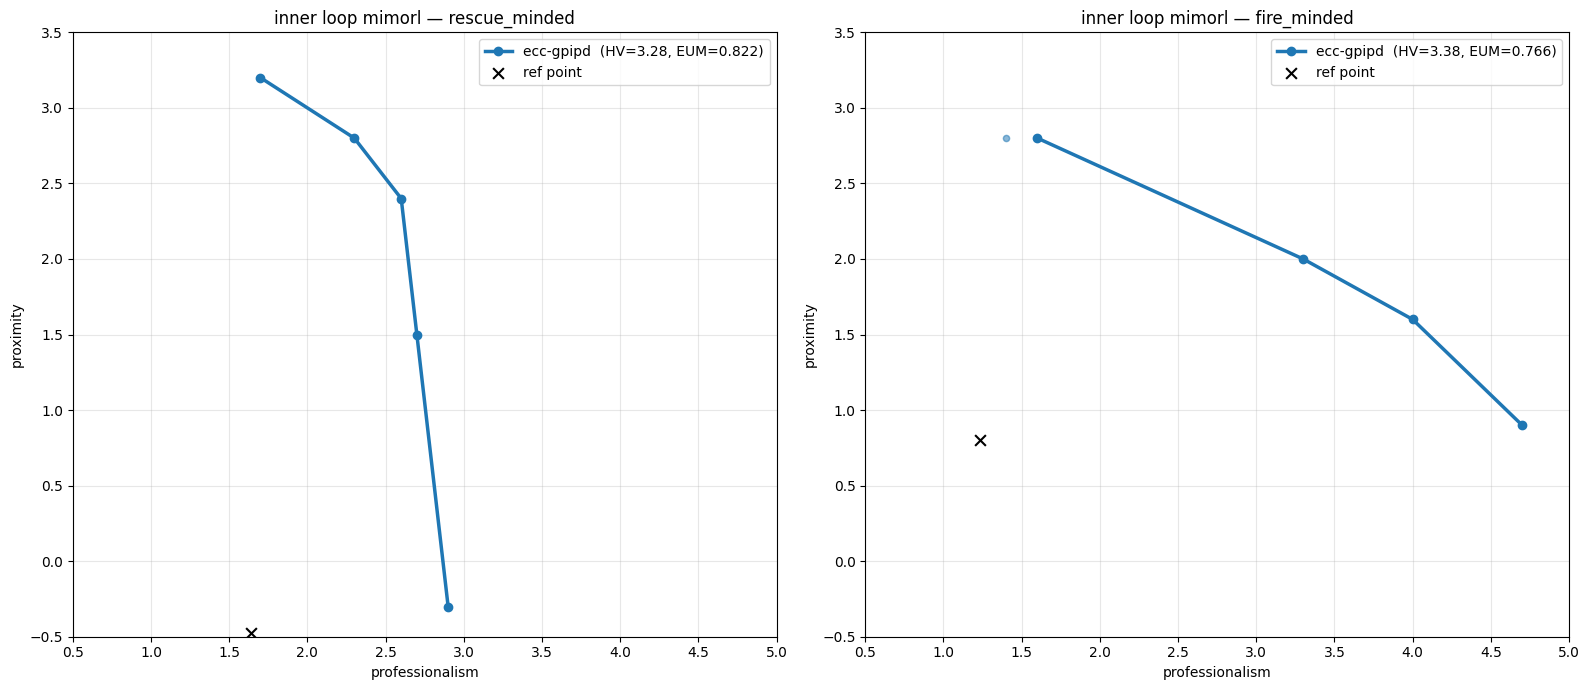

saved C:/Users/skakr/Documents/Programming/Master-Thesis-Report/figures/firefighters\ff_inner_loop_vs_mo.png


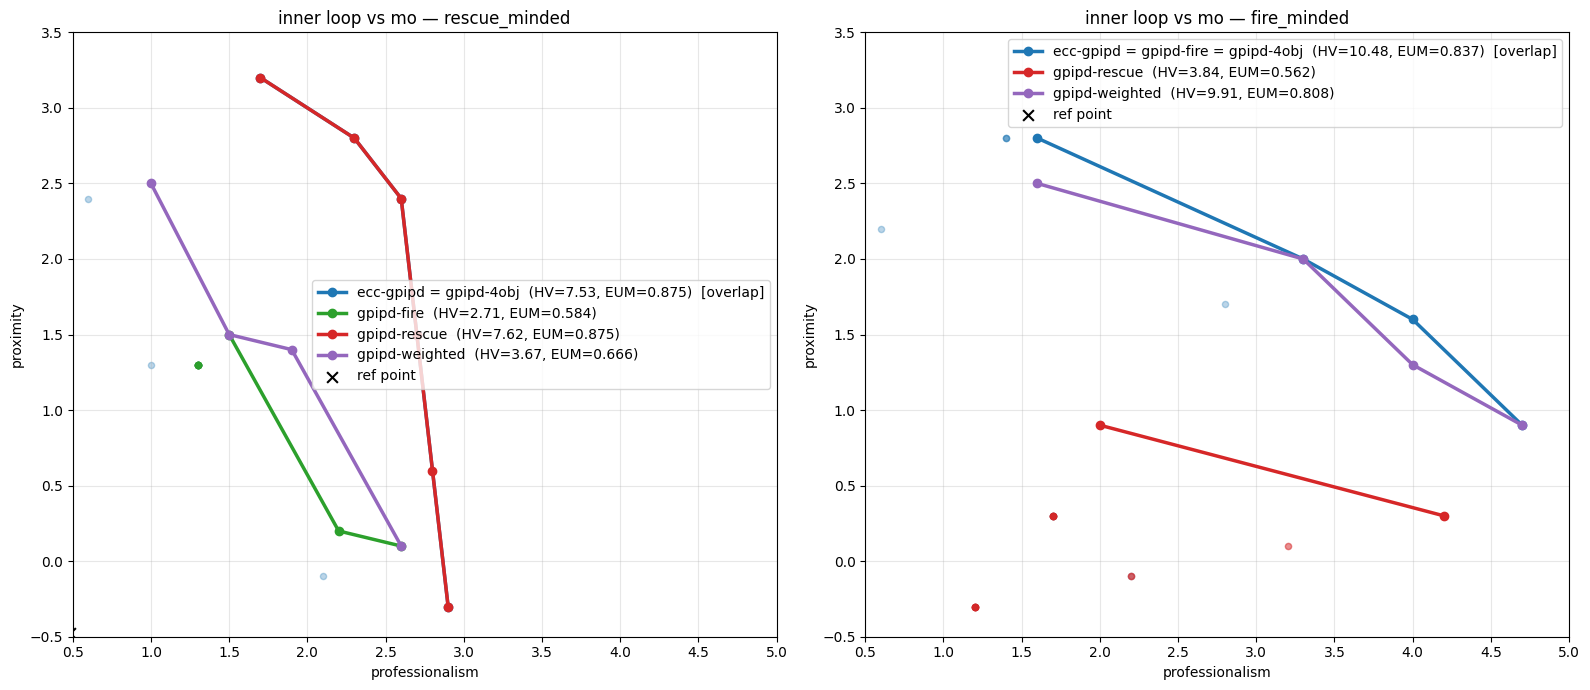

ecc-gpipd & 0.93/0.875 & 0.82/0.837 & 0.82/0.837 \\
ecc-envelope & 0.93/0.875 & 0.82/0.837 & 0.82/0.837 \\
gpipd-fire & 0.34/0.584 & 0.82/0.837 & 0.34/0.584 \\
gpipd-rescue & 0.95/0.875 & 0.30/0.562 & 0.30/0.562 \\
gpipd-weighted & 0.46/0.666 & 0.78/0.808 & 0.46/0.666 \\
gpipd-4obj & 0.93/0.875 & 0.82/0.837 & 0.82/0.837 \\
envelope-fire & 0.34/0.584 & 0.82/0.837 & 0.34/0.584 \\
envelope-rescue & 0.95/0.875 & 0.30/0.562 & 0.30/0.562 \\
envelope-weighted & 0.46/0.666 & 0.78/0.808 & 0.46/0.666 \\
envelope-4obj & 0.95/0.875 & 0.82/0.837 & 0.82/0.837 \\
saved C:/Users/skakr/Documents/Programming/Master-Thesis-Report/figures/firefighters\ff_bars.png


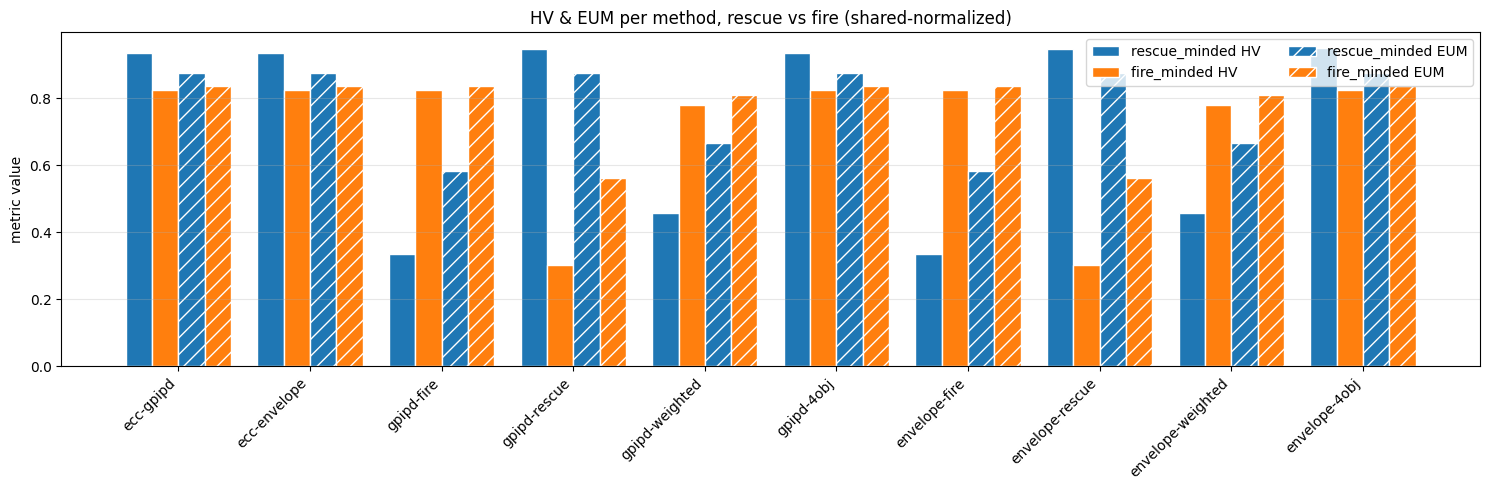

{'ecc-gpipd': {'rescue_minded': (0.9347979317244051, 0.8753675282828248),
  'fire_minded': (0.8247659014946004, 0.8367707355734446)},
 'ecc-envelope': {'rescue_minded': (0.9347979332052613, 0.8753675282828248),
  'fire_minded': (0.8247659014946004, 0.8367707355734446)},
 'gpipd-fire': {'rescue_minded': (0.33628882559437073, 0.5837498770191564),
  'fire_minded': (0.8247659014946004, 0.8367707355734446)},
 'gpipd-rescue': {'rescue_minded': (0.9459783203701478, 0.8753675282828248),
  'fire_minded': (0.3017919265371698, 0.5616348929671495)},
 'gpipd-weighted': {'rescue_minded': (0.45616482545974657, 0.6656613958367348),
  'fire_minded': (0.7798012794897433, 0.8078949531480701)},
 'gpipd-4obj': {'rescue_minded': (0.9347979317244051, 0.8753675282828248),
  'fire_minded': (0.8247659014946004, 0.8367707355734446)},
 'envelope-fire': {'rescue_minded': (0.33628882559437073, 0.5837498770191564),
  'fire_minded': (0.8247659014946004, 0.8367707355734446)},
 'envelope-rescue': {'rescue_minded': (0.9

In [6]:

save_all_figures()

# 4-bars-per-method (rescue/fire x HV/EUM) summary over all contested methods.
plot_metric_bars(
    _ms(*SAVE_CONTESTED_RUNS),
    INTERPRETATIONS,
    save_path=os.path.join(FIG_DIR, "ff_bars.png"),
)


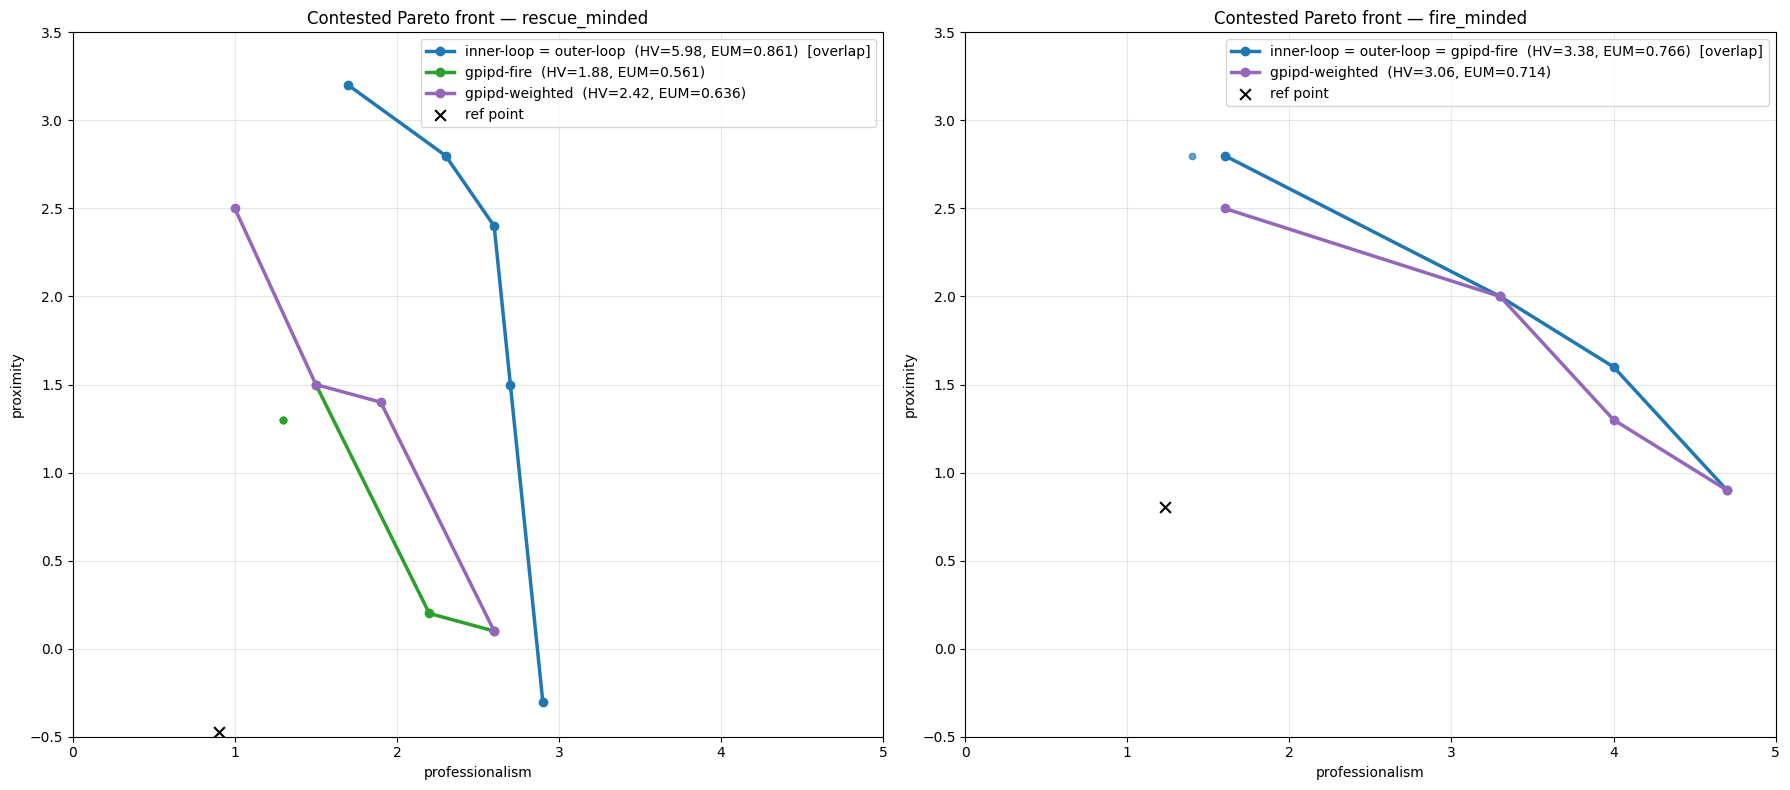

inner-loop & 0.90/0.861 & 0.54/0.766 & 0.54/0.766 \\
outer-loop & 0.90/0.861 & 0.54/0.766 & 0.54/0.766 \\
gpipd-fire & 0.28/0.561 & 0.54/0.766 & 0.28/0.561 \\
gpipd-weighted & 0.36/0.636 & 0.49/0.714 & 0.36/0.636 \\


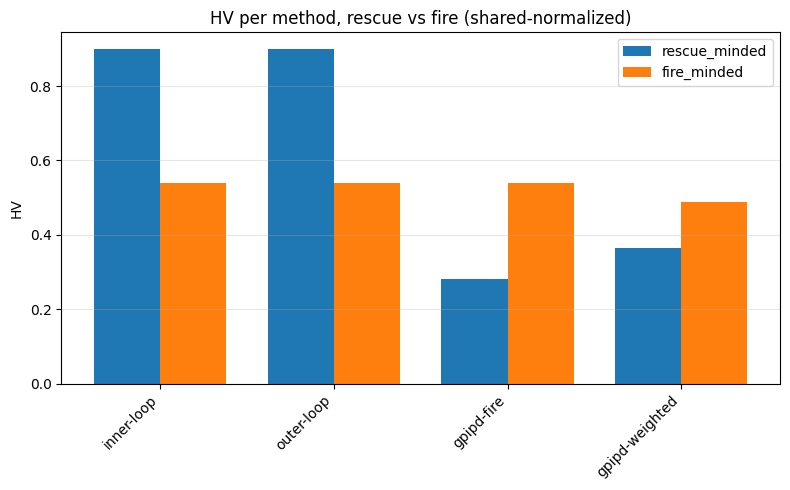

{'inner-loop': {'rescue_minded': (0.899492323547262, 0.8608482026556594),
  'fire_minded': (0.5395013635187341, 0.7664303657687422)},
 'outer-loop': {'rescue_minded': (0.8994923253398774, 0.8608482026556594),
  'fire_minded': (0.5395013635187341, 0.7664303657687422)},
 'gpipd-fire': {'rescue_minded': (0.28234963307926564, 0.5607667478677794),
  'fire_minded': (0.5395013635187341, 0.7664303657687422)},
 'gpipd-weighted': {'rescue_minded': (0.36430479663742127, 0.635947976028369),
  'fire_minded': (0.4885445469449068, 0.7135071224349743)}}

In [22]:
# Contested runs, resolved through SAVE_CONTESTED_RUNS -- list only the LABELS to plot
# (comment a label out to drop it). The per-interp eval files live in the TRAIN run dirs
# (eval_both_interps=true wrote them there), not an eval/<id> subdir.
CONTESTED_LABELS = [
    INNER_LOOP_LABEL,
    OUTER_LOOP_LABEL,
    "gpipd-fire",
    # "gpipd-rescue",
    "gpipd-weighted",
    # "gpipd-4obj",
    # "envelope-fire",
    # "envelope-rescue",
    # "envelope-weighted",
    # "envelope-4obj",
]
contested_methods = [
    (label, contested_run(label), ecc_files(INTERPRETATIONS))
    for label in CONTESTED_LABELS
]
plot_pareto_fronts(
    contested_methods,
    interpretations=INTERPRETATIONS,
    objective_labels=("professionalism", "proximity"),
    title="Contested Pareto front",
    normalize="none",   # "shared" to rescale each subplot to [0, 1]
    figsize=(18, 8),
    xlim=(0,5),
    ylim=(-0.5, 3.5)
)
latex_table_rows(contested_methods, interpretations=INTERPRETATIONS, normalize="shared")

c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\envs\registration.py:480: UserWarning: WARN: The environment creator metadata doesn't include `render_modes`, contains: ['render.modes']
  logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:245: UserWarning: WARN: The reward returned by `step()` must be a float, int, np.integer or np.floating, actual type: <class 'numpy.ndarray'>
  logger.warn(


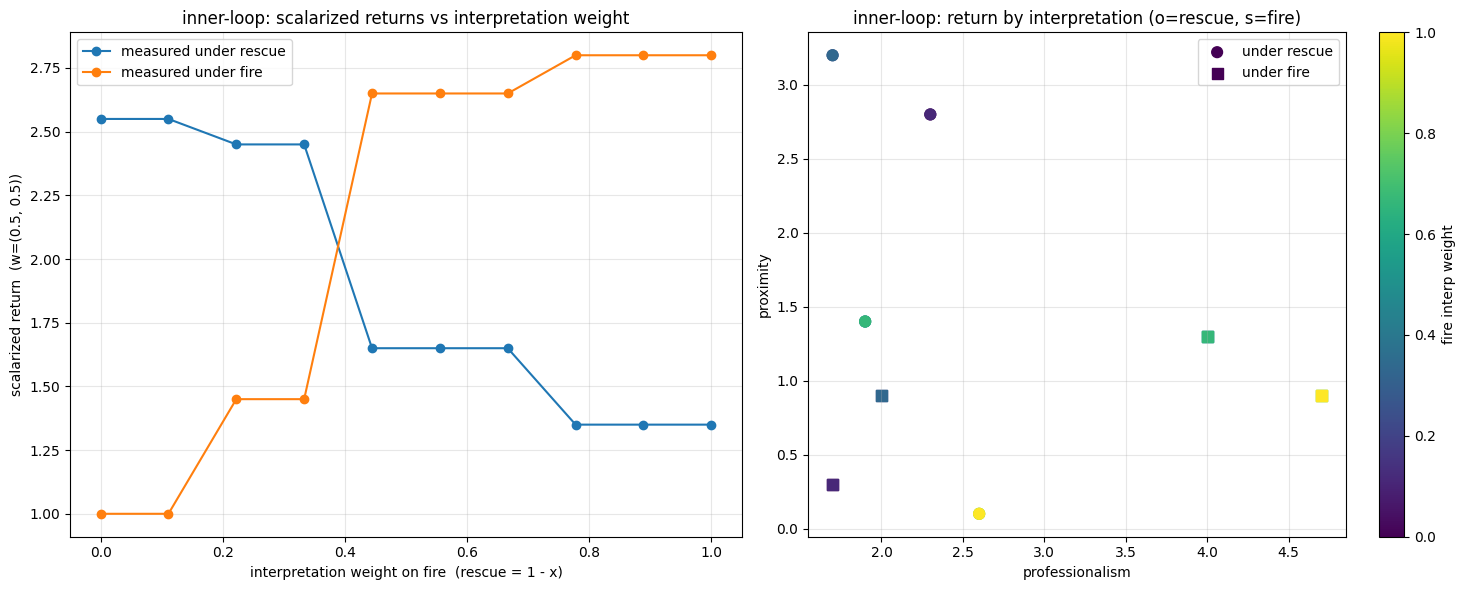

(array([[1.    , 0.    ],
        [0.8889, 0.1111],
        [0.7778, 0.2222],
        [0.6667, 0.3333],
        [0.5556, 0.4444],
        [0.4444, 0.5556],
        [0.3333, 0.6667],
        [0.2222, 0.7778],
        [0.1111, 0.8889],
        [0.    , 1.    ]], dtype=float32),
 array([[2.3, 2.8, 1.7, 0.3],
        [2.3, 2.8, 1.7, 0.3],
        [1.7, 3.2, 2. , 0.9],
        [1.7, 3.2, 2. , 0.9],
        [1.9, 1.4, 4. , 1.3],
        [1.9, 1.4, 4. , 1.3],
        [1.9, 1.4, 4. , 1.3],
        [2.6, 0.1, 4.7, 0.9],
        [2.6, 0.1, 4.7, 0.9],
        [2.6, 0.1, 4.7, 0.9]]))

In [23]:
# Sweep an ECC agent's INTERPRETATION weight from (1, 0) rescue -> (0, 1) fire.
# Only ECC agents (ecc_gpi_pd / ecc_envelope) take interp_w; plain gpipd/envelope don't.
# The agent is conditioned on each interp_w and rolled out on the raw (un-projected) env,
# so we read its return under BOTH interpretations at once:
#   reward = [rescue_pf, rescue_px, fire_pf, fire_px]  -> cols 0:2 rescue, 2:4 fire.
import json
from scripts.utils import make_agent, make_env  # env registered on import in the first cell


def eval_interp_weight_sweep(config_path, run_dir, n_steps=10, w=(0.5, 0.5), episodes=30):
    """Return (interp_weights [n_steps, 2], mean_returns [n_steps, 2*num_interps]).

    config_path : the run's TRAINING config (must match the checkpoint's arch)
    run_dir     : folder holding model.tar
    w           : fixed objective weight over (professionalism, proximity)
    interp_w    : swept linearly from (1, 0) rescue to (0, 1) fire in n_steps
    """
    cfg = json.load(open(config_path))
    env_config = dict(cfg["env"]); agent_config = dict(cfg["agent"]); agent_config["log"] = False
    # drop any single-interpretation projection so the env emits the raw multi-interp reward
    for k in ("interp_index", "interp_weight_wrapper", "deontological_wrapper", "utilitarian_wrapper"):
        env_config.pop(k, None)
    e = make_env(dict(env_config))
    agent = make_agent(env=e, agent_config=dict(agent_config))
    agent.load(run_dir.rstrip("/\\") + "/model.tar")

    iws = np.stack([np.array([1 - t, t], np.float32) for t in np.linspace(0, 1, n_steps)])
    w = np.asarray(w, np.float32)
    rows = []
    for iw in iws:
        agent.set_eval_interp_weight(iw.tolist())
        rets = []
        for _ in range(episodes):
            obs, _ = e.reset(); done = False
            ret = np.zeros(e.unwrapped.reward_space.shape[0])
            while not done:
                a = agent.eval(obs, w, iw)
                obs, r, term, trunc, _ = e.step(int(a)); ret += r; done = term or trunc
            rets.append(ret)
        rows.append(np.mean(rets, axis=0))
    return iws, np.array(rows)


def plot_interp_weight_sweep(config_path, run_dir, title, n_steps=10, w=(0.5, 0.5),
                             episodes=30):
    """Plot return under each interpretation as interp_w slides rescue -> fire."""
    iws, R = eval_interp_weight_sweep(config_path, run_dir, n_steps, w, episodes)
    fire_w = iws[:, 1]                       # x-axis: weight on the fire interpretation
    w = np.asarray(w, np.float32)
    rescue_val = R[:, 0:2] @ w               # scalarized value measured under rescue reward
    fire_val = R[:, 2:4] @ w                 # scalarized value measured under fire reward

    fig, (axL, axR) = plt.subplots(1, 2, figsize=(15, 6))
    # left: scalarized value under each interpretation vs interp weight
    axL.plot(fire_w, rescue_val, "-o", color="tab:blue", label="measured under rescue")
    axL.plot(fire_w, fire_val, "-o", color="tab:orange", label="measured under fire")
    axL.set_xlabel("interpretation weight on fire  (rescue = 1 - x)")
    axL.set_ylabel(f"scalarized return  (w={tuple(w)})")
    axL.set_title(f"{title}: scalarized returns vs interpretation weight")
    axL.legend(); axL.grid(True, alpha=0.3)
    # right: the (professionalism, proximity) trajectory under each interpretation,
    # colored by interp weight
    sc = axR.scatter(R[:, 0], R[:, 1], c=fire_w, cmap="viridis", s=60, marker="o",
                     label="under rescue")
    axR.scatter(R[:, 2], R[:, 3], c=fire_w, cmap="viridis", s=60, marker="s",
                label="under fire")
    axR.set_xlabel("professionalism"); axR.set_ylabel("proximity")
    axR.set_title(f"{title}: return by interpretation (o=rescue, s=fire)")
    fig.colorbar(sc, ax=axR, label="fire interp weight")
    axR.legend(); axR.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
    return iws, R


# config per ECC agent (configs must match the checkpoints' arch); run dirs come from
# SAVE_CONTESTED_RUNS via contested_run().
ECC_RUNS = {
    label: (f"scripts/config/firefighters_{label.replace('-', '_')}_contested.json",
            contested_run(label))
    for label in (INNER_LOOP_LABEL, OUTER_LOOP_LABEL)
}

cfg_path, _rd = ECC_RUNS[INNER_LOOP_LABEL]
plot_interp_weight_sweep(cfg_path, _rd, title=INNER_LOOP_LABEL, n_steps=10, episodes=30)

c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\envs\registration.py:480: UserWarning: WARN: The environment creator metadata doesn't include `render_modes`, contains: ['render.modes']
  logger.warn(


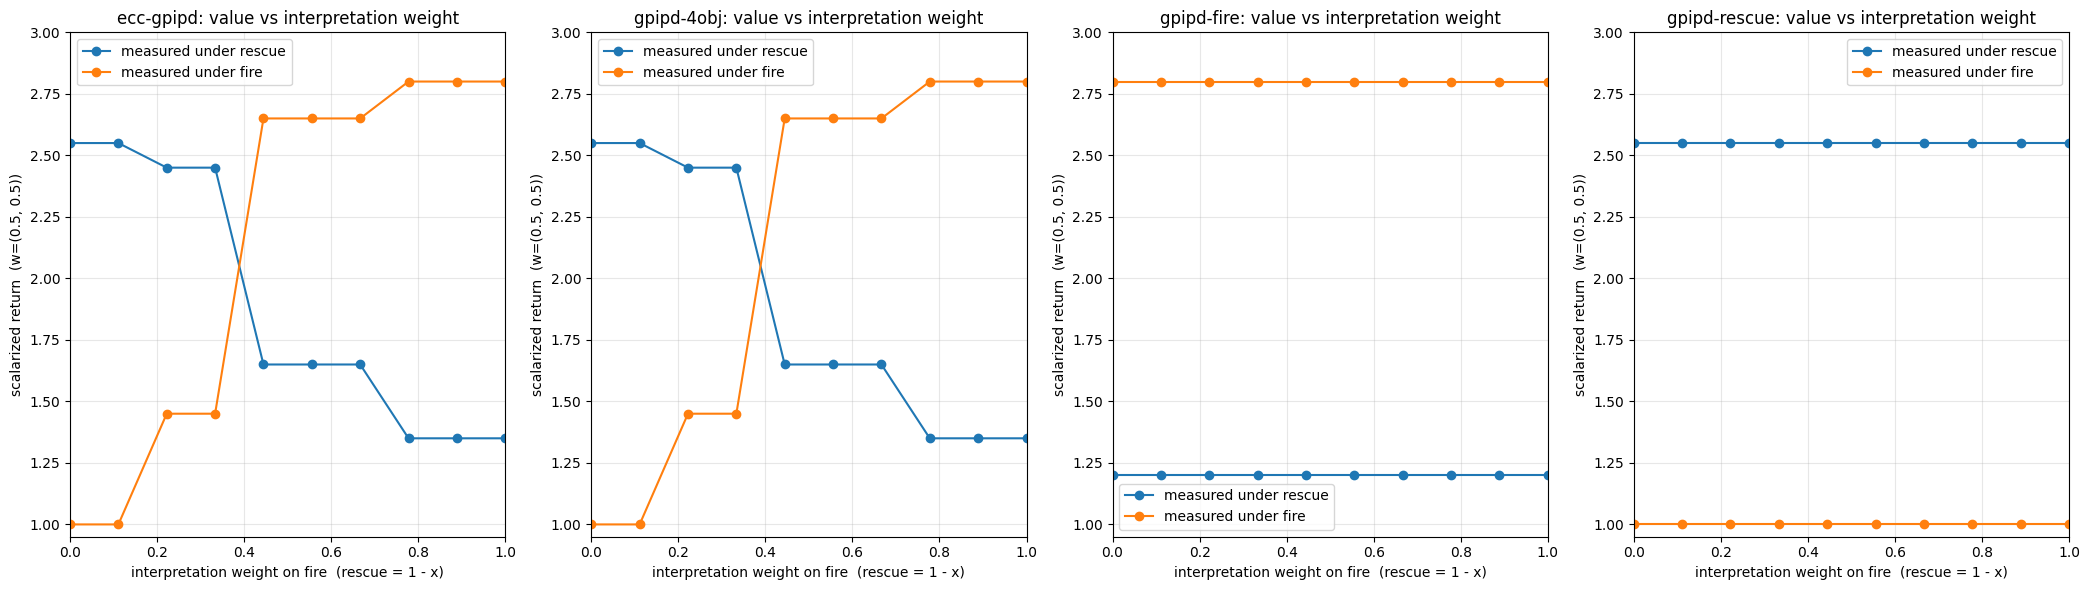

In [ ]:
# Value-vs-interpretation-weight (the LEFT panel of plot_interp_weight_sweep) for FOUR models,
# side by side: ecc-gpipd, gpipd-4obj, gpipd-fire, gpipd-rescue. Objective weight fixed at (0.5, 0.5).
#   * ecc-gpipd: re-conditioned on each interp_w -> the two lines slope (it ADAPTS).
#   * gpipd-4obj: flat MORL over the concatenated 4-D reward. It has no interp_w either, but the
#     interpretation weighting folds into its objective weight,
#         w4(t) = [(1 - t) * w, t * w],
#     which is exactly the scalarization the ECC agent conditions on -- so it is re-conditioned per
#     interp weight too and its lines slope.
#   * gpipd-fire / gpipd-rescue: single-interpretation baselines, no interp_w -> FLAT lines
#     (fixed policy; shown as a reference). One rollout each, tiled across interp weights.
# The single-interpretation baselines are built on their projected (2-D) env to match the
# checkpoint, then rolled on the raw 4-D env to read both interpretations at once (building on the
# raw env would dim-mismatch). gpipd-4obj was trained on the raw 4-D env, so it uses it throughout.
_W = (0.5, 0.5)
_NS, _EP = 10, 30
_iws = np.stack([np.array([1 - t, t], np.float32) for t in np.linspace(0, 1, _NS)])

_MODELS4 = {   # label -> (kind, config, run_dir); run dirs from SAVE_CONTESTED_RUNS
    label: (kind, f"scripts/config/firefighters_{label.replace('-', '_')}_contested.json",
            contested_run(label))
    for label, kind in ((INNER_LOOP_LABEL, "ecc"), ("gpipd-4obj", "4obj"),
                        ("gpipd-fire", "baseline"), ("gpipd-rescue", "baseline"))
}


def _raw_env_config(env_config):
    """Strip any single-interpretation projection so the env emits the raw 4-D reward."""
    out = dict(env_config)
    for k in ("interp_index", "interp_weight_wrapper", "deontological_wrapper", "utilitarian_wrapper"):
        out.pop(k, None)
    return out


def _rollout(agent, env, w, episodes):
    """Mean raw (4-D) return of `agent` acting under objective weight `w` on `env`."""
    w = np.asarray(w, np.float32)
    rets = []
    for _ in range(episodes):
        obs, _ = env.reset(); done = False
        ret = np.zeros(env.unwrapped.reward_space.shape[0])
        while not done:
            a = agent.eval(obs, w)                       # no interp_w: plain GPI-PD signature
            obs, r, term, trunc, _ = env.step(int(a)); ret += r; done = term or trunc
        rets.append(ret)
    return np.mean(rets, axis=0)


def _returns_vs_interp(kind, config_path, run_dir, w=_W, n_steps=_NS, episodes=_EP):
    """R4d [n_steps, 4] = mean return (cols 0:2 rescue, 2:4 fire) at objective weight w."""
    if kind == "ecc":
        _, R = eval_interp_weight_sweep(config_path, run_dir, n_steps=n_steps, w=w, episodes=episodes)
        return R

    cfg = json.load(open(config_path))
    ec = dict(cfg["env"]); ac = dict(cfg["agent"]); ac["log"] = False
    # the agent must be built on the env it was TRAINED on so reward_dim matches the checkpoint:
    # raw 4-D for gpipd-4obj, projected 2-D for the single-interpretation baselines
    train_env = make_env(_raw_env_config(ec) if kind == "4obj" else dict(ec))
    agent = make_agent(env=train_env, agent_config=dict(ac))
    agent.load(run_dir.rstrip("/\\") + "/model.tar")
    raw = make_env(_raw_env_config(ec))                  # roll out on the raw 4-D reward
    wv = np.asarray(w, np.float32)

    if kind == "4obj":
        # fold the interpretation weight into the 4-D objective weight, one rollout per step
        return np.stack([_rollout(agent, raw, np.concatenate([iw[0] * wv, iw[1] * wv]), episodes)
                         for iw in _iws])
    return np.tile(_rollout(agent, raw, wv, episodes), (n_steps, 1))   # constant across interp weights


fig, axes = plt.subplots(1, 4, figsize=(21, 6))
fire_w = _iws[:, 1]
wv = np.asarray(_W, np.float32)
for ax, (label, (kind, cfgp, rd)) in zip(axes, _MODELS4.items()):
    R = _returns_vs_interp(kind, cfgp, rd)
    ax.plot(fire_w, R[:, 0:2] @ wv, "-o", color="tab:blue", label="measured under rescue")
    ax.plot(fire_w, R[:, 2:4] @ wv, "-o", color="tab:orange", label="measured under fire")
    ax.set_xlabel("interpretation weight on fire  (rescue = 1 - x)")
    ax.set_ylabel(f"scalarized return  (w={_W})")
    ax.set_title(f"{label}: value vs interpretation weight")
    ax.legend(); ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 1)
    ax.set_ylim(0.95, 3)
fig.tight_layout()
fig.savefig(os.path.join("figures", "ff_value_vs_interp_4models.png"), dpi=150, bbox_inches="tight")
plt.show()


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\envs\registration.py:480: UserWarning: WARN: The environment creator metadata doesn't include `render_modes`, contains: ['render.modes']
  logger.warn(


wrote results/firefighters-mo-contested-v0\ecc_gpi_pd__30000__govvtrva/eval_returns_scalarized.npy
wrote results/firefighters-mo-contested-v0\ecc_envelope__40000__d0g6brv2/eval_returns_scalarized.npy
wrote results/firefighters-mo-contested-v0\gpi_pd__5000__850yazz0/eval_returns_scalarized.npy
wrote results/firefighters-mo-contested-v0\gpi_pd__5000__dzks0la5/eval_returns_scalarized.npy
wrote results/firefighters-mo-contested-v0\gpi_pd__5000__ptvunkk9/eval_returns_scalarized.npy
wrote results/firefighters-mo-contested-v0\gpi_pd__30000__fw38o6ug/eval_returns_scalarized.npy
wrote results/firefighters-mo-contested-v0\envelope__20000__3gr8w2k0/eval_returns_scalarized.npy
wrote results/firefighters-mo-contested-v0\envelope__20000__8ytmfd9y/eval_returns_scalarized.npy
wrote results/firefighters-mo-contested-v0\envelope__20000__9d7yhdgy/eval_returns_scalarized.npy
wrote results/firefighters-mo-contested-v0\envelope__20000__kwst1vqf/eval_returns_scalarized.npy


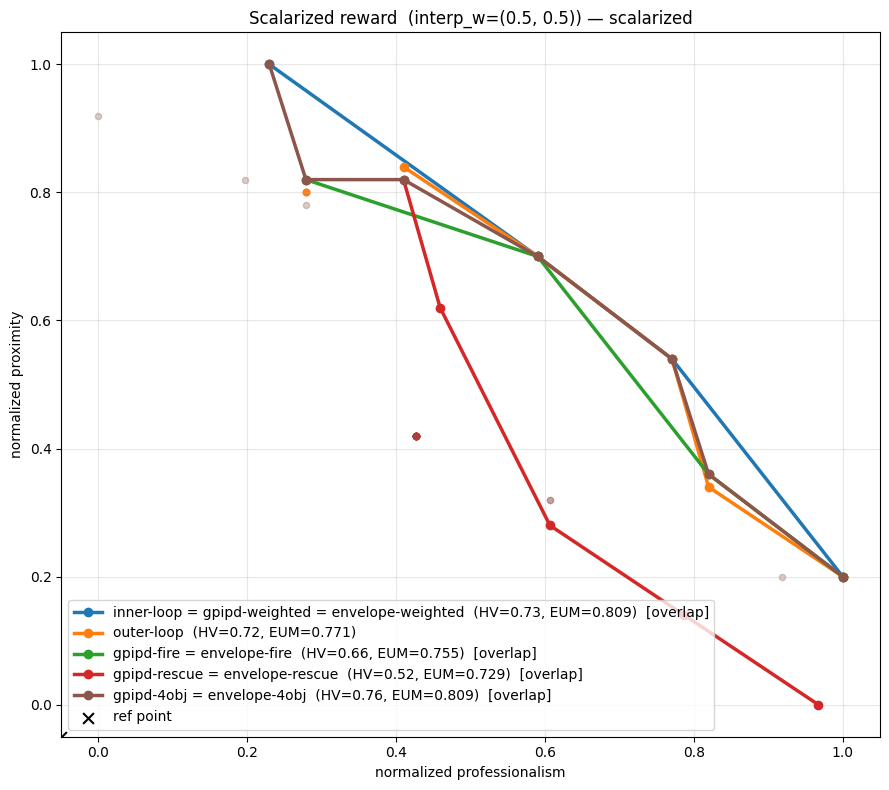

In [25]:
# Scalarized-reward evaluation: measure each method on the InterpWeightWrapper env,
# whose reward is  interp_w . [rescue, fire]  -> a single (professionalism, proximity)
# vector. Writes eval_returns_scalarized.npy into each run dir so it plots like any
# other interpretation (pass interpretations=("scalarized",) or add it to INTERPRETATIONS).
#
#  * BASELINES (single policy): scalarized == interp_w-weighted combo of their existing
#    per-interp eval files. Exact on the deterministic env, since a single policy's rescue
#    and fire eval share each weight's trajectory -> derived from files, no re-rollout.
#  * ECC agents: their rescue/fire files come from DIFFERENT interp-conditioned policies,
#    so we roll out the agent conditioned on interp_w and measure under the scalarized reward.
#
# The expensive ECC rollout is CACHED to eval_returns_<out_name>.npy and reused if present
# (matched on num_weights); pass force=True to recompute.
from morl_baselines.common.weights import equally_spaced_weights

SCAL_INTERP_W = (0.5, 0.5)  # weight over (rescue, fire); the "weighted" baseline used this


def scalarize_from_files(run_dir, interp_w=SCAL_INTERP_W, interps=INTERPRETATIONS,
                         out_name="scalarized"):
    """Baseline scalarized front = interp_w-weighted combo of per-interp eval files."""
    w = np.asarray(interp_w, np.float32)
    stk = np.stack([np.load(os.path.join(run_dir, f"eval_returns_{i}.npy")) for i in interps])
    scal = np.tensordot(w, stk, axes=(0, 0)).astype(np.float32)  # (num_weights, 2)
    np.save(os.path.join(run_dir, f"eval_returns_{out_name}.npy"), scal)
    return scal


def scalarize_rollout(config_path, run_dir, interp_w=SCAL_INTERP_W, num_weights=50,
                      episodes=20, out_name="scalarized", force=False):
    """Roll the agent out on the scalarized (InterpWeightWrapper) env; works for any agent.

    Cached to eval_returns_<out_name>.npy and reused if present (out_name must uniquely
    identify interp_w); pass force=True to recompute. ECC agents are conditioned on interp_w
    and sweep the objective weight over net_reward_dim; single-policy agents sweep reward_dim.
    """
    target = os.path.join(run_dir.rstrip("/\\"), f"eval_returns_{out_name}.npy")
    if not force and os.path.exists(target):
        cached = np.load(target)
        if cached.shape[0] == num_weights:
            return cached

    cfg = json.load(open(config_path))
    ec = dict(cfg["env"]); ac = dict(cfg["agent"]); ac["log"] = False
    for k in ("interp_index", "interp_weight_wrapper", "deontological_wrapper", "utilitarian_wrapper"):
        ec.pop(k, None)
    agent = make_agent(env=make_env(dict(ec)), agent_config=dict(ac))
    agent.load(run_dir.rstrip("/\\") + "/model.tar")
    is_ecc = hasattr(agent, "set_eval_interp_weight")
    iw = np.asarray(interp_w, np.float32)
    if is_ecc:
        agent.set_eval_interp_weight(iw.tolist())
    w_dim = agent.net_reward_dim if is_ecc else agent.reward_dim  # ECC: interp_w is separate
    scal_env = make_env(dict(ec, interp_weight_wrapper=True, interp_weight=list(interp_w)))
    weights = equally_spaced_weights(w_dim, num_weights)
    rows = []
    for w in weights:
        rets = []
        for _ in range(episodes):
            obs, _ = scal_env.reset(); done = False; ret = np.zeros(2)
            while not done:
                a = (agent.eval(obs, np.asarray(w, np.float32), iw) if is_ecc
                     else agent.eval(obs, np.asarray(w, np.float32)))
                obs, r, term, trunc, _ = scal_env.step(int(a)); ret += r; done = term or trunc
            rets.append(ret)
        rows.append(np.mean(rets, axis=0))
    scal = np.array(rows).astype(np.float32)
    np.save(target, scal)
    return scal


# every method = SAVE_CONTESTED_RUNS; configs for the (rollout-only) ECC agents
ECC_CONFIGS = {
    INNER_LOOP_LABEL:    "scripts/config/firefighters_inner_loop_contested.json",
    OUTER_LOOP_LABEL: "scripts/config/firefighters_outer_loop_contested.json",
}

for label in SAVE_CONTESTED_RUNS:
    rd = contested_run(label)
    if label in ECC_CONFIGS:
        scalarize_rollout(ECC_CONFIGS[label], rd)        # cached: reused if already computed
    else:
        scalarize_from_files(rd)                         # exact from existing files
    print(f"wrote {rd}/eval_returns_scalarized.npy")
    
scal_methods = [
    (label, contested_run(label), ecc_files(("scalarized",)))
    for label in SAVE_CONTESTED_RUNS
]
plot_pareto_fronts(
    scal_methods,
    interpretations=("scalarized",),
    objective_labels=("professionalism", "proximity"),
    title=f"Scalarized reward  (interp_w={SCAL_INTERP_W})",
    figsize=(9, 8),
)

In [ ]:

os.makedirs("figures", exist_ok=True)

# the envelope models to plot -- LABELS only; run dirs come from SAVE_CONTESTED_RUNS
ENV3_LABELS = [
    OUTER_LOOP_LABEL,
    # "envelope-fire",
    "envelope-rescue",
]
STOP_WEIGHTS = [tuple(np.round([1 - t, t], 2)) for t in np.linspace(0, 1, 5)]

for iw in STOP_WEIGHTS:
    tag = f"scalroll_{iw[0]:.2f}_{iw[1]:.2f}"       # rollout variant (distinct from derived 'scal_' files)
    disp = f"({iw[0]:.2f}, {iw[1]:.2f})"
    for label in ENV3_LABELS:
        scalarize_rollout_any(_config_for(label), contested_run(label),
                              interp_w=iw, out_name=tag)   # cached -> reused if already computed
    methods = [
        (label, contested_run(label), {disp: f"eval_returns_{tag}.npy"})
        for label in ENV3_LABELS
    ]
    plot_pareto_fronts(
        methods,
        interpretations=(disp,),
        objective_labels=("professionalism", "proximity"),
        title="Envelope models, scalarized reward (all rollout), interp_w",
        figsize=(9, 8),
        save_path=os.path.join("figures", f"ff_env3_{tag}.png"),
    )


ecc-gpipd: computed 8, reused 2 of 10 sweeps (results/firefighters-mo-contested-v0\ecc_gpi_pd__7500__qbj8fywu\interp_sweep)


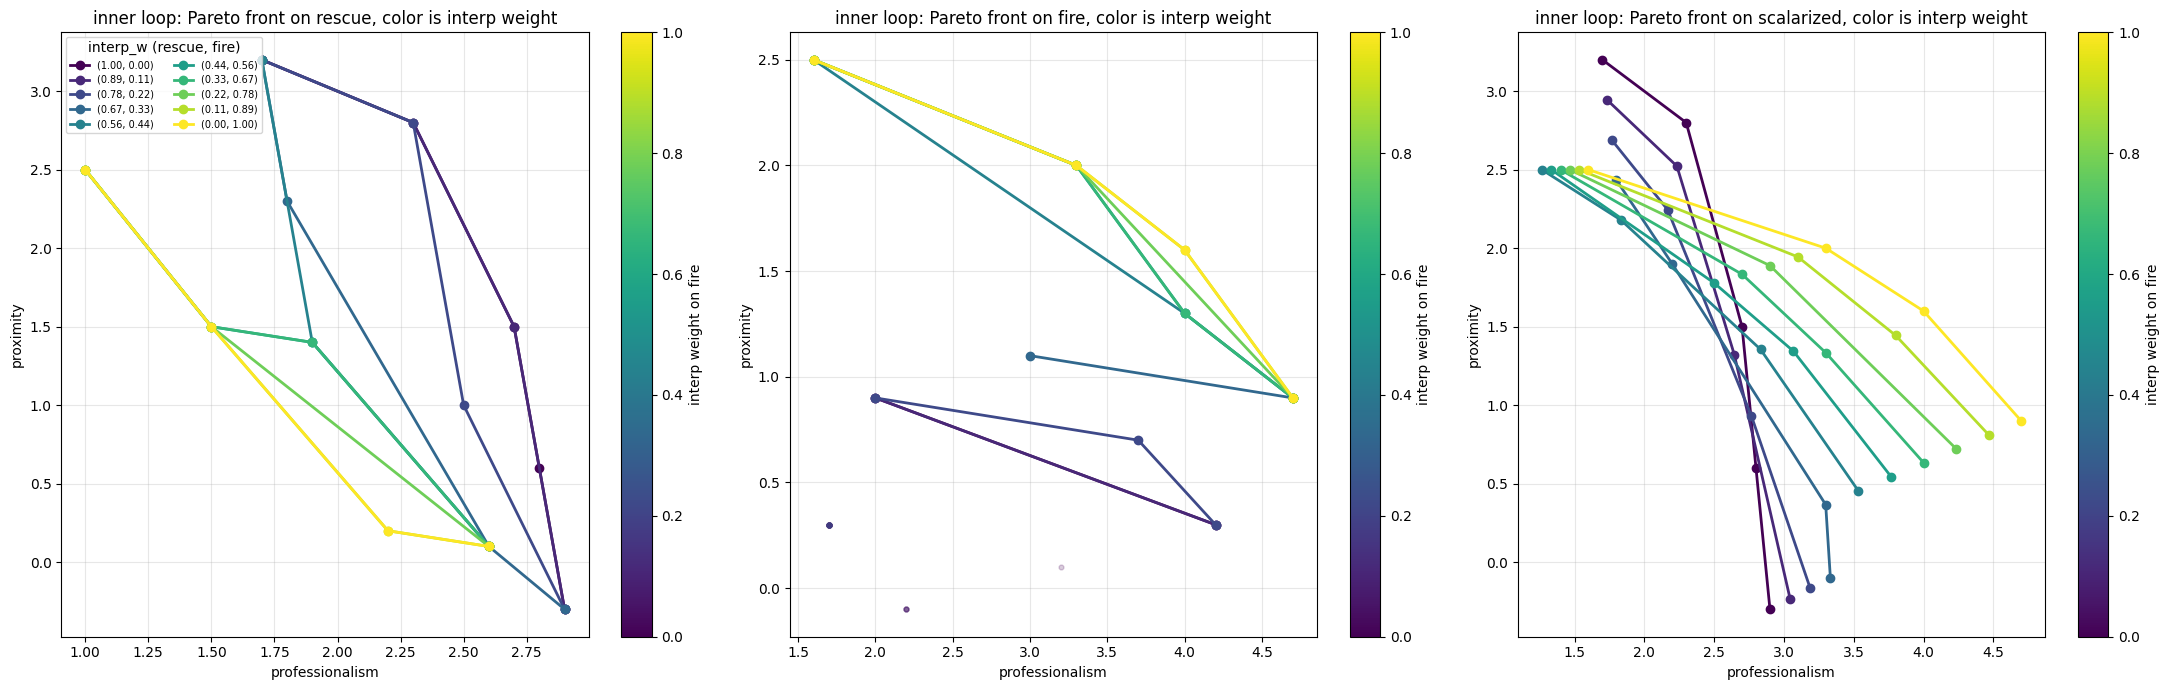

In [ ]:
# ecc-envelope: sweep the interpretation weight (1,0) rescue -> (0,1) fire in n_steps and, for each,
# trace a Pareto front by sweeping the objective weight on the RAW env. One raw rollout per
# (interp_w, objective_w) gives the 4-D return [rescue_pf,px, fire_pf,px], from which all three
# views come with NO extra rollouts:
#   rescue     = cols 0:2
#   fire       = cols 2:4
#   scalarized = interp_w . [rescue, fire]   (same trajectory -> exact)
# Each step's 4-D returns (+ the objective weights) are CACHED to disk and reused if present
# (matched on num_w); pass force=True to recompute.

def interp_weight_front_sweep(label, n_steps=10, num_w=25, episodes=15, save_dir=None, force=False):
    """{interp_w: R4d [num_w, 4]} for an ECC agent, cached per step under <run>/interp_sweep."""
    run_dir = contested_run(label)
    save_dir = save_dir or os.path.join(run_dir, "interp_sweep")
    os.makedirs(save_dir, exist_ok=True)
    steps = [tuple(np.round([1 - t, t], 3)) for t in np.linspace(0, 1, n_steps)]
    path = lambda iw: os.path.join(save_dir, f"eval_returns_raw_iw_{iw[0]:.2f}_{iw[1]:.2f}.npy")

    # reuse cached steps whose saved resolution matches num_w
    out, todo = {}, []
    for iw in steps:
        if not force and os.path.exists(path(iw)):
            R = np.load(path(iw))
            if R.shape[0] == num_w:
                out[iw] = R
                continue
        todo.append(iw)

    if todo:
        cfg = json.load(open(ECC_CONFIGS[label]))
        ec = dict(cfg["env"]); ac = dict(cfg["agent"]); ac["log"] = False
        for k in ("interp_index", "interp_weight_wrapper", "deontological_wrapper", "utilitarian_wrapper"):
            ec.pop(k, None)
        raw = make_env(dict(ec))
        agent = make_agent(env=raw, agent_config=dict(ac))
        agent.load(run_dir + "/model.tar")
        obj_w = np.asarray(equally_spaced_weights(agent.net_reward_dim, num_w), np.float32)
        np.save(os.path.join(save_dir, "obj_weights.npy"), obj_w)
        for iw in todo:
            agent.set_eval_interp_weight(list(iw))
            rows = []
            for w in obj_w:
                rets = []
                for _ep in range(episodes):
                    obs, _ = raw.reset(); done = False
                    ret = np.zeros(raw.unwrapped.reward_space.shape[0])
                    while not done:
                        a = agent.eval(obs, w, np.asarray(iw, np.float32))
                        obs, r, term, trunc, _ = raw.step(int(a)); ret += r; done = term or trunc
                    rets.append(ret)
                rows.append(np.mean(rets, axis=0))
            R = np.asarray(rows, np.float32)                    # [num_w, 4]
            np.save(path(iw), R)
            out[iw] = R
    print(f"{label}: computed {len(todo)}, reused {len(steps) - len(todo)} of {len(steps)} sweeps"
          f" ({save_dir})")
    return {iw: out[iw] for iw in steps}                        # in step order


def _view(R, iw, which):
    """Slice the 4-D raw return into one of the three interpretation views."""
    rescue, fire = R[:, 0:2], R[:, 2:4]
    if which == "rescue":
        return rescue
    if which == "fire":
        return fire
    return np.tensordot(np.asarray(iw, np.float32), np.stack([rescue, fire]), axes=(0, 0))  # scalarized


_label = INNER_LOOP_LABEL
_title = "inner loop"          # display name for the plot titles (ecc-envelope == outer loop)
_sweep = interp_weight_front_sweep(_label, n_steps=10, num_w=25, episodes=15)
_steps = list(_sweep)
_colors = plt.cm.viridis(np.linspace(0, 1, len(_steps)))

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
for ax, which in zip(axes, ("rescue", "fire", "scalarized")):
    for iw, color in zip(_steps, _colors):
        pts = _view(_sweep[iw], iw, which)
        pf = pareto_front(pts)
        ax.scatter(pts[:, 0], pts[:, 1], s=12, alpha=0.2, color=color)
        ax.plot(pf[:, 0], pf[:, 1], marker="o", color=color, lw=2,
                label=f"({iw[0]:.2f}, {iw[1]:.2f})")
    ax.set_xlabel("professionalism")
    ax.set_ylabel("proximity")
    ax.set_title(f"{_title}: Pareto front on {which}, color is interp weight")
    ax.grid(True, alpha=0.3)
    sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(0, 1))
    fig.colorbar(sm, ax=ax, label="interp weight on fire")
axes[0].legend(title="interp_w (rescue, fire)", fontsize=7, ncol=2)
plt.tight_layout()
fig.savefig(os.path.join("figures", f"ff_{_label}_interp_sweep_3views.png"), dpi=150, bbox_inches="tight")
plt.show()

c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:245: UserWarning: WARN: The reward returned by `step()` must be a float, int, np.integer or np.floating, actual type: <class 'numpy.ndarray'>
  logger.warn(


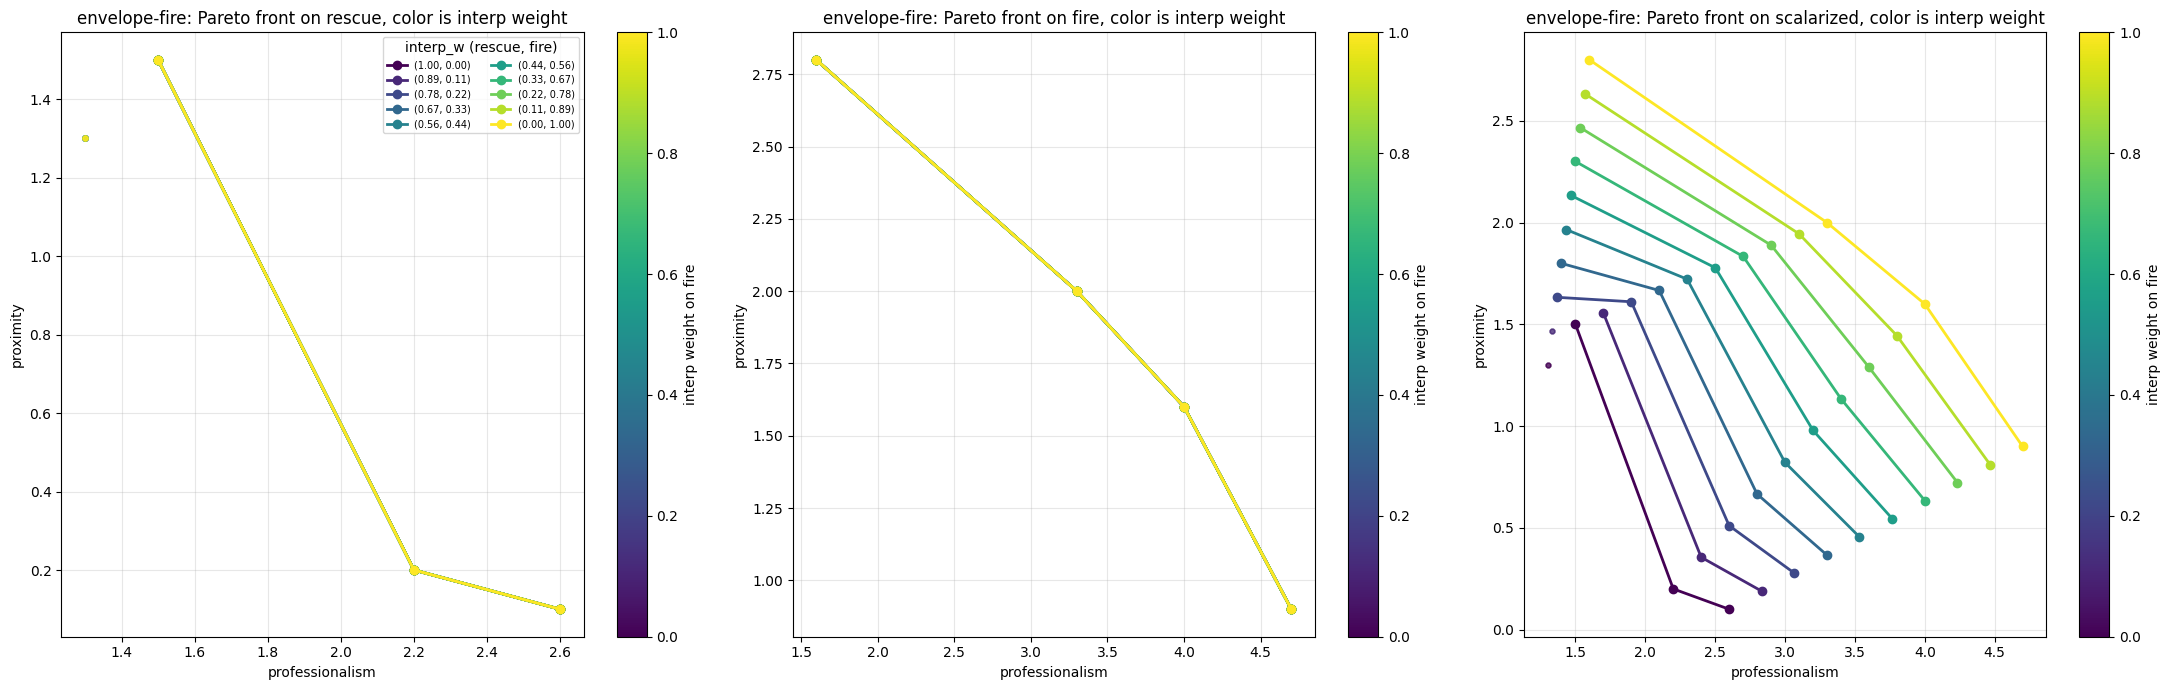

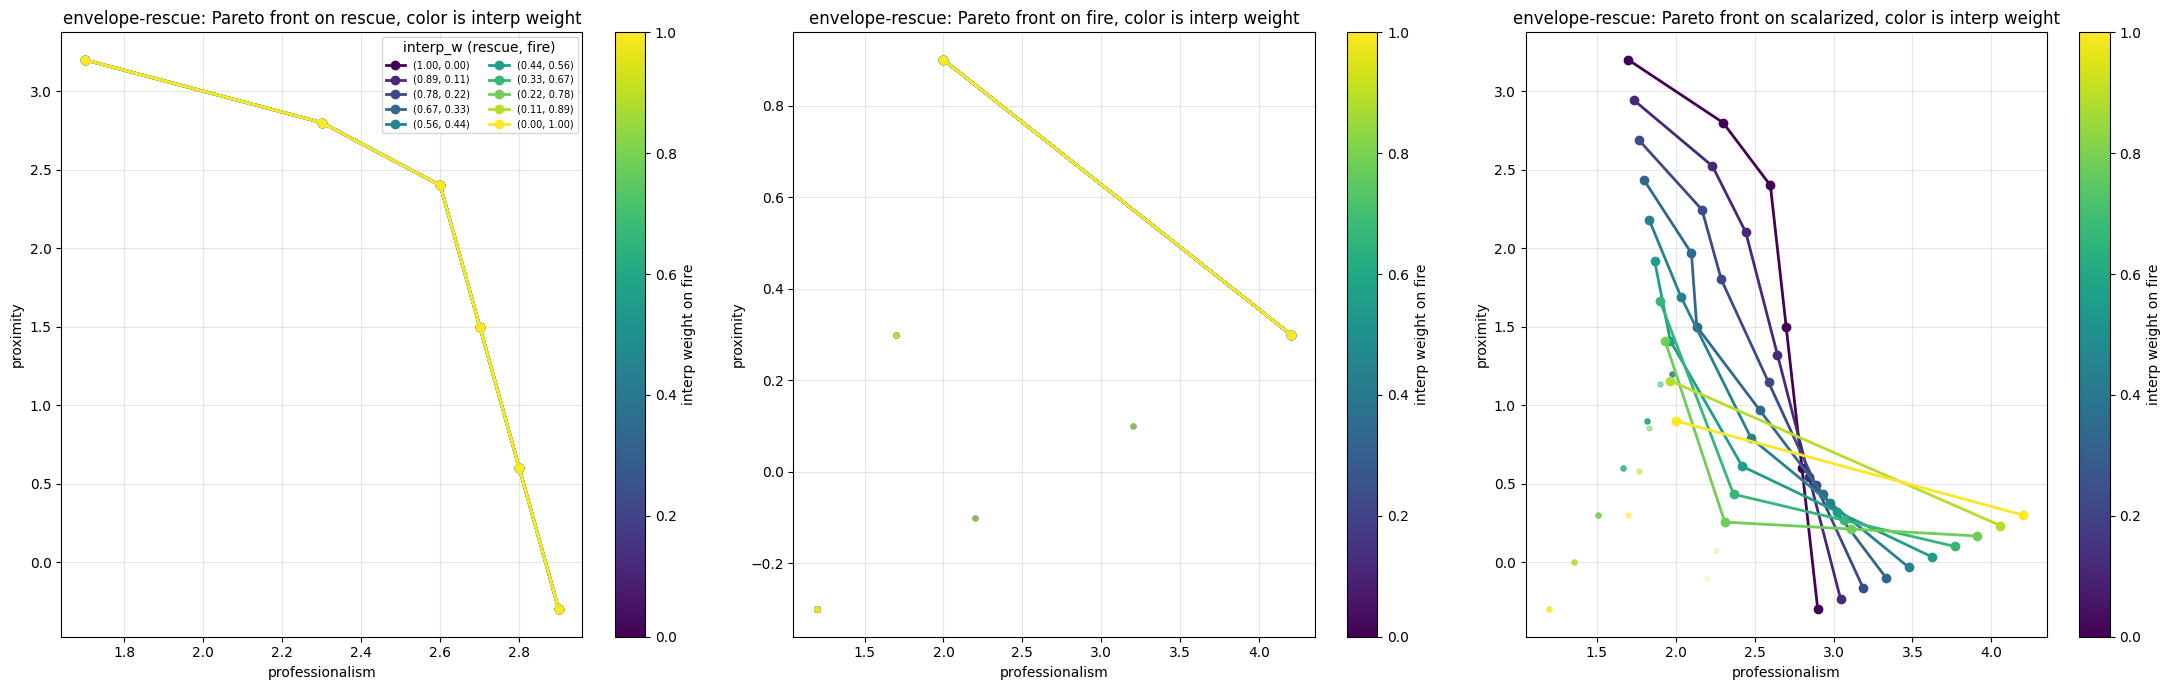

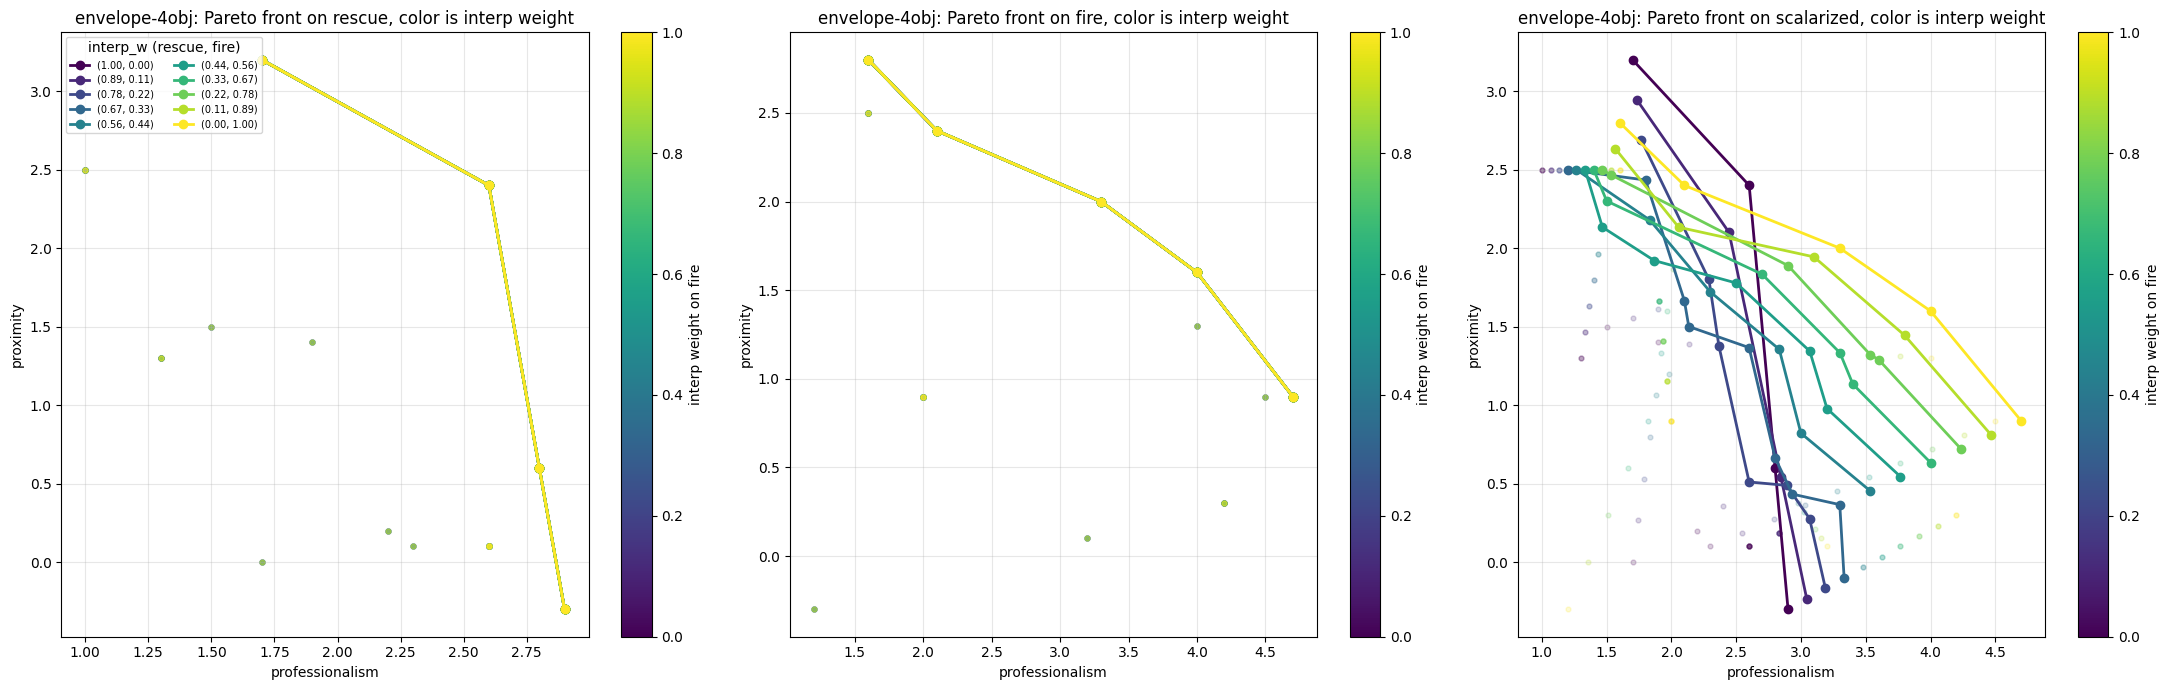

In [ ]:
# Single-policy BASELINES under the SAME 3-view interp-weight sweep as the ecc-envelope figure
# above -- one figure each for envelope-fire, envelope-rescue, envelope-4obj.
#
# These agents do NOT condition on interp_w (their policy is fixed), so the raw 4-D Pareto front
# is computed ONCE by sweeping the OBJECTIVE weight and rolled out on the RAW 4-D env, then reused
# for every interp-weight stop:
#   * rescue view (cols 0:2) and fire view (cols 2:4) are IDENTICAL across interp weights
#     (the policy never changes) -> all colored curves collapse onto ONE front.
#   * scalarized view = interp_w . [rescue, fire] DOES change with interp weight, so those
#     curves fan out exactly like the ecc-envelope figure.
# fire/rescue sweep a 2-D objective weight (net_reward_dim=2); 4obj sweeps a 4-D one.
_BASELINE_MODELS = {   # label -> (run_dir, training config); run dirs from SAVE_CONTESTED_RUNS
    label: (contested_run(label),
            f"scripts/config/firefighters_{label.replace('-', '_')}_contested.json")
    for label in ("envelope-fire", "envelope-rescue", "envelope-4obj")
}


def _baseline_raw_obj_sweep(run_dir, config_path, num_w=25, episodes=15, force=False):
    """R4d [num_w, 4] for a fixed-policy baseline: sweep the objective weight and roll out on the
    RAW 4-D env (cols 0:2 rescue, 2:4 fire). Independent of interp_w -> cached once per run.

    The agent is built on its native/projected env (to match the checkpoint arch), then stepped on
    the raw env with the projection wrappers dropped so we read both interpretations at once.
    """
    save_path = os.path.join(run_dir, f"raw_obj_sweep_{num_w}.npy")
    if not force and os.path.exists(save_path):
        return np.load(save_path)
    cfg = json.load(open(config_path))
    ec = dict(cfg["env"]); ac = dict(cfg["agent"]); ac["log"] = False
    agent = make_agent(env=make_env(dict(ec)), agent_config=dict(ac))   # projected/native -> checkpoint arch
    agent.load(run_dir.rstrip("/\\") + "/model.tar")
    raw_ec = dict(ec)
    for k in ("interp_index", "interp_weight_wrapper", "deontological_wrapper", "utilitarian_wrapper"):
        raw_ec.pop(k, None)
    raw = make_env(raw_ec)                                              # raw 4-D reward
    obj_w = np.asarray(equally_spaced_weights(agent.reward_dim, num_w), np.float32)
    rows = []
    for w in obj_w:
        rets = []
        for _ep in range(episodes):
            obs, _ = raw.reset(); done = False
            ret = np.zeros(raw.unwrapped.reward_space.shape[0])
            while not done:
                a = agent.eval(obs, w)                                  # baseline: no interp_w
                obs, r, term, trunc, _ = raw.step(int(a)); ret += r; done = term or trunc
            rets.append(ret)
        rows.append(np.mean(rets, axis=0))
    R = np.asarray(rows, np.float32)                                    # [num_w, 4]
    np.save(save_path, R)
    return R


def _baseline_view(R, iw, which):
    """Slice the 4-D raw return into one of the three interpretation views (see ecc-envelope cell)."""
    rescue, fire = R[:, 0:2], R[:, 2:4]
    if which == "rescue":
        return rescue
    if which == "fire":
        return fire
    return np.tensordot(np.asarray(iw, np.float32), np.stack([rescue, fire]), axes=(0, 0))  # scalarized


def plot_baseline_interp_sweep_3views(label, n_steps=10, num_w=25, episodes=15, force=False):
    run_dir, config_path = _BASELINE_MODELS[label]
    R = _baseline_raw_obj_sweep(run_dir, config_path, num_w=num_w, episodes=episodes, force=force)
    steps = [tuple(np.round([1 - t, t], 3)) for t in np.linspace(0, 1, n_steps)]
    colors = plt.cm.viridis(np.linspace(0, 1, len(steps)))

    fig, axes = plt.subplots(1, 3, figsize=(22, 7))
    for ax, which in zip(axes, ("rescue", "fire", "scalarized")):
        for iw, color in zip(steps, colors):
            pts = _baseline_view(R, iw, which)
            pf = pareto_front(pts)
            ax.scatter(pts[:, 0], pts[:, 1], s=12, alpha=0.2, color=color)
            ax.plot(pf[:, 0], pf[:, 1], marker="o", color=color, lw=2,
                    label=f"({iw[0]:.2f}, {iw[1]:.2f})")
        ax.set_xlabel("professionalism")
        ax.set_ylabel("proximity")
        ax.set_title(f"{label}: Pareto front on {which}, color is interp weight")
        ax.grid(True, alpha=0.3)
        sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(0, 1))
        fig.colorbar(sm, ax=ax, label="interp weight on fire")
    axes[0].legend(title="interp_w (rescue, fire)", fontsize=7, ncol=2)
    plt.tight_layout()
    fig.savefig(os.path.join("figures", f"ff_{label}_interp_sweep_3views.png"), dpi=150, bbox_inches="tight")
    plt.show()


for _lbl in ("envelope-fire", "envelope-rescue", "envelope-4obj"):
    plot_baseline_interp_sweep_3views(_lbl)


ecc-gpipd: computed 0, reused 5 of 5 sweeps (results/firefighters-mo-contested-v0\ecc_gpi_pd__7500__qbj8fywu\interp_sweep)
ecc-envelope: computed 0, reused 5 of 5 sweeps (results/firefighters-mo-contested-v0\ecc_envelope__20000__x7r9beyh\interp_sweep)


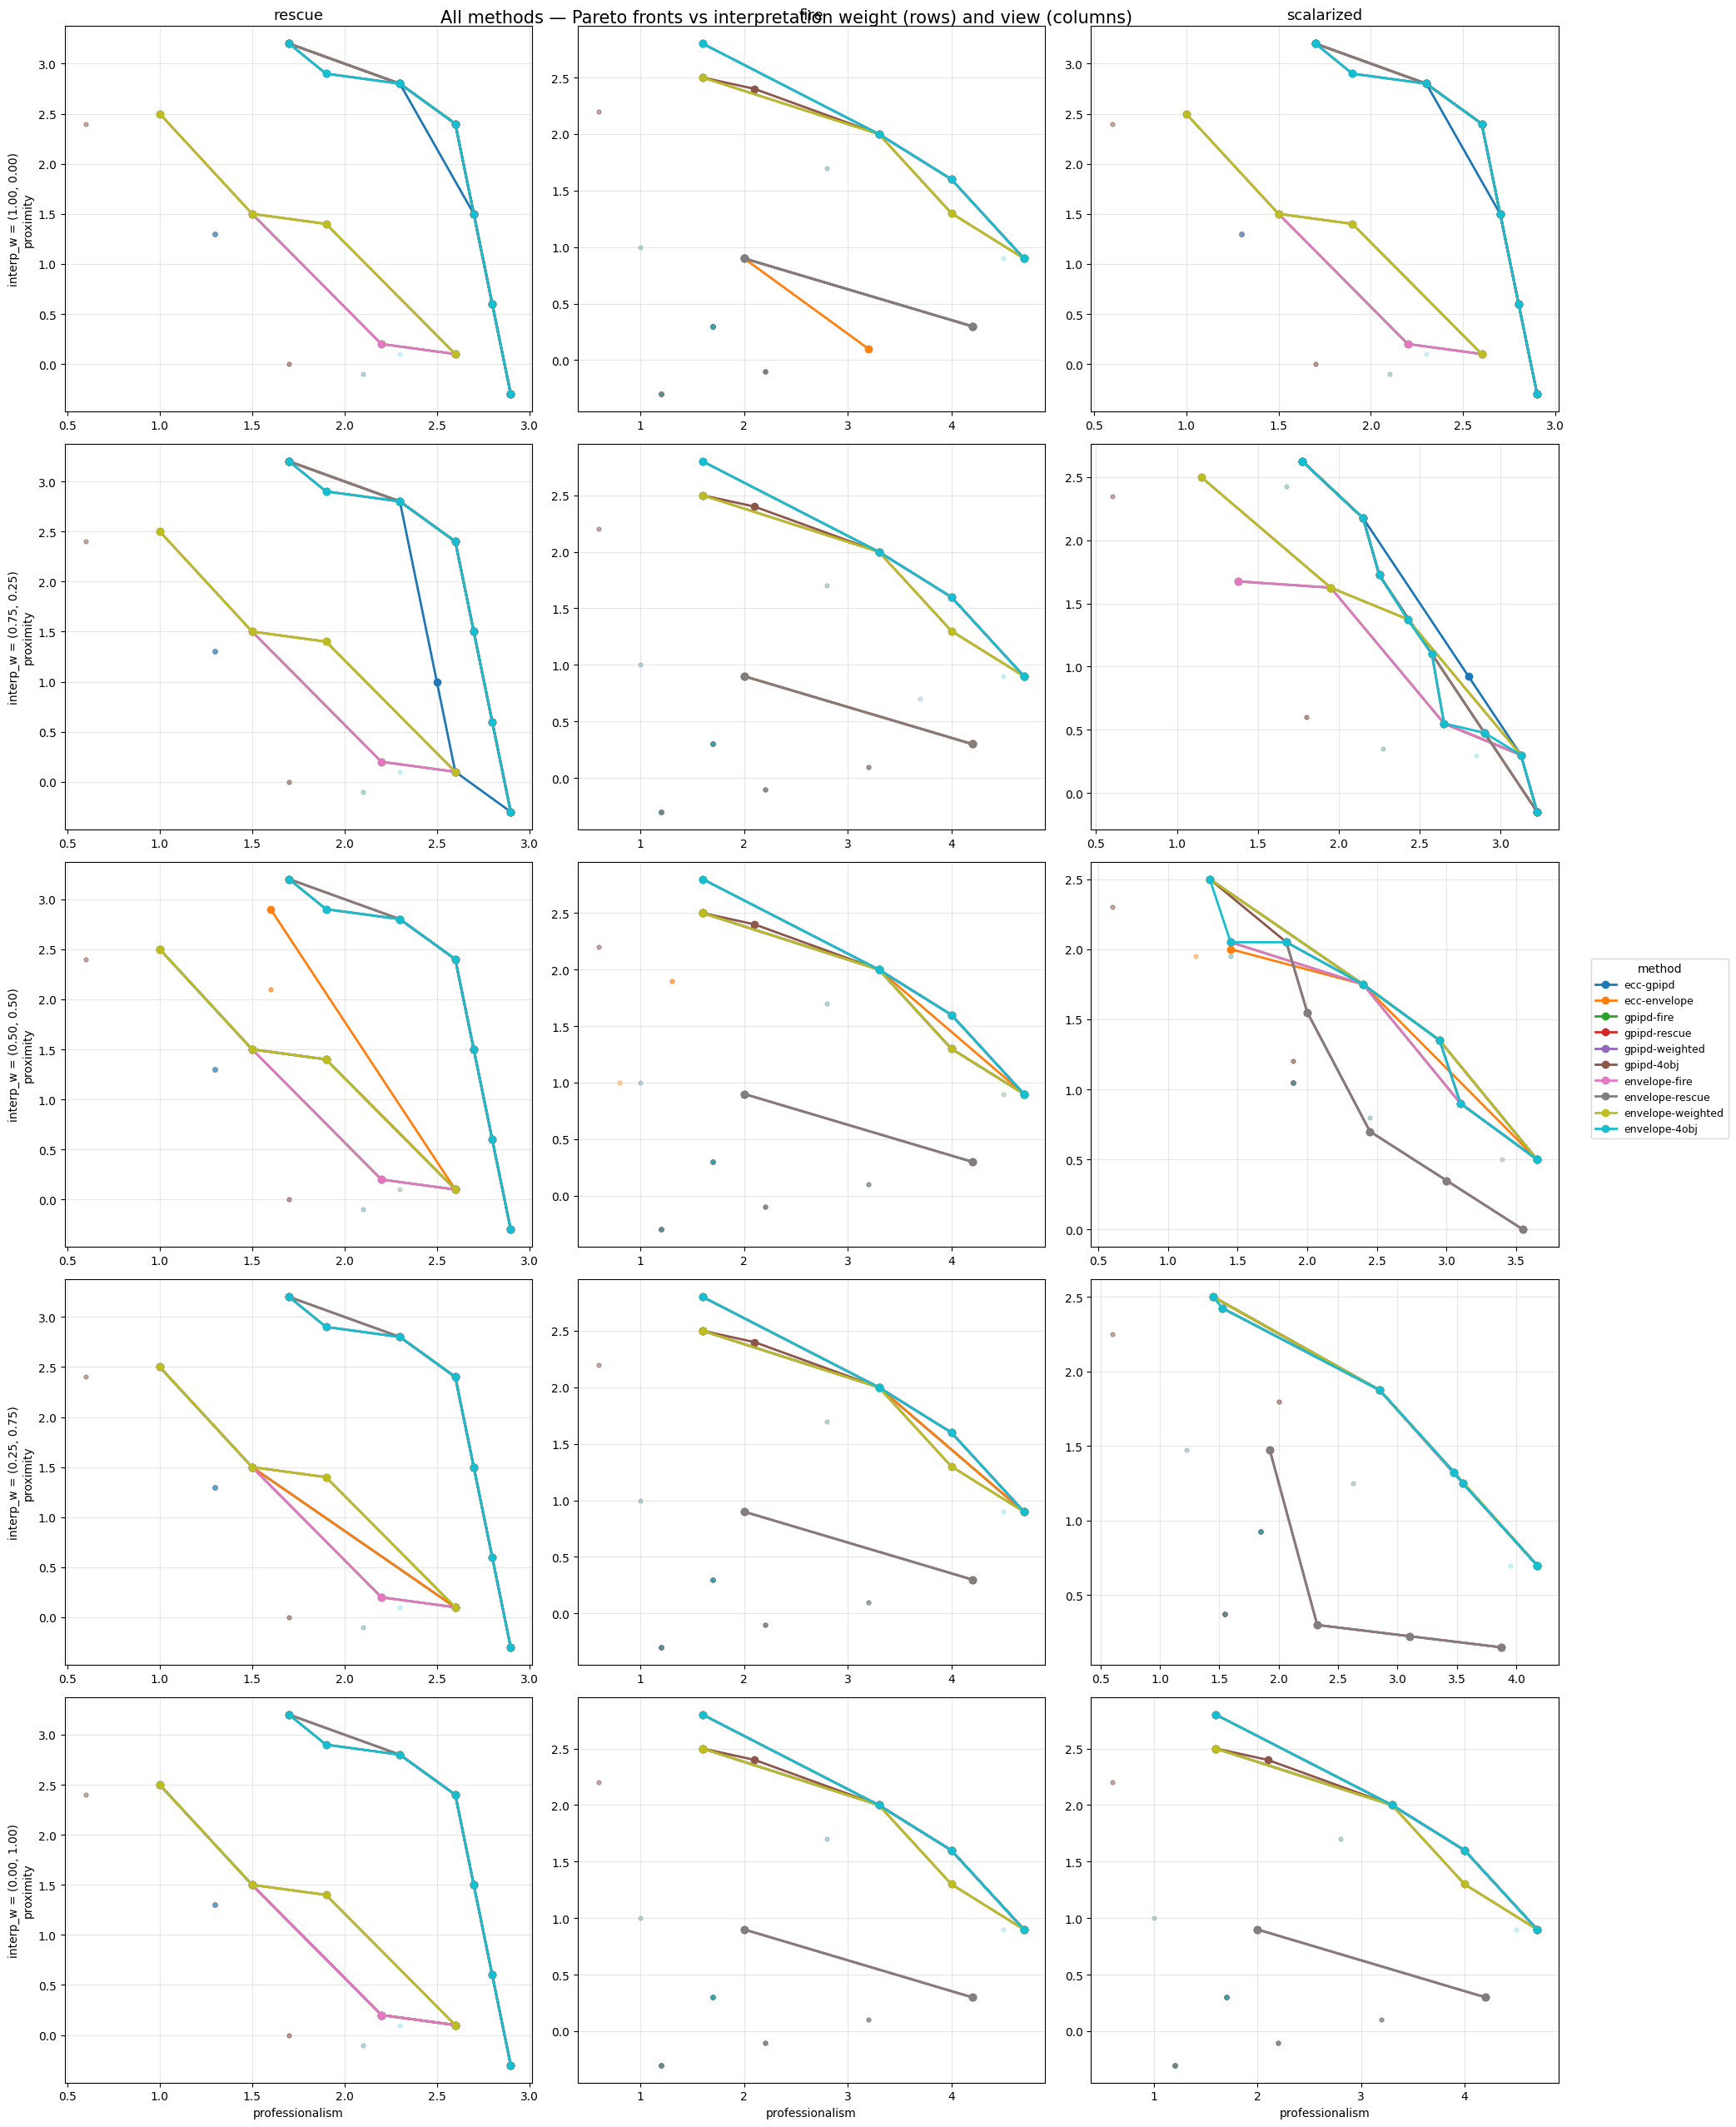

In [55]:
# All methods, three views (rescue | fire | scalarized) as COLUMNS, one ROW per interpretation-
# weight stop (1,0) rescue -> (0,1) fire, combined into a single image. Colored by METHOD.
#   * baselines: no interp_w input -> rescue/fire fronts are FIXED across rows (their existing
#     per-interp eval files); only the scalarized column = interp_w . [rescue, fire] shifts.
#   * ECC agents: conditioned on interp_w -> all three columns shift (raw 4-D sweep per stop,
#     cached by interp_weight_front_sweep for reuse).
N_STOPS = 5
_stops = [tuple(np.round([1 - t, t], 3)) for t in np.linspace(0, 1, N_STOPS)]

# baselines: fixed (rescue, fire) fronts loaded once
_base = {}
for label in SAVE_CONTESTED_RUNS:
    if label in ECC_CONFIGS:
        continue
    rd = contested_run(label)
    _base[label] = (np.load(os.path.join(rd, "eval_returns_rescue_minded.npy")),
                    np.load(os.path.join(rd, "eval_returns_fire_minded.npy")))

# ECC agents: raw 4-D returns per stop -> {label: {interp_w: R4d}} (cached to disk)
_ecc = {label: interp_weight_front_sweep(label, n_steps=N_STOPS, num_w=25, episodes=15)
        for label in ECC_CONFIGS}


def _method_views(label, iw):
    """(rescue_pts, fire_pts, scalarized_pts) for one method at interpretation weight iw."""
    w = np.asarray(iw, np.float32)
    if label in ECC_CONFIGS:
        R = _ecc[label][iw]
        rescue, fire = R[:, 0:2], R[:, 2:4]
    else:
        rescue, fire = _base[label]
    scal = np.tensordot(w, np.stack([rescue, fire]), axes=(0, 0))
    return rescue, fire, scal


_views = ("rescue", "fire", "scalarized")
fig, axes = plt.subplots(N_STOPS, 3, figsize=(19, 5.2 * N_STOPS), squeeze=False)
for i, iw in enumerate(_stops):
    for j, which in enumerate(_views):
        ax = axes[i][j]
        for label in SAVE_CONTESTED_RUNS:
            pts = _method_views(label, iw)[j]
            pf = pareto_front(pts)
            c = METHOD_COLORS[label]
            ax.scatter(pts[:, 0], pts[:, 1], s=12, alpha=0.2, color=c)
            ax.plot(pf[:, 0], pf[:, 1], marker="o", color=c, lw=2, label=label)
        ax.grid(True, alpha=0.3)
        if i == 0:
            ax.set_title(which, fontsize=13)
        if i == N_STOPS - 1:
            ax.set_xlabel("professionalism")
        if j == 0:
            ax.set_ylabel(f"interp_w = ({iw[0]:.2f}, {iw[1]:.2f})\nproximity")

# one shared legend (methods + colors are identical across all panels)
handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.005, 0.5),
           fontsize=9, title="method")
fig.suptitle("All methods — Pareto fronts vs interpretation weight (rows) and view (columns)",
             fontsize=15)
fig.tight_layout()
fig.savefig(os.path.join("figures", "ff_allmethods_3views_grid.png"), dpi=140, bbox_inches="tight")
plt.show()

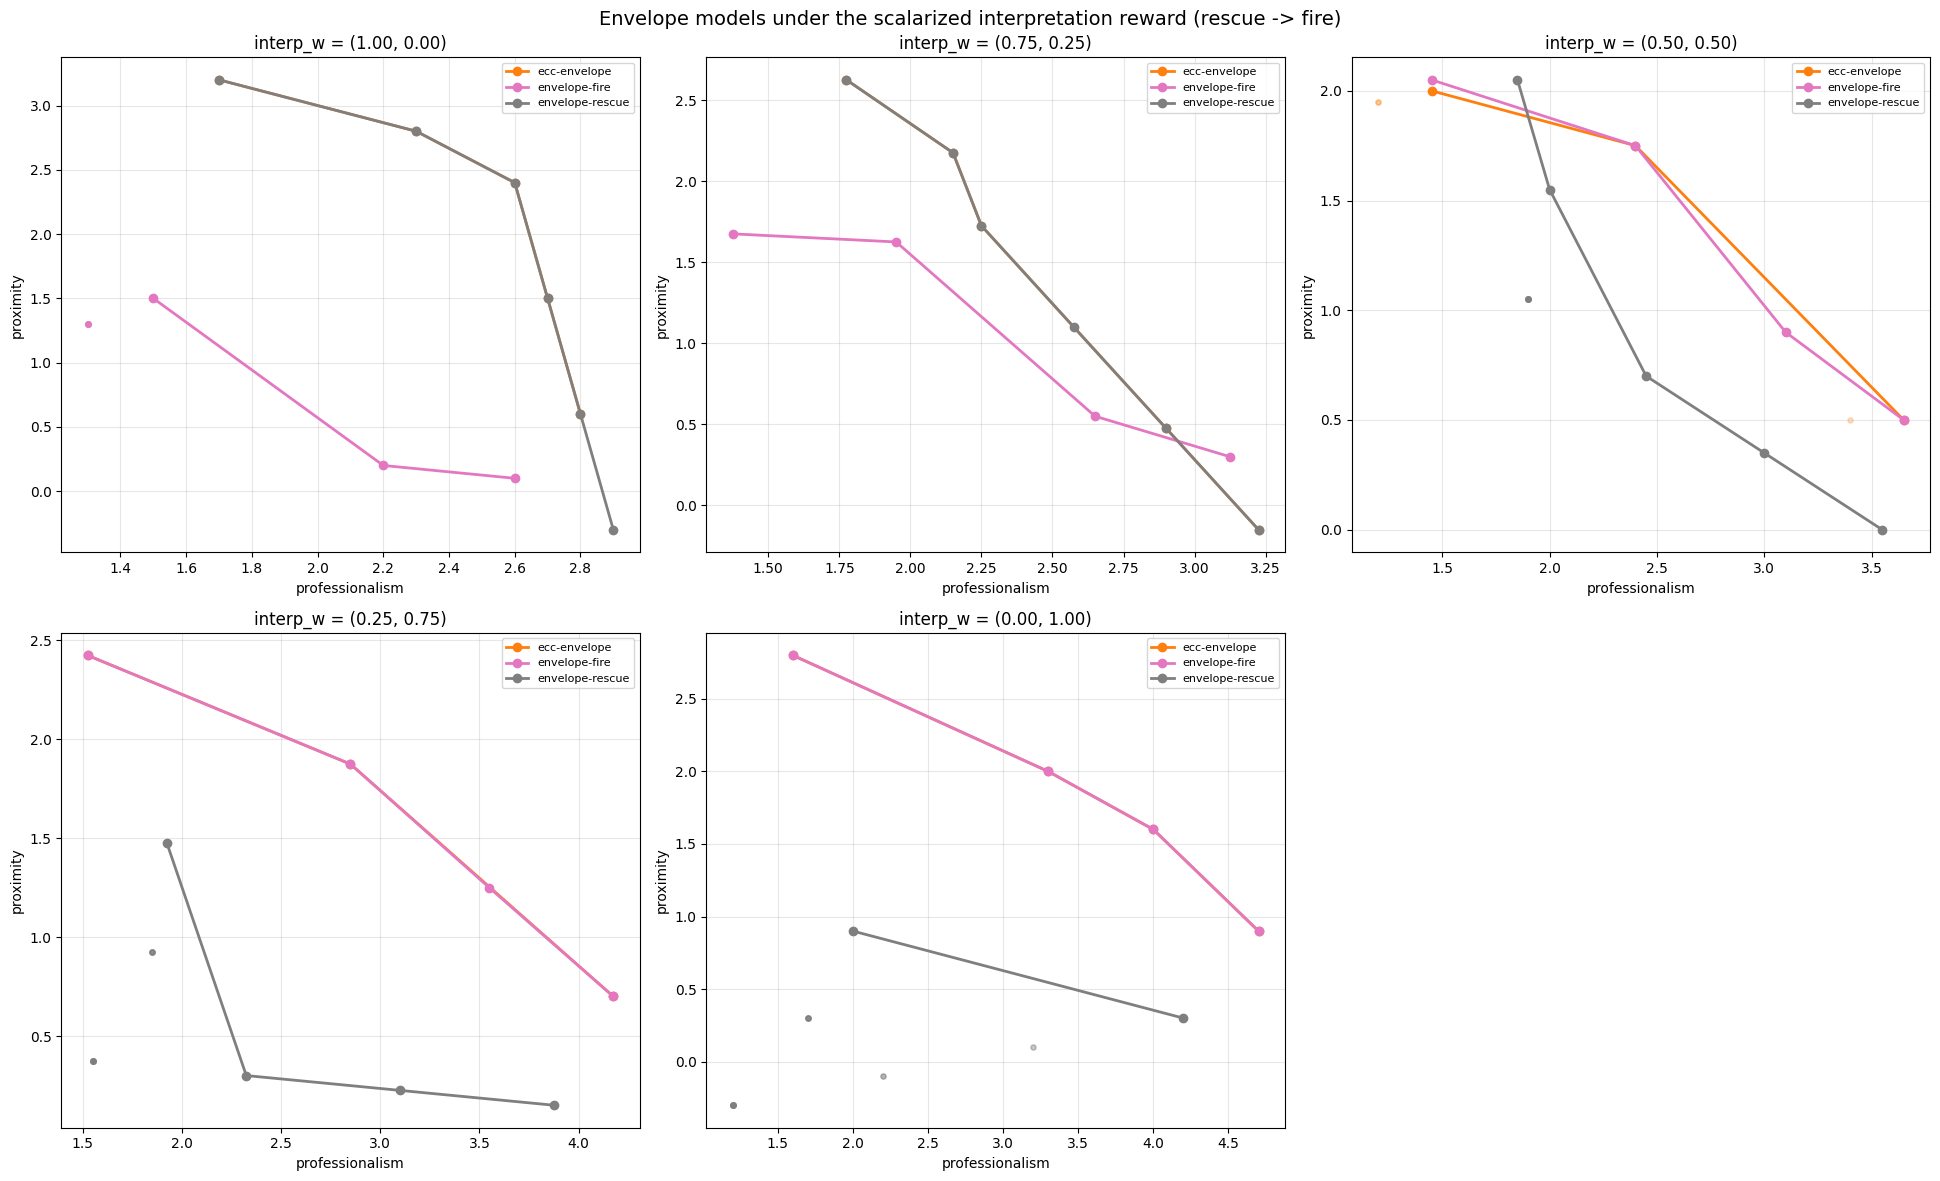

In [ ]:
# Three envelope models -- ecc-envelope (outer loop), envelope-fire, envelope-rescue -- evaluated as
# the interpretation weight slides (1,0) rescue -> (0,1) fire. ONE subplot per weight; each curve is
# that model's Pareto front (objective-weight sweep) measured under the scalarized interpretation
# reward  interp_w . [rescue, fire]  (so (1,0)=pure rescue, (0,1)=pure fire, in between a blend).
#
# Only ecc-envelope is re-rolled per weight (it conditions on interp_w). The two single-policy
# baselines take NO interp_w -- their policy is fixed -- so their scalarized front is just
# interp_w . [their fixed rescue, fire] eval files. (Rolling a baseline out here would also crash:
# it was trained on the 2-D projected env, not the raw 4-D reward this sweep uses.)
#
# Run dirs come from SAVE_CONTESTED_RUNS; only the baselines need no config here.
_MODELS = {   # label -> (kind, run_dir, config_or_None)
    OUTER_LOOP_LABEL:    ("ecc",      contested_run(OUTER_LOOP_LABEL),
                        "scripts/config/firefighters_ecc_envelope_contested.json"),
    "envelope-fire":   ("baseline", contested_run("envelope-fire"), None),
    "envelope-rescue": ("baseline", contested_run("envelope-rescue"), None),
}
_n = 5
_wstops = [tuple(np.round([1 - t, t], 3)) for t in np.linspace(0, 1, _n)]
_num_w, _episodes = 25, 15


def _ecc_raw_sweep(run_dir, config_path, stops, num_w=_num_w, episodes=_episodes, force=False):
    """{iw: R4d [num_w, 4]} for an ECC agent, cached under <run>/interp_sweep."""
    save_dir = os.path.join(run_dir, "interp_sweep"); os.makedirs(save_dir, exist_ok=True)
    path = lambda iw: os.path.join(save_dir, f"eval_returns_raw_iw_{iw[0]:.2f}_{iw[1]:.2f}.npy")
    out, todo = {}, []
    for iw in stops:
        if not force and os.path.exists(path(iw)):
            R = np.load(path(iw))
            if R.shape[0] == num_w:
                out[iw] = R
                continue
        todo.append(iw)
    if todo:
        cfg = json.load(open(config_path)); ec = dict(cfg["env"]); ac = dict(cfg["agent"]); ac["log"] = False
        for k in ("interp_index", "interp_weight_wrapper", "deontological_wrapper", "utilitarian_wrapper"):
            ec.pop(k, None)
        raw = make_env(dict(ec)); agent = make_agent(env=raw, agent_config=dict(ac))
        agent.load(run_dir + "/model.tar")
        obj_w = np.asarray(equally_spaced_weights(agent.net_reward_dim, num_w), np.float32)
        for iw in todo:
            agent.set_eval_interp_weight(list(iw))
            rows = []
            for w in obj_w:
                rets = []
                for _ep in range(episodes):
                    obs, _ = raw.reset(); done = False
                    ret = np.zeros(raw.unwrapped.reward_space.shape[0])
                    while not done:
                        a = agent.eval(obs, w, np.asarray(iw, np.float32))
                        obs, r, term, trunc, _ = raw.step(int(a)); ret += r; done = term or trunc
                    rets.append(ret)
                rows.append(np.mean(rets, axis=0))
            R = np.asarray(rows, np.float32); np.save(path(iw), R); out[iw] = R
    return {iw: out[iw] for iw in stops}


# ecc-envelope: raw 4-D sweep (cached); baselines: fixed rescue/fire fronts loaded once
_ecc_env_sweep = _ecc_raw_sweep(_MODELS[OUTER_LOOP_LABEL][1], _MODELS[OUTER_LOOP_LABEL][2], _wstops)
_base_ff = {lbl: (np.load(f"{d}/eval_returns_rescue_minded.npy"),
                  np.load(f"{d}/eval_returns_fire_minded.npy"))
            for lbl, (kind, d, _) in _MODELS.items() if kind == "baseline"}


def _model_scal_front(label, iw):
    """Model's front measured under the scalarized reward interp_w . [rescue, fire]."""
    w = np.asarray(iw, np.float32)
    if _MODELS[label][0] == "ecc":
        R = _ecc_env_sweep[iw]
        rescue, fire = R[:, 0:2], R[:, 2:4]
    else:
        rescue, fire = _base_ff[label]
    return np.tensordot(w, np.stack([rescue, fire]), axes=(0, 0))


ncols = min(_n, 3); nrows = int(np.ceil(_n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6.5 * ncols, 6 * nrows), squeeze=False)
axf = axes.ravel()
for k, iw in enumerate(_wstops):
    ax = axf[k]
    for label in _MODELS:
        pts = _model_scal_front(label, iw)
        pf = pareto_front(pts)
        c = METHOD_COLORS[label]
        ax.scatter(pts[:, 0], pts[:, 1], s=14, alpha=0.25, color=c)
        ax.plot(pf[:, 0], pf[:, 1], marker="o", color=c, lw=2, label=label)
    ax.set_title(f"interp_w = ({iw[0]:.2f}, {iw[1]:.2f})")
    ax.set_xlabel("professionalism")
    ax.set_ylabel("proximity")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
for k in range(_n, len(axf)):
    axf[k].axis("off")
fig.suptitle("Envelope models under the scalarized interpretation reward (rescue -> fire)",
             fontsize=14)
fig.tight_layout()
fig.savefig(os.path.join("figures", "ff_envelope3_interp_stops.png"), dpi=140, bbox_inches="tight")
plt.show()

results/firefighters-mo-contested-v0\ecc_envelope__40000__d0g6brv2: computed 0, reused 10 of 10 sweeps
results/firefighters-mo-contested-v0\ecc_gpi_pd__30000__govvtrva: computed 0, reused 10 of 10 sweeps
results/firefighters-mo-contested-v0\gpi_pd__30000__fw38o6ug: computed 0, reused 10 of 10 sweeps
results/firefighters-mo-contested-v0\gpi_pd__5000__850yazz0: computed 0, reused 1 of 1 sweeps (fixed policy: tiled over all stops)
results/firefighters-mo-contested-v0\gpi_pd__5000__dzks0la5: computed 0, reused 1 of 1 sweeps (fixed policy: tiled over all stops)


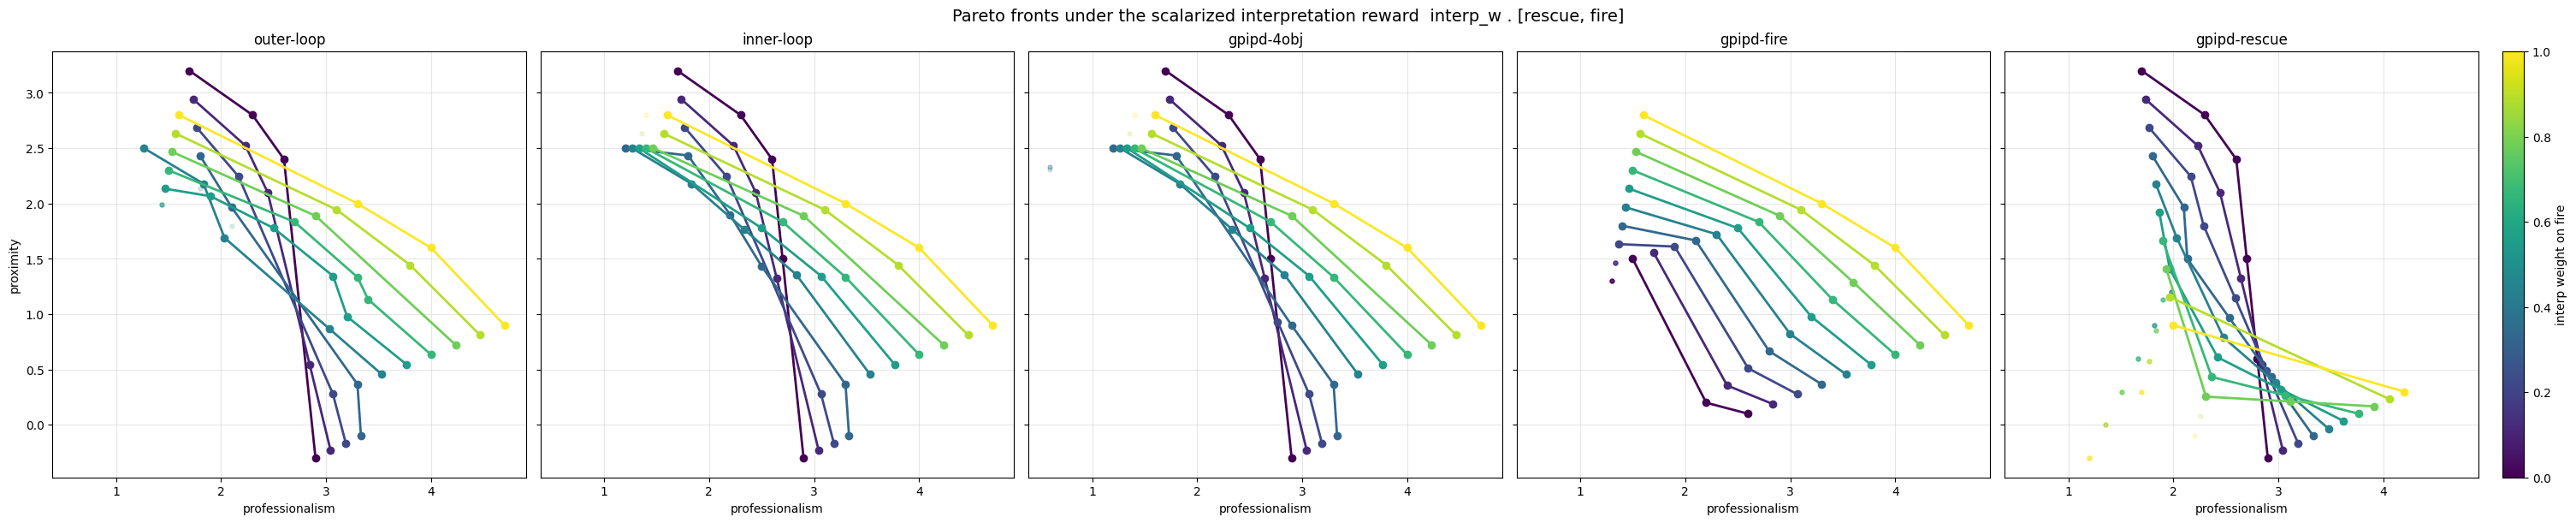

In [28]:

_stops = [tuple(np.round([1 - t, t], 3)) for t in np.linspace(0, 1, _ROW_STOPS)]
_colors = plt.cm.viridis(np.linspace(0, 1, len(_stops)))
_sweeps = {label: _model_raw_sweep(kind, cfgp, rd, _stops)
           for label, (kind, cfgp, rd) in _ROW_MODELS.items()}

fig, axes = plt.subplots(1, len(_ROW_MODELS), figsize=(6 * len(_ROW_MODELS), 6),
                         sharex=True, sharey=True, layout="constrained")
for ax, (label, sweep) in zip(axes, _sweeps.items()):
    for iw, color in zip(_stops, _colors):
        pts = _scal_view(sweep[iw], iw)
        pf = pareto_front(pts)
        ax.scatter(pts[:, 0], pts[:, 1], s=12, alpha=0.2, color=color)
        ax.plot(pf[:, 0], pf[:, 1], marker="o", color=color, lw=2)
    ax.set_xlabel("professionalism")
    ax.set_title(label)
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("proximity")
# no per-curve legend: the shared colorbar already encodes the (evenly spaced) interp weights
sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(0, 1))
fig.colorbar(sm, ax=axes.tolist(), label="interp weight on fire", fraction=0.02, pad=0.01)
fig.suptitle("Pareto fronts under the scalarized interpretation reward  interp_w . [rescue, fire]",
             fontsize=14)
fig.savefig(os.path.join("figures", "ff_gpipd4_interp_sweep_scalarized_row.png"),
            dpi=150, bbox_inches="tight")
plt.show()


results/firefighters-mo-contested-v0\ecc_gpi_pd__30000__govvtrva: computed 0, reused 5 of 5 sweeps
results/firefighters-mo-contested-v0\ecc_envelope__40000__d0g6brv2: computed 0, reused 5 of 5 sweeps
results/firefighters-mo-contested-v0\gpi_pd__30000__fw38o6ug: computed 0, reused 5 of 5 sweeps


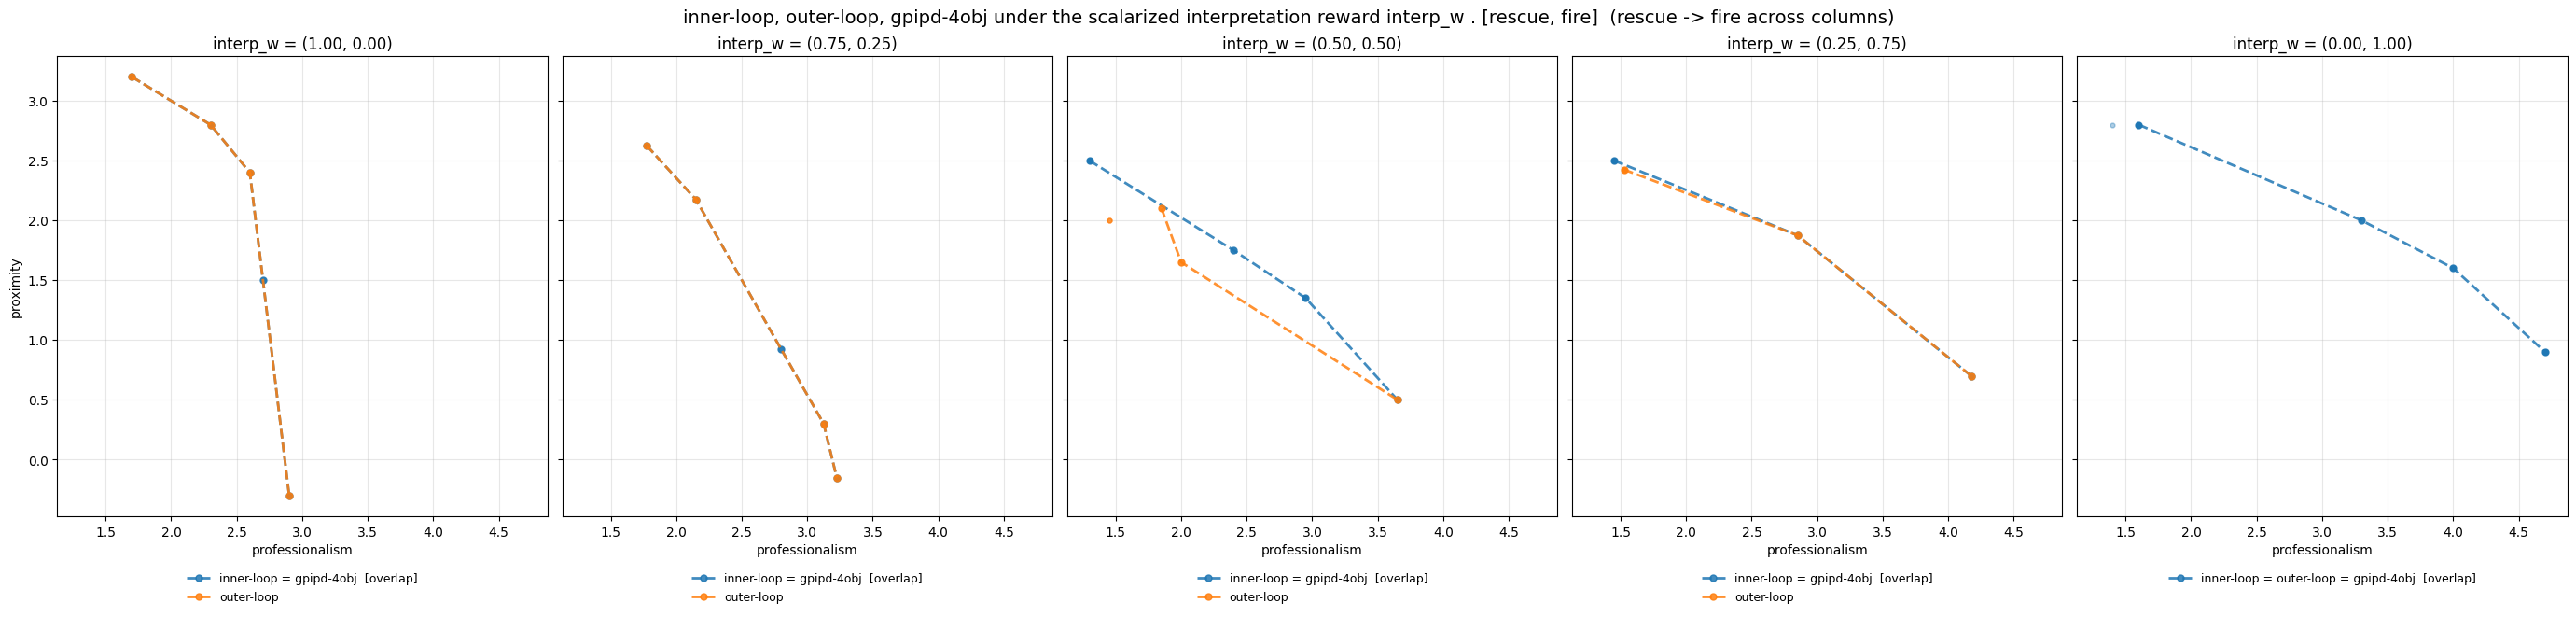

In [29]:
# ALL contested methods under the SCALARIZED interpretation reward, in ONE ROW: each COLUMN is one
# interpretation weight, sliding (1, 0) rescue -> (0, 1) fire. Every curve is a method's Pareto
# front from an objective-weight sweep, measured under  interp_w . [rescue, fire]; the color is the
# METHOD (METHOD_COLORS). This is the "scalarized" panel of the 3-view sweep figures transposed:
# the view is fixed, the interp weight runs across columns, and all methods are overlaid so the
# panels show how the RANKING between methods moves as the interpretation weight slides.
#
# Reuses _model_raw_sweep / _scal_view from the gpipd row cell above. Each method's kind decides
# how it is conditioned (see that cell for the details):
#   * ecc-*      -> re-rolled at every interp weight (agent.eval(obs, w, interp_w))
#   * *-4obj     -> no interp_w input, but it folds into their 4-D objective weight [iw0*w, iw1*w],
#                   so they are re-rolled too (the fair, adaptive reading of a flat 4-obj agent)
#   * everything else (fire / rescue / weighted) -> fixed policy, ONE sweep reused at every stop;
#                   only its scalarized view rotates with interp_w.
_ALL_STOPS_N, _ALL_NUMW, _ALL_EP = 5, 25, 15

# Methods to overlay -- comment a label out to drop it (list order = draw order = legend order).
# Keep _ALL_FIG in sync so a subset does not overwrite the all-methods figure.
_ALL_LABELS = [
    INNER_LOOP_LABEL,
    OUTER_LOOP_LABEL,
    # "ecc-envelope",
    # "ecc-envelope-3net",
    # "ecc-envelope-3net-old",
    # "gpipd-fire",
    # "gpipd-rescue",
    # "gpipd-weighted",
    "gpipd-4obj",
    # "envelope-fire",
    # "envelope-rescue",
    # "envelope-weighted",
    # "envelope-4obj",
]
_ALL_FIG = "ff_mimorl_interp_comparison.png"


def _is_ecc(label):
    """True for any interpretation-conditioned (ECC) method.

    Label-based, so a new ecc-* run must be caught by the PREFIX, not by an explicit
    name: matching only INNER/OUTER_LOOP_LABEL silently routed "ecc-envelope-3net"
    down the baseline path, which evaluates one fixed policy at _eval_interp_w
    (= interp_weight = 0.5/0.5) and reuses it at every stop.
    """
    return label in (INNER_LOOP_LABEL, OUTER_LOOP_LABEL) or label.startswith("ecc-")


def _kind_for(label):
    """Conditioning kind from the method label (see _model_raw_sweep)."""
    if _is_ecc(label):
        return "ecc"
    if label.endswith("-4obj"):
        return "4obj"
    return "baseline"


_all_stops = [tuple(np.round([1 - t, t], 3)) for t in np.linspace(0, 1, _ALL_STOPS_N)]
_all_sweeps = {
    label: _model_raw_sweep(_kind_for(label), _config_for(label), contested_run(label),
                            _all_stops, num_w=_ALL_NUMW, episodes=_ALL_EP)
    for label in _ALL_LABELS
}

# with 10 methods overlaid the fronts overlap heavily, so cycle the linestyle too: a method
# hidden under a later one still shows through as a dashed/dotted trace
_LS = {INNER_LOOP_LABEL: "--", OUTER_LOOP_LABEL: "--", "gpipd-fire": "-", "gpipd-rescue": "-"}

# fronts closer than this (as a fraction of the panel's data range, per axis) count as coincident:
# they are drawn once and labelled together with an [overlap] tag, as in plot_pareto_fronts
_ALL_OVERLAP_TOL = 0.02

# ecc-* fronts are drawn ON TOP of every baseline regardless of list/draw order (their clouds sit
# at z-1, i.e. still under their own front but above the baselines')
_ECC_Z, _BASE_Z = 6, 3


def _group_fronts(fronts, tol):
    """Greedily group labels whose Pareto fronts coincide.

    fronts : {label: pf}, tol : per-axis absolute tolerance. Two fronts coincide when they have
    the same number of points and every point agrees within `tol`; a one-element group means the
    method's front is on its own. Returns [[label, ...], ...] in first-seen (= draw) order.
    """
    groups = []
    for label, pf in fronts.items():
        for g in groups:
            ref = fronts[g[0]]
            if ref.shape == pf.shape and np.all(np.abs(ref - pf) <= tol):
                g.append(label)
                break
        else:
            groups.append([label])
    return groups


fig, axes = plt.subplots(1, _ALL_STOPS_N, figsize=(5.5 * _ALL_STOPS_N, 6.5),
                         sharex=True, sharey=True, layout="constrained")
for ax, iw in zip(axes, _all_stops):
    pts_by = {label: _scal_view(_all_sweeps[label][iw], iw) for label in _ALL_LABELS}
    pfs = {label: pareto_front(pts) for label, pts in pts_by.items()}
    span = np.ptp(np.vstack(list(pts_by.values())), axis=0)
    tol = _ALL_OVERLAP_TOL * np.where(span > 0, span, 1.0)

    # overlaps are per panel (they can appear at one interp weight and not the next), so every
    # panel gets its OWN legend below it -- a shared figure legend cannot say which panel coincided
    for k, group in enumerate(_group_fronts(pfs, tol)):
        # the head's color/linestyle is what actually gets drawn for the group, so let an ecc-*
        # member lead it; its front is also raised above the baselines' via zorder
        head = next((l for l in group if _is_ecc(l)), group[0])
        c, z = METHOD_COLORS.get(head, "black"), _ECC_Z if _is_ecc(head) else _BASE_Z
        for label in group:  # dominated clouds can differ even when the fronts coincide
            pts = pts_by[label]
            ax.scatter(pts[:, 0], pts[:, 1], s=12, alpha=0.2, color=c, zorder=z - 1)
        pf = pfs[head]
        lbl = head if len(group) == 1 else f"{' = '.join(group)}  [overlap]"
        ax.plot(pf[:, 0], pf[:, 1], marker="o", ms=5, color=c, lw=2, alpha=0.85,
                ls=_LS.get(head), label=lbl, zorder=z)
    ax.set_title(f"interp_w = ({iw[0]:.2f}, {iw[1]:.2f})")
    ax.set_xlabel("professionalism")
    ax.grid(True, alpha=0.3)
    # below the panel (under the xlabel) so a long "a = b  [overlap]" entry has room
    ax.legend(fontsize=9, loc="upper center", bbox_to_anchor=(0.5, -0.1), frameon=False)
axes[0].set_ylabel("proximity")
fig.suptitle(f"{', '.join(_ALL_LABELS)} under the scalarized interpretation reward "
             "interp_w . [rescue, fire]  (rescue -> fire across columns)", fontsize=14)
fig.savefig(os.path.join("figures", _ALL_FIG), dpi=150, bbox_inches="tight")
plt.show()

results/firefighters-mo-contested-v0\ecc_gpi_pd__30000__govvtrva: computed 0, reused 13 of 13 sweeps
results/firefighters-mo-contested-v0\ecc_envelope__40000__d0g6brv2: computed 0, reused 13 of 13 sweeps
results/firefighters-mo-contested-v0\gpi_pd__30000__fw38o6ug: computed 0, reused 13 of 13 sweeps

mode=pool   blend coefficients searched (fire share): [0.0, 0.111, 0.222, 0.25, 0.333, 0.444, 0.5, 0.556, 0.667, 0.75, 0.778, 0.889, 1.0]

      interp_w | method         |  HV c=lam    HV sel | EUM c=lam   EUM sel | new front points (c that reaches them)
--------------------------------------------------------------------------------------------------------------------
  (1.00, 0.00) | inner-loop     |     0.899     0.899 |     0.861     0.861 | none
  (1.00, 0.00) | outer-loop     |     0.872     0.872 |     0.861     0.861 | none
  (1.00, 0.00) | gpipd-4obj     |     0.899     0.899 |     0.861     0.861 | none
  (0.75, 0.25) | inner-loop     |     0.711     0.711 |     0.805     0.805 

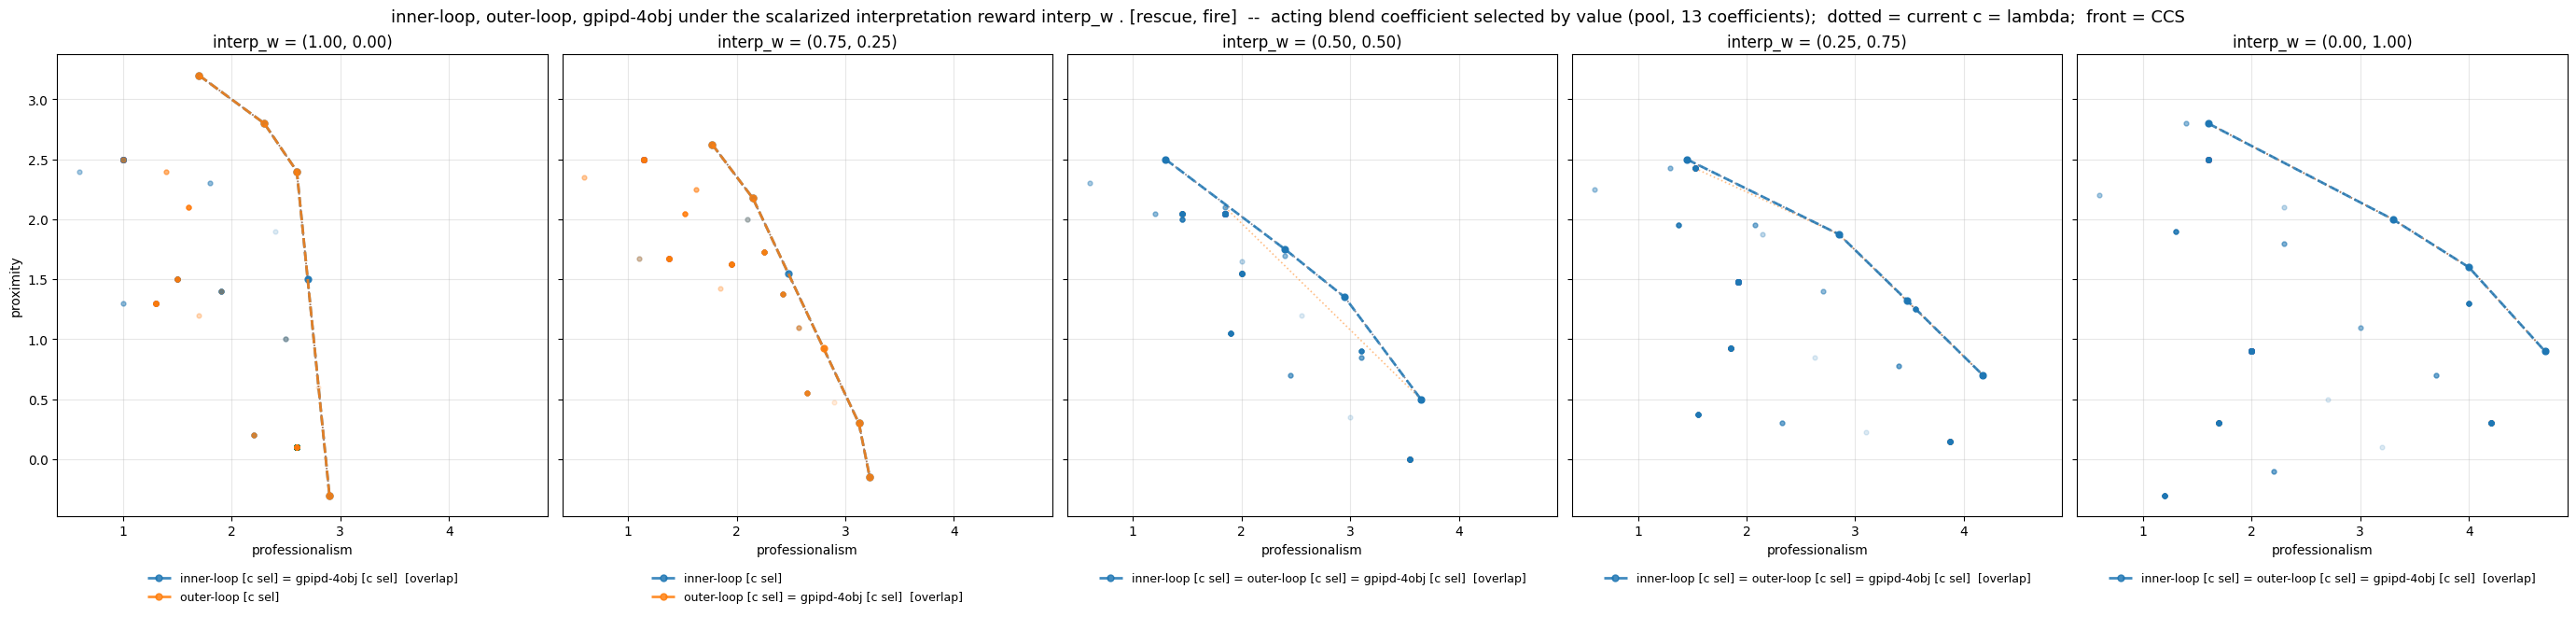

results/firefighters-mo-contested-v0\ecc_gpi_pd__30000__govvtrva: computed 0, reused 13 of 13 sweeps
results/firefighters-mo-contested-v0\ecc_envelope__40000__d0g6brv2: computed 0, reused 13 of 13 sweeps


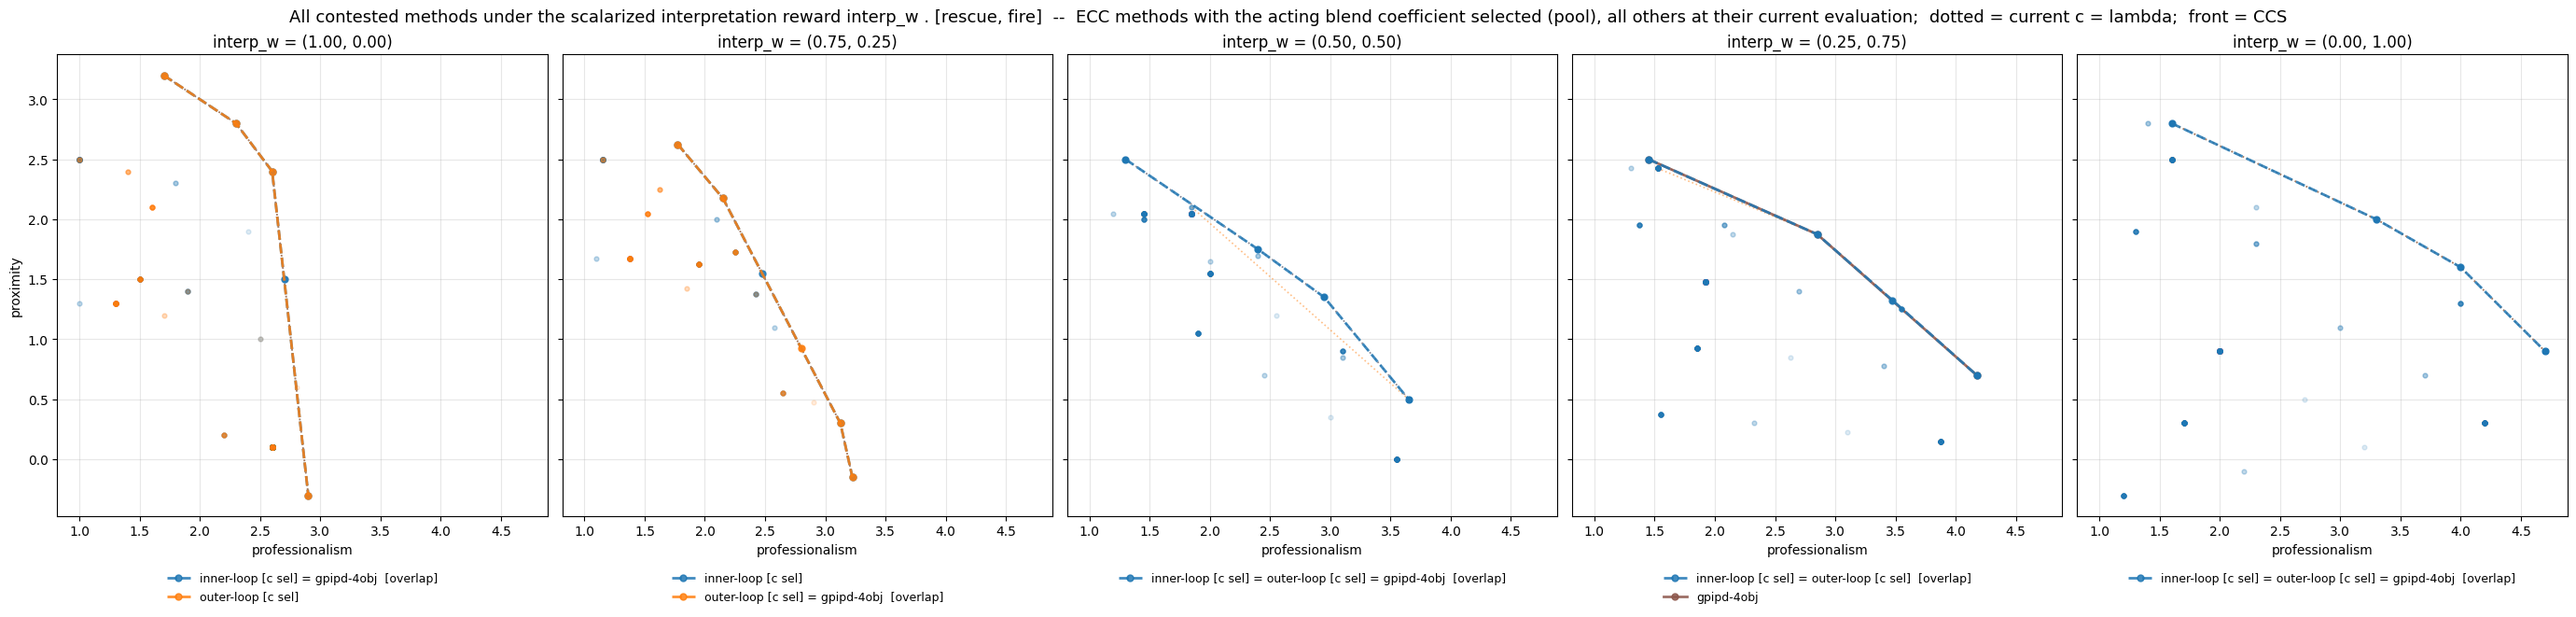

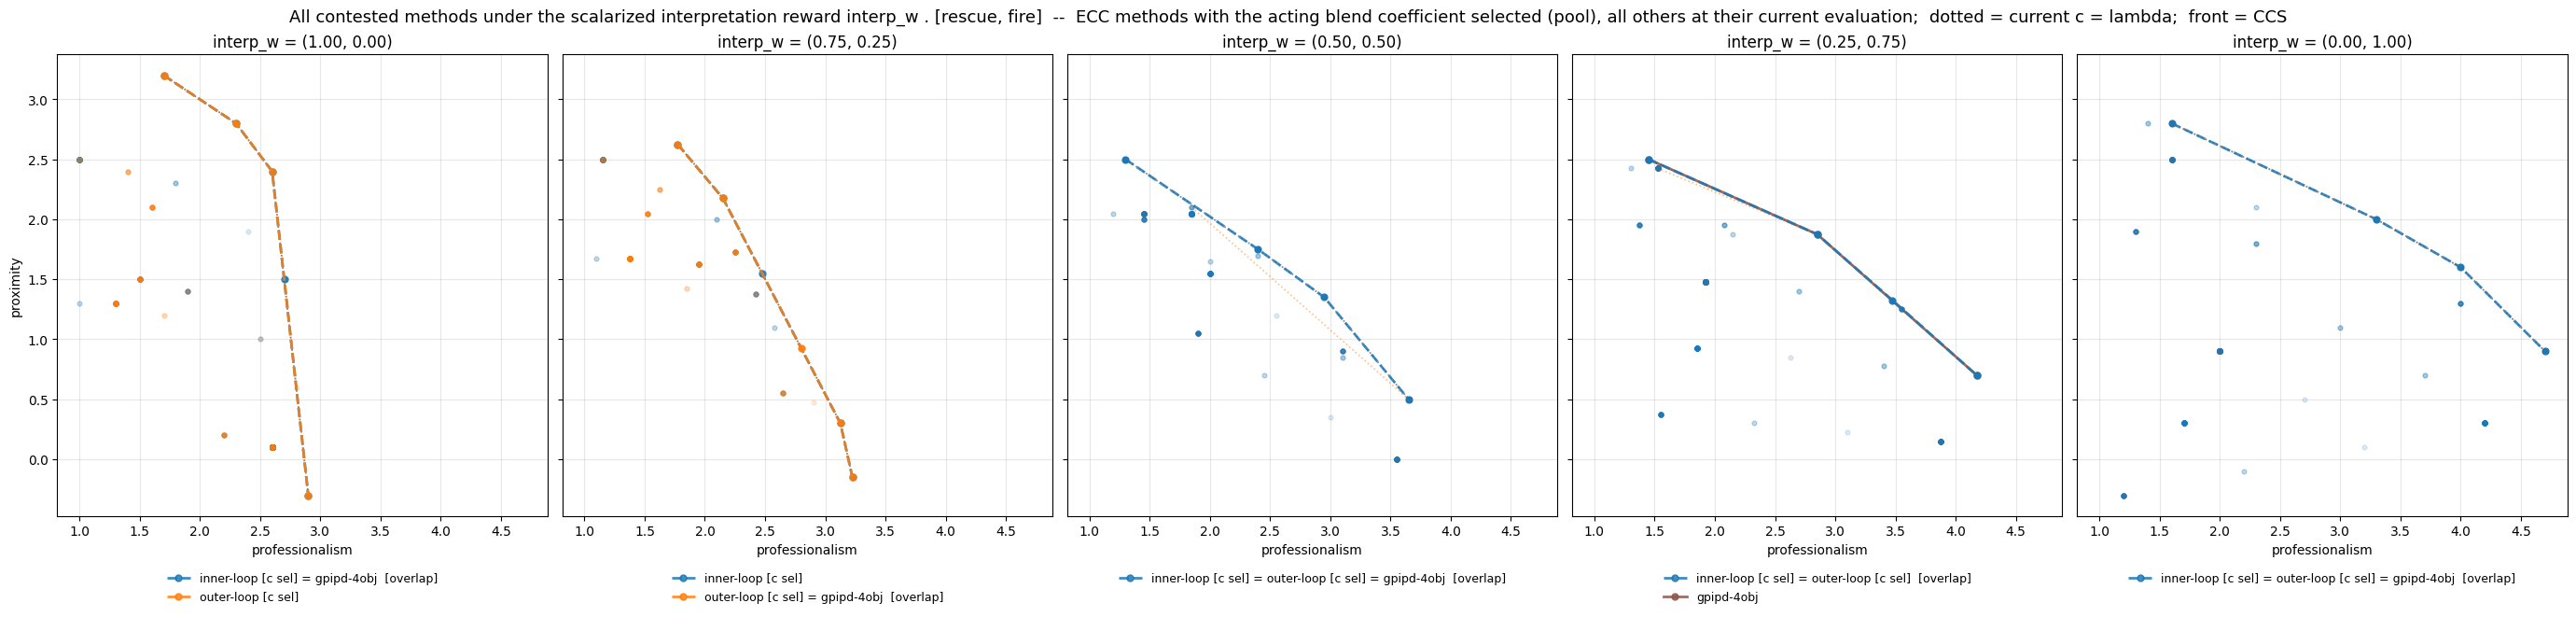

In [31]:
# Blend-coefficient SELECTION -- an EVALUATION-ONLY fix for the interior interpretation weights.
# The checkpoint is untouched: the same 2 anchor nets are rolled out, only the rule that turns an
# interpretation weight into a policy changes.
#
# The ECC-Envelope agent holds one Q-net per interpretation ANCHOR. At an anchor _anchor_coef
# resolves to a single net, so greedy selection is exact and the front is the real CCS. Off-anchor
# max_action blends the anchor nets LINEARLY (agent/ecc_envelope.py, max_action):
#
#     scalarized_q = einsum("n,nba->ba", _anchor_coef_t(interp_w), scalarized_q)
#
# but 0.5 * Q*_rescue + 0.5 * Q*_fire is the value of following BOTH anchor policies at once -- no
# single policy achieves it, and Q* is convex (not linear) in the reward, so the blend is an
# unrealizable over-estimate. Acting greedily on it carries no optimality guarantee for the blended
# reward, which is why the (0.50, 0.50) panel drops CCS points that the anchors themselves keep.
#
# Here the coefficient c handed to the agent is DECOUPLED from the interpretation weight lambda the
# return is SCORED under. _model_raw_sweep already rolls the agent out at an arbitrary c and caches
# per c, so we sweep a grid of c and keep, per objective weight, the rollouts that are best under
# lambda. Structurally this is what GPI-LS does with its weight support -- select from a policy set
# rather than average value functions -- i.e. the mechanism that lets the inner-loop agent
# (gpi_action) reach the interior CCS. Every point plotted is still ONE rollout of ONE policy.
#
# CAVEAT for the write-up: selection uses the MEASURED return, so it is an oracle over the c-grid.
# It establishes what the checkpoint can REACH; a deployable rule would select from the agent's own
# value estimate, which the per-anchor head cannot supply for a blended reward.
#
# _sel_sweeps has the same shape as _all_sweeps -- {label: {lambda: R4d [n, 4]}} -- so the plotting
# in the cell above and latex_rows_interp_sweep in the cell below both consume it unchanged:
#     latex_rows_interp_sweep(_sel_sweeps, _all_stops, labels=_ALL_LABELS)
_SEL_N_C = 10        # blend-coefficient resolution (union'd with the measurement stops)
_SEL_MODE = "pool"   # "pool" (front of the whole policy set) | "argmax" (one policy per weight)
_SEL_FIG = "ff_mimorl_interp_selected.png"

# SOLUTION CONCEPT. Under LINEAR scalarization the object of interest is the convex coverage set
# (CCS), not the full Pareto front (PF): a point that sags below the segment joining its two
# neighbours is Pareto-optimal but convex-dominated -- no weight w ever prefers it, because a
# stochastic mixture of those neighbours beats it for EVERY w. That is why a linear-support method
# (GPI-LS, i.e. the inner loop) draws a straight line there rather than a point: the segment is
# genuinely achievable by mixing, so there is nothing to plot in between.
#
# 'pool' selection returns every policy the checkpoint can reach, convex-dominated ones included,
# so those extra sagging points are exactly what shows up against the inner loop. Set _FRONT_KIND
# to "ccs" to compare like for like. It is applied to EVERY method, never to one side only.
#
# METRIC CONSEQUENCE, worth stating in the write-up: EUM is INVARIANT to this filter (it maximises
# over linear weights, so a convex-dominated point can never contribute), but HV is NOT -- those
# points do add hypervolume. Reporting HV on the raw PF therefore credits policies that linear
# scalarization can never select. Use "ccs" if the claim is about the CCS; keep "pf" only if you
# mean to claim coverage of the full Pareto front under non-linear utilities, in which case the
# inner loop's missing interior points are a genuine gap rather than an artefact.
_FRONT_KIND = "ccs"   # "ccs" (convex coverage set) | "pf" (full Pareto front)


def ccs_front(points):
    """Convex coverage set of `points` in 2-D: the concave (upper-right) hull of its Pareto front.

    Equivalent to keeping only the points that maximise w . p for some w >= 0 -- verified against
    an argmax-over-weights sweep. Note morl_baselines' filter_convex_dominated is NOT this: it
    hulls the raw cloud and then drops Pareto-dominated points, so points on the lower-right of
    the hull survive even when they are convex-dominated.
    """
    P = pareto_front(points)
    if len(P) < 3:
        return P
    out = []
    for q in P:                              # P is sorted by objective 0 ascending
        while len(out) >= 2:
            (ox, oy), (ax, ay) = out[-2], out[-1]
            if (ax - ox) * (q[1] - oy) - (ay - oy) * (q[0] - ox) >= -1e-12:
                out.pop()                    # not a strictly concave turn -> out[-1] is dominated
            else:
                break
        out.append(tuple(q))
    return np.array(out)


def _front(points):
    """The front actually plotted and scored, per _FRONT_KIND."""
    return ccs_front(points) if _FRONT_KIND == "ccs" else pareto_front(points)


def _iw_key(t):
    """Interp weight in the notebook's canonical rounded form (matches _model_raw_sweep's keys)."""
    return tuple(np.round([1 - t, t], 3))


def _blend_grid(stops, n_c=_SEL_N_C):
    """Blend coefficients to search: an n_c grid unioned with the measurement stops.

    Coefficients use the same np.round(..., 3) convention _model_raw_sweep caches under, so any c
    already rolled out is reused from disk rather than recomputed. Keeping the stops in the grid is
    what makes 'pool' monotone -- see select_blend_sweeps.
    """
    seen = {}
    for iw in [_iw_key(t) for t in np.linspace(0, 1, n_c)] + list(stops):
        seen[tuple(np.round(iw, 3))] = None      # dedupe, preserving insertion order
    return sorted(seen, key=lambda iw: iw[1])


def select_blend_sweeps(labels, stops, n_c=_SEL_N_C, mode=_SEL_MODE, num_w=_ALL_NUMW,
                        episodes=_ALL_EP, force=False):
    """(sweeps, provenance) for an acting blend coefficient decoupled from the scoring weight.

    sweeps[label][lambda] -> R4d [n, 4], same shape contract as _all_sweeps.
    provenance[label][lambda] -> the c (fire share) behind each row, or None for a baseline.

    mode 'pool'   : keep every (objective weight, c) rollout and let _front filter. Because the
                    grid contains the stops, the candidate set is a SUPERSET of the current
                    c = lambda set, so the front weakly dominates it. EUM therefore never drops.
                    Neither does HV under _FRONT_KIND == "pf" -- but under "ccs" HV CAN drop, since
                    a newly reachable policy may convex-dominate a point that had been holding up
                    the CCS staircase. EUM is the monotone (and, for a CCS claim, the correct)
                    metric; HV is a Pareto-front measure and sits awkwardly on a CCS.
                    This is the front of the agent's whole policy set at lambda.
    mode 'argmax' : conservative -- one policy per objective weight, c* = argmax_c w . scal(R_c[i],
                    lambda). Per-weight scalarized value (hence EUM) never drops, but HV CAN: a
                    point that is on the front yet is no weight's argmax gets discarded.

    Fixed-policy baselines have no blend coefficient and pass through untouched.
    """
    grid = _blend_grid(stops, n_c)
    obj_w = np.asarray(equally_spaced_weights(2, num_w), np.float32)   # as in _model_raw_sweep
    sweeps, provenance = {}, {}
    for label in labels:
        kind = _kind_for(label)
        keys = stops if kind == "baseline" else grid
        sweep = _model_raw_sweep(kind, _config_for(label), contested_run(label), keys,
                                 num_w=num_w, episodes=episodes, force=force)
        if kind == "baseline":                     # no c to choose -- one policy, already final
            sweeps[label] = sweep
            provenance[label] = {lam: None for lam in stops}
            continue
        R_c = np.stack([sweep[c] for c in grid])   # [n_c, num_w, 4]; c indexes the ACTING blend
        cs = np.asarray([c[1] for c in grid], float)
        per_lam, per_src = {}, {}
        for lam in stops:
            if mode == "pool":
                per_lam[lam] = R_c.reshape(-1, R_c.shape[-1])
                per_src[lam] = np.repeat(cs, num_w)
            else:
                V = np.stack([_scal_view(R, lam) for R in R_c])   # [n_c, num_w, 2] scored at lambda
                best = np.einsum("cwo,wo->cw", V, obj_w).argmax(axis=0)   # [num_w]
                per_lam[lam] = R_c[best, np.arange(num_w)]
                per_src[lam] = cs[best]
        sweeps[label] = per_lam
        provenance[label] = per_src
    return sweeps, provenance


_sel_grid = _blend_grid(_all_stops)
_sel_sweeps, _sel_from_c = select_blend_sweeps(_ALL_LABELS, _all_stops)

# HV / EUM, current rule vs selected. lo/hi are shared across BOTH variants at a stop, so the two
# numbers in a row are directly comparable (same convention as latex_table_rows).
# The last column names the front points the CURRENT rule cannot produce and the coefficient that
# reaches them (the c nearest lambda, when several tie) -- that is the concrete gain per panel.
#
# NORMALIZATION POOL. "shared" normalization takes lo/hi over the methods PRESENT, so uncommenting
# a label re-scales every other row and the table stops matching the one already written up. That
# is a property of the convention, not a bug -- but it makes the table non-additive. _NORM_LABELS
# freezes which methods define the axes at each stop, so a method outside the pool is scored
# against the SAME lo/hi and simply slots in as one extra row, every other number unchanged.
#
# A method that beats the frozen pool on an axis then lands above 1 in normalized space and can
# score HV > 1 / EUM > 1. That is the honest reading -- "it extends the frontier the table was
# scaled to" -- and it is the price of additivity. State the pool in the caption.
# Set _NORM_LABELS = None to go back to "whatever is currently plotted".
_NORM_LABELS = [INNER_LOOP_LABEL, OUTER_LOOP_LABEL]


def _norm_at(lam, *sweeps_dicts, labels=None):
    """(lo, span, d_ref) at interpretation weight `lam`, pooled over the frozen normalization set.

    Pools every dict passed (e.g. the c = lambda AND selected variants) over _NORM_LABELS, or over
    `labels` when _NORM_LABELS is None. d_ref is the usual lo - 0.05 * span, normalized.
    """
    pool = labels if _NORM_LABELS is None else list(_NORM_LABELS)
    pts = []
    for d in sweeps_dicts:
        missing = [l for l in pool if l not in d]
        if missing:                 # silently dropping a pool member would move the axes again
            raise KeyError(f"normalization pool member(s) {missing} were not swept -- keep them "
                           f"in _ALL_LABELS, or set _NORM_LABELS = None")
        pts += [_scal_view(d[l][lam], lam) for l in pool]
    allp = np.vstack(pts)
    lo, hi = allp.min(axis=0), allp.max(axis=0)
    span = np.where(hi > lo, hi - lo, 1.0)
    return lo, span, -0.05 * np.ones(2)


_W100 = equally_spaced_weights(2, 100)
print(f"\nmode={_SEL_MODE}   blend coefficients searched (fire share): "
      f"{[round(float(c[1]), 3) for c in _sel_grid]}\n")
print(f"{'interp_w':>14} | {'method':<14} | {'HV c=lam':>9} {'HV sel':>9} | "
      f"{'EUM c=lam':>9} {'EUM sel':>9} | new front points (c that reaches them)")
print("-" * 116)
for lam in _all_stops:
    cur = {l: _scal_view(_all_sweeps[l][lam], lam) for l in _ALL_LABELS}
    sel = {l: _scal_view(_sel_sweeps[l][lam], lam) for l in _ALL_LABELS}
    lo, span, d_ref = _norm_at(lam, _all_sweeps, _sel_sweeps, labels=_ALL_LABELS)
    tag = f"({lam[0]:.2f}, {lam[1]:.2f})"
    for l in _ALL_LABELS:
        m = []
        for pts in (cur[l], sel[l]):
            d_pf = (_front(pts) - lo) / span
            m += [hypervolume(d_ref, d_pf), expected_utility(d_pf, _W100)]
        src = _sel_from_c[l][lam]
        if src is None:
            gained = "-"                       # baseline: no coefficient to select over
        else:
            # front points the current c = lambda rollouts do not contain at all, each tagged with
            # the coefficient nearest lambda that produces it (several c often tie on one policy)
            have = {tuple(np.asarray(p, float)) for p in cur[l]}
            rows = [(tuple(np.asarray(p, float)), float(src[i])) for i, p in enumerate(sel[l])]
            new = []
            for p in _front(sel[l]):
                key = tuple(np.asarray(p, float))
                if key in have:
                    continue
                c_at = min((c for k, c in rows if k == key), key=lambda c: abs(c - lam[1]))
                new.append(f"({p[0]:.2f}, {p[1]:.2f})@c={c_at:.3f}")
            gained = f"+{len(new)}  " + ", ".join(new) if new else "none"
        print(f"{tag:>14} | {l:<14} | {m[0]:9.3f} {m[2]:9.3f} | {m[1]:9.3f} {m[3]:9.3f} | "
              f"{gained}")

# Plotting. Same layout / colors / overlap logic as the cell above, factored into a function so the
# ECC-only figure and the mixed all-methods figure below share one code path.
def plot_interp_row(sweeps, labels, stops, title, save_path=None, reference=None, selected=()):
    """One panel per interpretation weight, every method's scalarized front overlaid.

    sweeps    : {label: {lambda: R4d}} -- what gets drawn.
    reference : optional {label: {lambda: R4d}} drawn as a faint dotted line behind each method,
                i.e. what the current c = lambda rule produces, so the gain is readable per panel.
    selected  : labels whose curve came from blend selection. Tagged in the legend so a mixed
                figure cannot be misread as every method getting the same treatment.
    """
    axes = np.atleast_1d(plt.subplots(1, len(stops), figsize=(5.5 * len(stops), 6.5),
                                      sharex=True, sharey=True, layout="constrained")[1])
    fig = axes[0].figure
    for ax, lam in zip(axes, stops):
        pts_by = {l: _scal_view(sweeps[l][lam], lam) for l in labels}
        pfs = {l: _front(pts) for l, pts in pts_by.items()}
        span = np.ptp(np.vstack(list(pts_by.values())), axis=0)
        tol = _ALL_OVERLAP_TOL * np.where(span > 0, span, 1.0)

        for l in labels if reference is not None else ():
            if l not in reference:
                continue
            ref_pf = _front(_scal_view(reference[l][lam], lam))
            ax.plot(ref_pf[:, 0], ref_pf[:, 1], ls=":", lw=1.2, alpha=0.5,
                    color=METHOD_COLORS.get(l, "black"), zorder=2)

        for group in _group_fronts(pfs, tol):
            head = next((l for l in group if _is_ecc(l)), group[0])
            c, z = METHOD_COLORS.get(head, "black"), _ECC_Z if _is_ecc(head) else _BASE_Z
            for l in group:                    # dominated clouds differ even when fronts coincide
                pts = pts_by[l]
                ax.scatter(pts[:, 0], pts[:, 1], s=12, alpha=0.15, color=c, zorder=z - 1)
            names = " = ".join(f"{l} [c sel]" if l in selected else l for l in group)
            pf = pfs[head]
            ax.plot(pf[:, 0], pf[:, 1], marker="o", ms=5, color=c, lw=2, alpha=0.85,
                    ls=_LS.get(head), zorder=z,
                    label=names if len(group) == 1 else f"{names}  [overlap]")
        ax.set_title(f"interp_w = ({lam[0]:.2f}, {lam[1]:.2f})")
        ax.set_xlabel("professionalism")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9, loc="upper center", bbox_to_anchor=(0.5, -0.1), frameon=False)
    axes[0].set_ylabel("proximity")
    fig.suptitle(title, fontsize=13)
    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    return fig


plot_interp_row(_sel_sweeps, _ALL_LABELS, _all_stops,
                f"{', '.join(_ALL_LABELS)} under the scalarized interpretation reward "
                f"interp_w . [rescue, fire]  --  acting blend coefficient selected by value "
                f"({_SEL_MODE}, {len(_sel_grid)} coefficients);  dotted = current c = lambda;  "
                f"front = {_FRONT_KIND.upper()}",
                save_path=os.path.join("figures", _SEL_FIG),
                reference=_all_sweeps, selected=_ALL_LABELS)

# MIXED figure -- the selected front for the interpretation-conditioned methods, every OTHER method
# exactly as the cell above evaluates it. Labels missing from _ALL_LABELS are swept here on demand
# (same on-disk cache), so this does NOT require uncommenting them in the cell above.
_MIX_LABELS = [
    INNER_LOOP_LABEL,
    OUTER_LOOP_LABEL,
    # "ecc-envelope",
    # "gpipd-fire",
    # "gpipd-rescue",
    # "gpipd-weighted",
    "gpipd-4obj",
    # "envelope-fire",
    # "envelope-rescue",
    # "envelope-weighted",
    # "envelope-4obj",
]
_MIX_FIG = "ff_mimorl_interp_selected_vs_all.png"
# Only the interpretation-conditioned methods have a blend coefficient to select over. A fixed
# policy has none, and *-4obj is re-conditioned through its objective weight rather than through
# _anchor_coef, so neither is touched -- they stay at exactly the numbers the cell above reports.
_MIX_SELECT = [l for l in _MIX_LABELS if _is_ecc(l)]


def _current_sweeps(labels, stops):
    """{label: {lambda: R4d}} under the CURRENT c = lambda rule, reusing _all_sweeps where it has
    the label and falling back to a (disk-cached) sweep where it does not."""
    return {l: (_all_sweeps[l] if l in _all_sweeps else
                _model_raw_sweep(_kind_for(l), _config_for(l), contested_run(l), stops,
                                 num_w=_ALL_NUMW, episodes=_ALL_EP))
            for l in labels}


_mix_current = _current_sweeps(_MIX_LABELS, _all_stops)
_mix_selected, _ = select_blend_sweeps(_MIX_SELECT, _all_stops)
_mix_sweeps = {**_mix_current, **_mix_selected}        # selection wins for the ECC labels only

plot_interp_row(_mix_sweeps, _MIX_LABELS, _all_stops,
                "All contested methods under the scalarized interpretation reward "
                "interp_w . [rescue, fire]  --  ECC methods with the acting blend coefficient "
                f"selected ({_SEL_MODE}), all others at their current evaluation;  "
                f"dotted = current c = lambda;  front = {_FRONT_KIND.upper()}",
                save_path=os.path.join("figures", _MIX_FIG),
                reference=_mix_current, selected=_MIX_SELECT)

method & (1.00, 0.00) & (0.75, 0.25) & (0.50, 0.50) & (0.25, 0.75) & (0.00, 1.00) & worst-case & mean \\
\midrule
inner-loop & 0.90/0.861 & 0.70/0.802 & 0.62/0.784 & 0.59/0.791 & 0.78/0.825 & 0.59/0.784 & 0.72/0.813 \\
outer-loop & 0.87/0.861 & 0.63/0.802 & 0.47/0.747 & 0.60/0.784 & 0.78/0.825 & 0.47/0.747 & 0.67/0.804 \\
gpipd-fire & 0.28/0.561 & 0.45/0.668 & 0.58/0.736 & 0.66/0.784 & 0.78/0.825 & 0.28/0.561 & 0.55/0.715 \\
gpipd-rescue & 0.91/0.861 & 0.69/0.799 & 0.41/0.698 & 0.19/0.570 & 0.27/0.548 & 0.19/0.548 & 0.50/0.695 \\
gpipd-weighted & 0.36/0.636 & 0.52/0.743 & 0.62/0.784 & 0.65/0.791 & 0.74/0.798 & 0.36/0.636 & 0.58/0.751 \\
gpipd-4obj & 0.90/0.861 & 0.70/0.802 & 0.62/0.784 & 0.59/0.791 & 0.78/0.825 & 0.59/0.784 & 0.72/0.813 \\


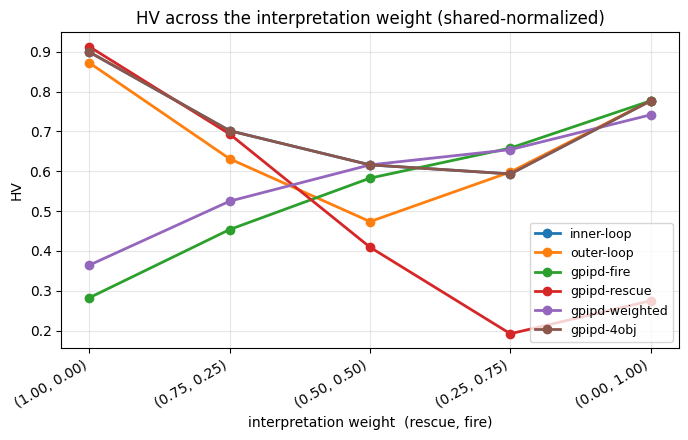

In [21]:
# LaTeX rows for the BETWEEN-INTERPRETATION sweep: the same HV/EUM pair as latex_table_rows, but
# one column per interpretation-weight STOP instead of one per interpretation -- plus worst-case
# (min over stops) and mean columns. The corner-only table cannot show the interior, which is
# exactly where a blended/anchored ECC policy differs from its baselines.
#
# Reuses _all_sweeps / _all_stops / _scal_view from the cell above, so it costs NO extra rollouts:
# run that cell first, then this one. Normalization mirrors latex_table_rows -- at each stop lo/hi
# are taken over ALL methods AT THAT STOP ("shared"), so a column is comparable across methods but
# not across columns; EUM is always shared-normalized, as in latex_table_rows.

def latex_rows_interp_sweep(sweeps, stops, labels=None, normalize="shared", weights_set=None,
                            plot=True, metric="hv", header=True, save_path=None, dpi=150,
                            norm_labels="frozen"):
    """HV/EUM per interpretation-weight stop, printed as LaTeX rows.

    sweeps      : {label: {iw: R4d [num_w, 4]}} -- e.g. _all_sweeps
    stops       : ordered interp weights        -- e.g. _all_stops
    norm_labels : which methods define the shared lo/hi. "frozen" uses _NORM_LABELS from the cell
                  above, so ADDING a method to `labels` leaves every other row's numbers untouched
                  (a method outside the pool may then exceed 1 and score HV > 1). None reverts to
                  the old behaviour -- lo/hi over exactly the rows being printed.
    Returns metrics[label][iw] = (hv, eum).
    """
    assert normalize in ("none", "shared", "own"), normalize
    assert metric in ("hv", "eum"), metric
    if weights_set is None:
        weights_set = equally_spaced_weights(2, 100)
    labels = list(sweeps) if labels is None else list(labels)
    if norm_labels == "frozen":
        norm_labels = globals().get("_NORM_LABELS")
    pool = labels if norm_labels is None else list(norm_labels)
    # A pool member need not be a PRINTED row -- it only has to define the axes. Fall back to
    # _all_sweeps for members `sweeps` does not carry (e.g. scoring _mix_sweeps, whose label list
    # is a different subset), so the scale stays the one the frozen table was built on.
    norm_src = {l: (sweeps[l] if l in sweeps else globals().get("_all_sweeps", {}).get(l))
                for l in pool}
    missing = [l for l, s in norm_src.items() if s is None]
    if missing:
        raise KeyError(f"normalization pool member(s) {missing} are in neither `sweeps` nor "
                       f"_all_sweeps -- sweep them, or pass norm_labels=None")

    metrics = {label: {} for label in labels}
    for iw in stops:
        pts_by = {label: _scal_view(sweeps[label][iw], iw) for label in labels}
        all_pts = np.vstack([_scal_view(norm_src[l][iw], iw) for l in pool])
        lo, hi = all_pts.min(axis=0), all_pts.max(axis=0)
        span = np.where(hi > lo, hi - lo, 1.0)
        ref_point = lo - 0.05 * span
        for label, pts in pts_by.items():
            pf = pareto_front(pts)
            eum = expected_utility((pf - lo) / span, weights_set)  # shared-normalized
            if normalize == "shared":
                d_pf, d_ref = (pf - lo) / span, (ref_point - lo) / span
            elif normalize == "own":
                mlo, mhi = pts.min(axis=0), pts.max(axis=0)
                mspan = np.where(mhi > mlo, mhi - mlo, 1.0)
                d_pf, d_ref = (pf - mlo) / mspan, -0.05 * np.ones(2)
            else:  # 'none'
                d_pf, d_ref = pf, ref_point
            metrics[label][iw] = (hypervolume(d_ref, d_pf), eum)

    if header:
        cols = " & ".join(f"({iw[0]:.2f}, {iw[1]:.2f})" for iw in stops)
        print(f"method & {cols} & worst-case & mean" + r" \\")
        print(r"\midrule")
    for label in labels:
        hvs = [metrics[label][iw][0] for iw in stops]
        eums = [metrics[label][iw][1] for iw in stops]
        cells = " & ".join(f"{h:.2f}/{e:.3f}" for h, e in zip(hvs, eums))
        print(f"{label} & {cells}"
              f" & {min(hvs):.2f}/{min(eums):.3f}"
              f" & {np.mean(hvs):.2f}/{np.mean(eums):.3f}" + r" \\")

    if plot:
        idx = 0 if metric == "hv" else 1
        xs = [iw[1] for iw in stops]                      # fire share: 0 = pure rescue, 1 = pure fire
        fig, ax = plt.subplots(figsize=(max(7, 1.4 * len(stops)), 4.5))
        for label in labels:
            ax.plot(xs, [metrics[label][iw][idx] for iw in stops], marker="o", lw=2,
                    color=METHOD_COLORS.get(label, None), label=label)
        ax.set_xticks(xs)
        ax.set_xticklabels([f"({iw[0]:.2f}, {iw[1]:.2f})" for iw in stops], rotation=30, ha="right")
        ax.set_xlabel("interpretation weight  (rescue, fire)")
        scale = "" if normalize == "none" else f" ({normalize}-normalized)"
        ax.set_ylabel(metric.upper())
        ax.set_title(f"{metric.upper()} across the interpretation weight{scale}")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)
        plt.tight_layout()
        if save_path is not None:
            fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
            print(f"saved {save_path}")
        plt.show()

    return metrics


_sweep_metrics = latex_rows_interp_sweep(_all_sweeps, _all_stops, labels=_ALL_LABELS)
